In [4]:
# Cell 1 — Dependencies
import sys

!"{sys.executable}" -m pip install pandas openpyxl requests numpy \
             pyEDM hmmlearn scikit-learn \
             statsmodels networkx \
             ripser persim \
             yfinance matplotlib mplfinance seaborn \
             websocket-client

  Using cached pandas-3.0.1-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached pyedm-2.3.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached hmmlearn-0.3.3-cp314-cp314-win_amd64.whl
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached ripser-0.6.14-cp314-cp314-win_amd64.whl.metadata (9.2 kB)
  Using cached persim-0.3.8-py3-none-any.whl.metadata (3.8 kB)
  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached mplfinance-0.12.10b0-py3-none-any.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached websocket_client-1.9.0-py


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Projects\crypto-sentiment-trader\btc-whale\Scripts\python.exe -m pip install --upgrade pip


In [12]:
# Cell 2 — Configuration
# Source of truth for all downstream cells.
# Change the Excel file or SHEET_META here — everything downstream updates automatically.

import pandas as pd
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("C:\Projects\crypto-sentiment-trader\data")
CACHE_DIR  = Path("C:\Projects\crypto-sentiment-trader\cache")
OUTPUT_DIR = Path("C:\Projects\crypto-sentiment-trader\outputs")

for d in [DATA_DIR, CACHE_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True)

# ── Excel source ──────────────────────────────────────────────────────────────
EXCEL_FILE = DATA_DIR / "whale_transactions_normalised.xlsx"

# Sheet name → entity class label
# entityClass is already embedded in the normalised dataset, but SHEET_META
# is kept as the canonical reference for entity class lookups elsewhere in the pipeline.
SHEET_META = {
    "winklevoss-capital":           "Corporate",
    "microstrategy":                "Corporate",
    "twenty-one-capital":           "Corporate",
    "tesla":                        "Corporate",
    "mara-pool":                    "Corporate",
    "cleanspark":                   "Corporate",
    "metaplanet-2":                 "Corporate",
    "blackrock":                    "ETF_Fund",
    "bitwise":                      "ETF_Fund",
    "vaneck":                       "ETF_Fund",
    "purpose-investments":          "ETF_Fund",
    "ci-global-asset-management":   "ETF_Fund",
    "coinshares":                   "ETF_Fund",
    "gemini":                       "ETF_Fund",
    "fidelity":                     "ETF_Fund",
    "grayscale":                    "ETF_Fund",
    "wisdomtree":                   "ETF_Fund",
    "invesco":                      "ETF_Fund",
    "usg":                          "Government",
    "uk":                           "Government",
    "germany":                      "Government",
    "druk-holding-investments":     "Government",
    "el-salvador":                  "Government",
}

# Columns we care about (subset of the full schema)
TX_COLUMNS = [
    "transactionHash",
    "fromAddress",
    "fromLabel",
    "toAddress",
    "toLabel",
    "type",             # inflow / outflow
    "blockTimestamp",
    "blockNumber",
    "unitValue",        # BTC amount
    "historicalUSD",
    "chain",
    "entityClass",      # pre-populated in the normalised dataset
]

# ── Load transactions + extract whale addresses ───────────────────────────────
all_transactions = []
WHALE_ADDRESSES  = set()

for sheet in SHEET_META.keys():
    df = pd.read_excel(EXCEL_FILE, sheet_name=sheet, usecols=TX_COLUMNS)
    df["blockTimestamp"] = pd.to_datetime(df["blockTimestamp"], utc=True)

    # Filter out any ambiguous rows produced by the normaliser
    df = df[df["type"].isin(["inflow", "outflow"])].copy()

    all_transactions.append(df)

    # Whale addresses: toAddress for inflows, fromAddress for outflows
    inflow_addrs  = df[df["type"] == "inflow" ]["toAddress"].dropna().str.strip().unique()
    outflow_addrs = df[df["type"] == "outflow"]["fromAddress"].dropna().str.strip().unique()
    WHALE_ADDRESSES.update(inflow_addrs)
    WHALE_ADDRESSES.update(outflow_addrs)

df_transactions = pd.concat(all_transactions, ignore_index=True)
WHALE_ADDRESSES = sorted(WHALE_ADDRESSES)

print(f"Sheets loaded:      {list(SHEET_META.keys())}")
print(f"Total transactions: {len(df_transactions)}")
print(f"Whale addresses:    {len(WHALE_ADDRESSES)}")
print(f"Date range:         {df_transactions['blockTimestamp'].min()} → {df_transactions['blockTimestamp'].max()}")

# ── HMM ───────────────────────────────────────────────────────────────────────
HMM_STATES    = 4
REGIME_NAMES  = ["Bull", "Neutral", "High-Vol", "Bear-Trend"]

# ── CCM ───────────────────────────────────────────────────────────────────────
CCM_EMBED_DIM  = 5
CCM_LIB_SIZES  = [10, 50, 100, 200]

# ── Signal ────────────────────────────────────────────────────────────────────
SIGNAL_DECAY_DAYS   = 5
WHALE_BTC_THRESHOLD = 10     # minimum BTC to qualify as whale tx
FEE_URGENCY_CAP     = 3.0    # cap fee_urgency multiplier at 3x
USE_API_DORMANCY    = False   # Toggle: set False when full 2020-2025 transaction history is available

# ── Date range ────────────────────────────────────────────────────────────────
DATE_START     = "2020-01-01"
DATE_END       = "2025-12-31"
TRAIN_END      = "2023-12-31"   # HMM + factor betas trained up to here
VALIDATE_START = "2024-01-01"   # out-of-sample window

# ── Entity classes ────────────────────────────────────────────────────────────
ENTITY_CLASSES = list(dict.fromkeys(SHEET_META.values()))  # unique, order-preserved
print(f"Entity classes: {ENTITY_CLASSES}")

print("\nConfiguration loaded ✓")

Sheets loaded:      ['winklevoss-capital', 'microstrategy', 'twenty-one-capital', 'tesla', 'mara-pool', 'cleanspark', 'metaplanet-2', 'blackrock', 'bitwise', 'vaneck', 'purpose-investments', 'ci-global-asset-management', 'coinshares', 'gemini', 'fidelity', 'grayscale', 'wisdomtree', 'invesco', 'usg', 'uk', 'germany', 'druk-holding-investments', 'el-salvador']
Total transactions: 71648
Whale addresses:    13087
Date range:         2020-01-02 10:07:14+00:00 → 2025-12-31 23:59:58+00:00
Entity classes: ['Corporate', 'ETF_Fund', 'Government']

Configuration loaded ✓


In [5]:
# CELL 2.5 — CONSOLIDATED FILE PATHS
# All file paths in one place — run once, all cells can use
# ============================================================

from pathlib import Path

# ── Base directories (from Cell 2) ──────────────────────────
DATA_DIR   = Path("C:\Projects\crypto-sentiment-trader\data")
CACHE_DIR  = Path("C:\Projects\crypto-sentiment-trader\cache")
OUTPUT_DIR = Path("C:\Projects\crypto-sentiment-trader\outputs")

# Ensure directories exist
for d in [DATA_DIR, CACHE_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True)

# ── Input data files ────────────────────────────────────────
EXCEL_FILE = DATA_DIR / "whale_transactions_normalised.xlsx"

# ── HMM ───────────────────────────────────────────────────────────────────────
HMM_STATES    = 4
REGIME_NAMES  = ["Bull", "Neutral", "High-Vol", "Bear-Trend"]

# ── CCM ───────────────────────────────────────────────────────────────────────
CCM_EMBED_DIM  = 5
CCM_LIB_SIZES  = [10, 50, 100, 200]

# ── Signal ────────────────────────────────────────────────────────────────────
SIGNAL_DECAY_DAYS   = 5
WHALE_BTC_THRESHOLD = 10     # minimum BTC to qualify as whale tx
FEE_URGENCY_CAP     = 3.0    # cap fee_urgency multiplier at 3x
USE_API_DORMANCY    = False   # Toggle: set False when full 2020-2025 transaction history is available

# ── Date range ────────────────────────────────────────────────────────────────
DATE_START     = "2020-01-01"
DATE_END       = "2025-12-31"
TRAIN_END      = "2023-12-31"   # HMM + factor betas trained up to here
VALIDATE_START = "2024-01-01"   # out-of-sample window

# — Warm-up periods
HMM_COLD_START = 90       # Days to exclude from HMM training (TDA zeros)
PRICE_WARMUP = 200        # Days for price_ma200_zscore (structural, not for HMM)

# ── Intermediate data files (generated by pipeline) ─────────
# Cell 3
HASHRATE_FILE = DATA_DIR / "hashrate.csv"

# Cell 5
OHLCV_FILE = DATA_DIR / "ohlcv.csv"

# Cell 6
MACRO_FILE = DATA_DIR / "macro.csv"

# Cell 7
ENRICHED_FILE = DATA_DIR / "whale_enriched.csv"

# Cell 8
FLOWS_FILE = DATA_DIR / "whale_flows.csv"

# Cell 9
HASHRIBBONS_FILE = DATA_DIR / "hashribbons.csv"

# Cell 10
CCM_RESULTS_FILE = DATA_DIR / "ccm_results.csv"

# Cell 11
GRAPH_FEATURES_FILE = DATA_DIR / "graph_features.csv"

# Cell 12
TDA_FEATURES_FILE = DATA_DIR / "tda_features.csv"

# Cell 13
HMM_FEATURES_FILE = DATA_DIR / "hmm_features.csv"
SCALER_FILE = CACHE_DIR / "hmm_scaler.pkl"

# Cell 14 (HMM)
HMM_REGIMES_FILE = DATA_DIR / "hmm_regimes.csv"
HMM_MODEL_FILE = CACHE_DIR / "hmm_model.pkl"

# Cell 15
FACTOR_BETAS_FILE = DATA_DIR / "factor_betas.csv"

# Cell 16
MASTER_FILE = DATA_DIR / "master_dataset.csv"

# Cell 18
BACKTEST_FILE = DATA_DIR / "backtest_results.csv"

# Cell 19 outputs
PERF_SUMMARY_FILE = OUTPUT_DIR / "cell18_performance_summary.csv"
REGIME_BREAKDOWN_FILE = OUTPUT_DIR / "cell18_regime_breakdown.csv"

# Cell 20 sweep outputs
SWEEP_WEIGHTS_FILE = OUTPUT_DIR / "cell20_sweep_weights.csv"
SWEEP_BULL_DAMP_FILE = OUTPUT_DIR / "cell20_sweep_bull_damp.csv"
SWEEP_REBAL_FREQ_FILE = OUTPUT_DIR / "cell20_sweep_rebal_freq.csv"
SWEEP_RIBBON_MULT_FILE = OUTPUT_DIR / "cell20_sweep_ribbon_mult.csv"
SWEEP_RIBBON_THRESH_FILE = OUTPUT_DIR / "cell20_sweep_ribbon_thresh.csv"
SWEEP_WINSOR_FILE = OUTPUT_DIR / "cell20_sweep_winsor.csv"
SWEEP_SIGNAL_THRESH_FILE = OUTPUT_DIR / "cell20_sweep_signal_threshold.csv"
SWEEP_JOINT_FILE = OUTPUT_DIR / "cell20_joint_candidates.csv"

# Cell 21 outputs
LIVE_MONITOR_FILE = Path("live_monitor.py")
ENV_EXAMPLE_FILE = Path(".env.example")
LIVE_SIGNAL_LOG = OUTPUT_DIR / "live_signal_log.csv"
LIVE_STATE_FILE = CACHE_DIR / "live_monitor_state.json"
LIVE_RUN_LOG = OUTPUT_DIR / "live_monitor_run.log"

# ── Cell 17 visualization outputs ───────────────────────────
QA_CHART_FILE = OUTPUT_DIR / "cell17_visual_qa.png"
QA_CHART_HIRES_FILE = OUTPUT_DIR / "cell17_visual_qa_hires.png"

PANEL1_FILE = OUTPUT_DIR / "cell17_panel1_price_regimes.csv"
PANEL2_FILE = OUTPUT_DIR / "cell17_panel2_whale_flows.csv"
PANEL3_FILE = OUTPUT_DIR / "cell17_panel3_hash_ribbons.csv"
PANEL3_EVENTS_FILE = OUTPUT_DIR / "cell17_panel3_crossover_events.csv"
PANEL4_FILE = OUTPUT_DIR / "cell17_panel4_regime_probs.csv"
PANEL5_FILE = OUTPUT_DIR / "cell17_panel5_volatility.csv"

# ── Print confirmation ──────────────────────────────────────
print("=" * 60)
print("CONSOLIDATED FILE PATHS LOADED")
print("=" * 60)
print(f"DATA_DIR    : {DATA_DIR.resolve()}")
print(f"CACHE_DIR   : {CACHE_DIR.resolve()}")
print(f"OUTPUT_DIR  : {OUTPUT_DIR.resolve()}")
print(f"\nTotal file paths defined: {len([k for k in dir() if k.endswith('_FILE') or k.endswith('_DIR')])}")
print("\nReady to run downstream cells ✓")

CONSOLIDATED FILE PATHS LOADED
DATA_DIR    : C:\Projects\crypto-sentiment-trader\data
CACHE_DIR   : C:\Projects\crypto-sentiment-trader\cache
OUTPUT_DIR  : C:\Projects\crypto-sentiment-trader\outputs

Total file paths defined: 41

Ready to run downstream cells ✓


In [13]:
# Cell 3 — Hash Rate
# Fetches daily BTC hash rate 2020-2025.
# CoinMetrics for 2020-2021 (higher quality around China mining ban).
# Blockchain.com for 2022-2025 (sufficient quality, no API key needed).
# Stitched at 2022-01-01 and cached to hashrate.csv.

import requests
import pandas as pd
import time
from pathlib import Path

HASHRATE_FILE = DATA_DIR / "hashrate.csv"
STITCH_DATE   = "2022-01-01"
STITCH_TS     = pd.Timestamp(STITCH_DATE, tz="UTC")

# ── Blockchain.com fetch (2022-2025) ──────────────────────────────────────────

def fetch_blockchain_hashrate(start: str, end: str) -> pd.DataFrame:
    """Fetch daily hash rate from Blockchain.com charts API."""
    url = "https://api.blockchain.info/charts/hash-rate"
    params = {
        "start":          start,
        "end":            end,
        "format":         "json",
        "sampled":        "true",
        "timespan":       "all",
        "rollingAverage": "24hours",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()

    values = r.json().get("values", [])
    df = pd.DataFrame(values)            # columns will be 'x' and 'y'
    df = df.rename(columns={"x": "timestamp", "y": "hash_rate"})
    df["date"]      = pd.to_datetime(df["timestamp"], unit="s", utc=True).dt.normalize()
    df["hash_rate"] = df["hash_rate"].astype(float)
    df["source"]    = "blockchain.com"
    return df[["date", "hash_rate", "source"]]
    
# ── CoinMetrics fetch (2020-2021) ─────────────────────────────────────────────

def fetch_coinmetrics_hashrate(start: str, end: str) -> pd.DataFrame:
    """
    Fetch daily hash rate from CoinMetrics community API.
    Uses HashRate metric (mean hash rate in TH/s).
    No API key required for community tier.
    """
    url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
    params = {
        "assets":     "btc",
        "metrics":    "HashRate",
        "start_time": start,
        "end_time":   end,
        "frequency":  "1d",
        "page_size":  1000,
    }
    rows = []
    retries = 3
    while True:
        for attempt in range(retries):
            try:
                r = requests.get(url, params=params, timeout=60)  # increased to 60s
                r.raise_for_status()
                break
            except requests.exceptions.Timeout:
                print(f"  Timeout (attempt {attempt+1}/{retries}) — retrying...")
                time.sleep(10)
        else:
            raise RuntimeError("CoinMetrics API failed after 3 retries — see fallback below")

        data = r.json()
        rows.extend(data.get("data", []))
        next_page = data.get("next_page_url")
        if not next_page:
            break
        params = {}
        url = next_page

    df = pd.DataFrame(rows)
    df["date"]      = pd.to_datetime(df["time"], utc=True).dt.normalize()
    df["hash_rate"] = pd.to_numeric(df["HashRate"], errors="coerce")
    df["source"]    = "coinmetrics"
    return df[["date", "hash_rate", "source"]]

# ── Fetch & stitch ────────────────────────────────────────────────────────────

print("Fetching CoinMetrics hash rate (2020-2021)...")
df_cm = fetch_coinmetrics_hashrate(DATE_START, STITCH_DATE)
print(f"  CoinMetrics: {len(df_cm)} rows ({df_cm['date'].min().date()} → {df_cm['date'].max().date()})")

print("Fetching Blockchain.com hash rate (2022-2025)...")
df_bc = fetch_blockchain_hashrate(STITCH_DATE, DATE_END)
print(f"  Blockchain.com: {len(df_bc)} rows ({df_bc['date'].min().date()} → {df_bc['date'].max().date()})")

# Stitch — CoinMetrics owns everything before STITCH_TS
df_cm_trim  = df_cm[df_cm["date"] <  STITCH_TS]
df_bc_trim  = df_bc[df_bc["date"] >= STITCH_TS]
df_hashrate = pd.concat([df_cm_trim, df_bc_trim], ignore_index=True).sort_values("date")

# ── Stitch point divergence check ─────────────────────────────────────────────
stitch_cm = df_cm[df_cm["date"] == STITCH_TS]["hash_rate"].values
stitch_bc = df_bc[df_bc["date"] == STITCH_TS]["hash_rate"].values

if len(stitch_cm) and len(stitch_bc):
    divergence = abs(stitch_cm[0] - stitch_bc[0]) / stitch_cm[0]
    if divergence > 0.10:
        print(f"⚠️  Stitch point divergence: {divergence:.1%} — check units between sources")
    else:
        print(f"✓  Stitch point divergence: {divergence:.1%} — acceptable")
else:
    print("⚠️  Could not compare stitch point — one or both sources missing 2022-01-01")

# ── Validate & gap-fill ───────────────────────────────────────────────────────
df_hashrate = df_hashrate.drop_duplicates("date").reset_index(drop=True)

date_range = pd.date_range(DATE_START, DATE_END, freq="D", tz="UTC")
missing    = date_range.difference(df_hashrate["date"])

if len(missing):
    print(f"⚠️  {len(missing)} missing dates — forward-filling")
    df_hashrate = (df_hashrate
                   .set_index("date")
                   .reindex(date_range)
                   .ffill()
                   .reset_index()
                   .rename(columns={"index": "date"}))

# ── Save ──────────────────────────────────────────────────────────────────────
df_hashrate.to_csv(HASHRATE_FILE, index=False)
print(f"\nHash rate saved → {HASHRATE_FILE}")
print(f"Rows: {len(df_hashrate)} | Date range: {df_hashrate['date'].min().date()} → {df_hashrate['date'].max().date()}")
print(df_hashrate.head())

Fetching CoinMetrics hash rate (2020-2021)...
  CoinMetrics: 732 rows (2020-01-01 → 2022-01-01)
Fetching Blockchain.com hash rate (2022-2025)...
  Blockchain.com: 1548 rows (2022-01-02 → 2026-04-01)
⚠️  Could not compare stitch point — one or both sources missing 2022-01-01
⚠️  4 missing dates — forward-filling

Hash rate saved → C:\Projects\crypto-sentiment-trader\data\hashrate.csv
Rows: 2192 | Date range: 2020-01-01 → 2025-12-31
                       date     hash_rate       source
0 2020-01-01 00:00:00+00:00  1.129298e+08  coinmetrics
1 2020-01-02 00:00:00+00:00  9.671772e+07  coinmetrics
2 2020-01-03 00:00:00+00:00  1.159241e+08  coinmetrics
3 2020-01-04 00:00:00+00:00  1.152381e+08  coinmetrics
4 2020-01-05 00:00:00+00:00  1.118084e+08  coinmetrics


In [14]:
# Cell 5 — BTC OHLCV
# Fetches daily BTC-USD price data 2020-2025 via yfinance.
# Adds log_return and rolling_vol_30d columns — used repeatedly downstream.
# Saved to ohlcv.csv.

import yfinance as yf
import numpy as np
import pandas as pd

OHLCV_FILE = DATA_DIR / "ohlcv.csv"

# ── Fetch ─────────────────────────────────────────────────────────────────────
print("Fetching BTC-USD OHLCV from Yahoo Finance...")
df_ohlcv = yf.download("BTC-USD", start=DATE_START, end=DATE_END, progress=False)

if df_ohlcv.empty:
    raise ValueError("yfinance returned empty dataframe — check DATE_START/DATE_END and internet connection")

# ── Flatten multi-index columns if present ────────────────────────────────────
if isinstance(df_ohlcv.columns, pd.MultiIndex):
    df_ohlcv.columns = df_ohlcv.columns.get_level_values(0)

# ── Normalise index ───────────────────────────────────────────────────────────
df_ohlcv.index = pd.to_datetime(df_ohlcv.index, utc=True).normalize()
df_ohlcv.index.name = "date"
df_ohlcv = df_ohlcv.reset_index()

# ── Rename columns to lowercase ───────────────────────────────────────────────
df_ohlcv.columns = [c.lower() for c in df_ohlcv.columns]

# ── Derived columns ───────────────────────────────────────────────────────────
df_ohlcv["log_return"]      = np.log(df_ohlcv["close"] / df_ohlcv["close"].shift(1))
df_ohlcv["rolling_vol_30d"] = df_ohlcv["log_return"].rolling(30).std()

# ── 5-day forward return (target variable for CCM and factor decomposition) ───
df_ohlcv["fwd_return_5d"]   = df_ohlcv["close"].shift(-5) / df_ohlcv["close"] - 1

# ── Validate ──────────────────────────────────────────────────────────────────
missing = df_ohlcv[df_ohlcv[["open", "high", "low", "close", "volume"]].isnull().any(axis=1)]
if len(missing):
    print(f"⚠️  {len(missing)} rows with missing OHLCV — forward-filling")
    df_ohlcv[["open", "high", "low", "close", "volume"]] = (
        df_ohlcv[["open", "high", "low", "close", "volume"]].ffill()
    )

# ── Save ──────────────────────────────────────────────────────────────────────
df_ohlcv.to_csv(OHLCV_FILE, index=False)
print(f"OHLCV saved → {OHLCV_FILE}")
print(f"Rows: {len(df_ohlcv)} | Date range: {df_ohlcv['date'].min().date()} → {df_ohlcv['date'].max().date()}")
print(df_ohlcv[["date", "close", "log_return", "rolling_vol_30d", "fwd_return_5d"]].tail())

Fetching BTC-USD OHLCV from Yahoo Finance...
OHLCV saved → C:\Projects\crypto-sentiment-trader\data\ohlcv.csv
Rows: 2191 | Date range: 2020-01-01 → 2025-12-30
                          date         close  log_return  rolling_vol_30d  \
2186 2025-12-26 00:00:00+00:00  87301.429688    0.000764         0.019699   
2187 2025-12-27 00:00:00+00:00  87802.156250    0.005719         0.019659   
2188 2025-12-28 00:00:00+00:00  87835.835938    0.000384         0.019654   
2189 2025-12-29 00:00:00+00:00  87138.140625   -0.007975         0.019694   
2190 2025-12-30 00:00:00+00:00  88430.132812    0.014718         0.019897   

      fwd_return_5d  
2186            NaN  
2187            NaN  
2188            NaN  
2189            NaN  
2190            NaN  


In [15]:
# Cell 6 — Macro Covariates
# Fetches daily DXY, SPX, VIX from Yahoo Finance 2020-2025.
# Computes DXY_return and SPX_return. VIX used as level, not return.
# Forward-fills weekends and holidays.
# Saved to macro.csv.

import yfinance as yf
import numpy as np
import pandas as pd

MACRO_FILE = DATA_DIR / "macro.csv"

TICKERS = {
    "DX-Y.NYB": "dxy",    # US Dollar Index
    "^GSPC":    "spx",    # S&P 500
    "^VIX":     "vix",    # CBOE Volatility Index
}

# ── Fetch ─────────────────────────────────────────────────────────────────────
print("Fetching macro covariates from Yahoo Finance...")
dfs = []

for ticker, name in TICKERS.items():
    df = yf.download(ticker, start=DATE_START, end=DATE_END, progress=False)

    if df.empty:
        raise ValueError(f"yfinance returned empty dataframe for {ticker}")

    # Flatten multi-index if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.index = pd.to_datetime(df.index, utc=True).normalize()
    df.index.name = "date"
    df = df.reset_index()[["date", "Close"]].rename(columns={"Close": name})
    dfs.append(df)
    print(f"  {ticker}: {len(df)} rows")

# ── Merge on date spine ───────────────────────────────────────────────────────
df_macro = dfs[0]
for df in dfs[1:]:
    df_macro = df_macro.merge(df, on="date", how="outer")

df_macro = df_macro.sort_values("date").reset_index(drop=True)

# ── Reindex to full calendar and forward-fill weekends/holidays ───────────────
date_range = pd.date_range(DATE_START, DATE_END, freq="D", tz="UTC")
df_macro   = (df_macro
              .set_index("date")
              .reindex(date_range)
              .ffill()
              .reset_index()
              .rename(columns={"index": "date"}))

# ── Derived columns ───────────────────────────────────────────────────────────
df_macro["dxy_return"] = np.log(df_macro["dxy"] / df_macro["dxy"].shift(1))
df_macro["spx_return"] = np.log(df_macro["spx"] / df_macro["spx"].shift(1))
# VIX used as level — no return transformation

# ── Validate ──────────────────────────────────────────────────────────────────
nulls = df_macro[["dxy", "spx", "vix", "dxy_return", "spx_return"]].isnull().sum()
if nulls.any():
    print(f"⚠️  Null counts:\n{nulls[nulls > 0]}")

# ── Save ──────────────────────────────────────────────────────────────────────
df_macro.to_csv(MACRO_FILE, index=False)
print(f"\nMacro covariates saved → {MACRO_FILE}")
print(f"Rows: {len(df_macro)} | Date range: {df_macro['date'].min().date()} → {df_macro['date'].max().date()}")
print(df_macro[["date", "dxy", "spx", "vix", "dxy_return", "spx_return"]].tail())

Fetching macro covariates from Yahoo Finance...
  DX-Y.NYB: 1509 rows
  ^GSPC: 1507 rows
  ^VIX: 1507 rows
⚠️  Null counts:
Price
dxy           1
spx           1
vix           1
dxy_return    2
spx_return    2
dtype: int64

Macro covariates saved → C:\Projects\crypto-sentiment-trader\data\macro.csv
Rows: 2192 | Date range: 2020-01-01 → 2025-12-31
Price                      date        dxy          spx    vix  dxy_return  \
2187  2025-12-27 00:00:00+00:00  98.019997  6929.939941  13.60    0.000000   
2188  2025-12-28 00:00:00+00:00  98.019997  6929.939941  13.60    0.000000   
2189  2025-12-29 00:00:00+00:00  98.040001  6905.740234  14.20    0.000204   
2190  2025-12-30 00:00:00+00:00  98.239998  6896.240234  14.33    0.002038   
2191  2025-12-31 00:00:00+00:00  98.239998  6896.240234  14.33    0.000000   

Price  spx_return  
2187     0.000000  
2188     0.000000  
2189    -0.003498  
2190    -0.001377  
2191     0.000000  


In [16]:
# Cell 7 — Signal Classification & Enrichment
# Converts raw transactions into classified signals with strength multipliers.
# Computes dormancy_factor per transaction.

# Cell 3 (Mempool enrichment) has been removed from the pipeline.
# fee_urgency is set to 1.0 for all transactions — institutional flows at this
# scale are batched by custodians whose fee rates reflect policy, not intent.
# dormancy_factor remains the primary signal multiplier.
# wash_trade_flag is derived from fromAddresses/toAddresses list lengths.
#
# Inputs:  df_transactions (Cell 2)
# Outputs: whale_enriched.csv

import ast
import json
import numpy as np
import pandas as pd
from pathlib import Path

ENRICHED_FILE = DATA_DIR / "whale_enriched.csv"

# ── Helper: count entries in a list-of-dicts column ──────────────────────────
def count_address_list(val) -> int:
    """Return the number of entries in a fromAddresses/toAddresses list."""
    if isinstance(val, list):
        return len(val)
    if not isinstance(val, str):
        return 0
    s = val.strip()
    if not s or s in ("nan", "None", "[]"):
        return 0
    try:
        parsed = json.loads(s)
        return len(parsed) if isinstance(parsed, list) else 0
    except (json.JSONDecodeError, ValueError):
        pass
    try:
        parsed = ast.literal_eval(s)
        return len(parsed) if isinstance(parsed, list) else 0
    except (ValueError, SyntaxError):
        return 0

# ── Step 1 — Filter to backtest window ───────────────────────────────────────
df = df_transactions[
    (df_transactions["blockTimestamp"] >= pd.Timestamp(DATE_START, tz="UTC")) &
    (df_transactions["blockTimestamp"] <= pd.Timestamp(DATE_END,   tz="UTC"))
].copy()
print(f"Transactions within backtest window: {len(df)}")

# ── Step 2 — Apply WHALE_BTC_THRESHOLD filter ─────────────────────────────────
df = df[df["unitValue"] >= WHALE_BTC_THRESHOLD].copy()
print(f"Transactions above {WHALE_BTC_THRESHOLD} BTC threshold: {len(df)}")

# ── Step 3 — Resolve sender/receiver directly from Arkham columns ─────────────
# No dominant_sender/receiver from Cell 3 — fromAddress/toAddress are already
# entity-resolved by Arkham and are higher quality.
df["resolved_sender"]   = df["fromAddress"]
df["resolved_receiver"] = df["toAddress"]

# ── Step 4 — Signal direction ─────────────────────────────────────────────────
df["signal_direction"] = df["type"].map({"inflow": 1, "outflow": -1})

# ── Step 5 — Fee urgency ──────────────────────────────────────────────────────
# Set to 1.0 for all transactions. Institutional custodians (Coinbase Prime,
# BitGo, Anchorage) set fees algorithmically — fee rate reflects custodian
# policy, not whale intent. Including it adds noise rather than signal.
df["fee_urgency"] = 1.0

# ── Step 6 — Dormancy factor ──────────────────────────────────────────────────
print("\nComputing dormancy from full transaction dataset...")

df_sorted = df.sort_values("blockTimestamp").reset_index(drop=True)

# Build long address-timestamp table from both sides of each transaction
df_senders   = df_sorted[["blockTimestamp", "resolved_sender"]].rename(
                   columns={"resolved_sender": "address"})
df_receivers = df_sorted[["blockTimestamp", "resolved_receiver"]].rename(
                   columns={"resolved_receiver": "address"})
df_addr_times = (pd.concat([df_senders, df_receivers])
                 .dropna(subset=["address"])
                 .sort_values("blockTimestamp")
                 .reset_index(drop=True))

# Vectorized: previous appearance per address
df_addr_times["prev_seen"] = (df_addr_times
                              .groupby("address")["blockTimestamp"]
                              .shift(1))

# For each tx, track the whale address (the entity's side of the transaction)
df_sorted["whale_addr"] = np.where(
    df_sorted["type"] == "inflow",
    df_sorted["resolved_receiver"],
    df_sorted["resolved_sender"]
)

# Merge prev_seen onto df_sorted via whale_addr + blockTimestamp
df_lookup = (df_addr_times
             .rename(columns={"address": "whale_addr"})
             [["blockTimestamp", "whale_addr", "prev_seen"]]
             .drop_duplicates(subset=["blockTimestamp", "whale_addr"]))

df_sorted = df_sorted.merge(df_lookup, on=["blockTimestamp", "whale_addr"], how="left")

# Compute dormancy vectorized
df_sorted["prev_seen"] = pd.to_datetime(df_sorted["prev_seen"], utc=True)
df_sorted["days_dormant"] = (
    (df_sorted["blockTimestamp"] - df_sorted["prev_seen"])
    .dt.days
    .fillna(0)
    .clip(lower=0)
)
df_sorted["dormancy_factor"] = np.log1p(df_sorted["days_dormant"])

df = df_sorted.drop(columns=["whale_addr", "days_dormant"])
print(f"Dormancy computed from dataset ✓")
print(f"Non-zero dormancy: {(df['dormancy_factor'] > 0).sum()}/{len(df)}")

# ── Step 7 — Signal strength ──────────────────────────────────────────────────
# fee_urgency = 1.0 so signal_strength = signal_direction * dormancy_factor
df["signal_strength"] = df["signal_direction"] * df["fee_urgency"] * df["dormancy_factor"]

# ── Step 8 — Wash trade pre-flag ──────────────────────────────────────────────
# Derived from fromAddresses/toAddresses list lengths — no Cell 3 needed.
# Flag transactions with unusually high input AND output address counts,
# which is characteristic of consolidation/mixing rather than directional flows.
if "fromAddresses" in df.columns and "toAddresses" in df.columns:
    df["n_inputs"]  = df["fromAddresses"].apply(count_address_list)
    df["n_outputs"] = df["toAddresses"].apply(count_address_list)
    df["wash_trade_flag"] = (
        (df["n_inputs"]  > 5) &
        (df["n_outputs"] > 5)
    ).astype(int)
else:
    df["n_inputs"]        = 0
    df["n_outputs"]       = 0
    df["wash_trade_flag"] = 0
    print("⚠️  fromAddresses/toAddresses columns not found — wash_trade_flag set to 0")

print(f"\nWash trade pre-flags: {df['wash_trade_flag'].sum()}")

# ── Coverage report ───────────────────────────────────────────────────────────
print(f"\nDormancy coverage: {(df['dormancy_factor'] > 0).sum()}/{len(df)} transactions")
df["year"] = df["blockTimestamp"].dt.year
coverage   = df.groupby(["year", "entityClass"]).size().unstack(fill_value=0)
print(f"\nTransaction coverage by year and entity class:")
print(coverage)
thin       = df.groupby("year").size()
thin_years = thin[thin < 10].index.tolist()
if thin_years:
    print(f"\n⚠️  Thin coverage years (< 10 tx): {thin_years}")

# ── Save ──────────────────────────────────────────────────────────────────────
df.to_csv(ENRICHED_FILE, index=False)
print(f"\nwhale_enriched.csv saved → {ENRICHED_FILE}")
print(f"Rows: {len(df)}")
print(df[["blockTimestamp", "entityClass", "unitValue", "signal_direction",
          "fee_urgency", "dormancy_factor", "signal_strength"]].head(10))

Transactions within backtest window: 70649
Transactions above 10 BTC threshold: 28557

Computing dormancy from full transaction dataset...
Dormancy computed from dataset ✓
Non-zero dormancy: 10276/28557
⚠️  fromAddresses/toAddresses columns not found — wash_trade_flag set to 0

Wash trade pre-flags: 0

Dormancy coverage: 10276/28557 transactions

Transaction coverage by year and entity class:
entityClass  Corporate  ETF_Fund  Government
year                                        
2020               238       198          12
2021               431      1907         193
2022               833      1455         314
2023              1125      1486         269
2024              1410      6694         706
2025              2807      8334         145

whale_enriched.csv saved → C:\Projects\crypto-sentiment-trader\data\whale_enriched.csv
Rows: 28557
             blockTimestamp entityClass    unitValue  signal_direction  \
0 2020-01-10 04:48:19+00:00   Corporate   500.000000                 1

In [2]:
ENRICHED_FILE = DATA_DIR / "whale_enriched.csv"

In [17]:
# Cell 8 — Net Flow Velocity
# Computes daily net BTC flow per entity class across 7d, 30d, 90d windows.
# Net flow = BTC inflow - BTC outflow, normalized by historical median.
# This is the primary signal feature for CCM validation and HMM input.
# Input:  whale_enriched.csv
# Output: whale_flows.csv

import numpy as np
import pandas as pd

FLOWS_FILE = DATA_DIR / "whale_flows.csv"

# ── Load enriched transactions ────────────────────────────────────────────────
df_enriched = pd.read_csv(ENRICHED_FILE, parse_dates=["blockTimestamp"])
df_enriched["blockTimestamp"] = pd.to_datetime(df_enriched["blockTimestamp"], utc=True)

# Exclude wash trades flagged in Cell 7
n_before    = len(df_enriched)
df_enriched = df_enriched[df_enriched["wash_trade_flag"] == 0].copy()
print(f"Wash trades excluded: {n_before - len(df_enriched)}")
print(f"Clean transactions:   {len(df_enriched)}")

# ── Step 1 — Build daily flow per entity class ────────────────────────────────
# Signed BTC amount: inflow = positive, outflow = negative
df_enriched["signed_btc"] = df_enriched["unitValue"] * df_enriched["signal_direction"]
df_enriched["date"]       = df_enriched["blockTimestamp"].dt.normalize()

# Aggregate to daily net flow per entity class
df_daily = (df_enriched
            .groupby(["date", "entityClass"])["signed_btc"]
            .sum()
            .reset_index()
            .rename(columns={"signed_btc": "net_flow_raw"}))

# ── Step 2 — Build full date × entity class grid ──────────────────────────────
# Use unique entity classes only — ENTITY_CLASSES may contain duplicates
# since multiple sheets can map to the same class
unique_entity_classes = list(dict.fromkeys(ENTITY_CLASSES))  # preserves order, removes dupes
print(f"Unique entity classes: {unique_entity_classes}")

date_range   = pd.date_range(DATE_START, DATE_END, freq="D", tz="UTC")
entity_index = pd.MultiIndex.from_product(
    [date_range, unique_entity_classes],
    names=["date", "entityClass"]
)
df_grid = (pd.DataFrame(index=entity_index)
           .reset_index()
           .merge(df_daily, on=["date", "entityClass"], how="left")
           .fillna({"net_flow_raw": 0.0}))

df_grid = df_grid.sort_values(["entityClass", "date"]).reset_index(drop=True)
print(f"Grid shape: {df_grid.shape} ({len(date_range)} days × {len(unique_entity_classes)} entity classes)")

# ── Step 3 — Rolling windows per entity class ─────────────────────────────────
windows = {"7d": 7, "30d": 30, "90d": 90}

for label, window in windows.items():
    df_grid[f"net_flow_{label}"] = (df_grid
                                    .groupby("entityClass")["net_flow_raw"]
                                    .transform(lambda x: x.rolling(window, min_periods=1).sum()))

print("Rolling windows computed ✓")

# ── Step 4 — Normalize by historical median ───────────────────────────────────
train_mask = df_grid["date"] <= pd.Timestamp(TRAIN_END, tz="UTC")

for label in windows:
    col      = f"net_flow_{label}"
    col_norm = f"net_flow_{label}_norm"

    # Compute stats per entity class on train period only
    for ec in ENTITY_CLASSES:
        ec_mask       = df_grid["entityClass"] == ec
        train_vals    = df_grid.loc[ec_mask & train_mask, col]
        median        = train_vals.median()
        mad           = (train_vals - median).abs().median()

        if mad == 0:
            df_grid.loc[ec_mask, col_norm] = 0.0
        else:
            df_grid.loc[ec_mask, col_norm] = (df_grid.loc[ec_mask, col] - median) / mad

print("Normalization applied (train period only) ✓")

# Verify no duplicates before pivot
dupes = df_grid.duplicated(subset=["date", "entityClass"]).sum()
print(f"Duplicate date×entityClass rows: {dupes}")

# ── Step 5 — Pivot to wide format ─────────────────────────────────────────────
# One row per day, one column per entity class × window combination
# Format: net_flow_7d__Corporate, net_flow_7d__ETF_Fund, etc.
cols_to_pivot = (["net_flow_raw"] +
                 [f"net_flow_{l}"      for l in windows] +
                 [f"net_flow_{l}_norm" for l in windows])

dfs_wide = []
for col in cols_to_pivot:
    pivot = (df_grid
             .pivot(index="date", columns="entityClass", values=col)
             .add_prefix(f"{col}__"))
    dfs_wide.append(pivot)

df_flows = pd.concat(dfs_wide, axis=1).reset_index()
df_flows.columns.name = None
print(f"\nFlow matrix shape: {df_flows.shape}")

# ── Step 6 — Sparsity report ──────────────────────────────────────────────────
print(f"Date range: {df_flows['date'].min().date()} → {df_flows['date'].max().date()}")
print("\nSparsity report (days with non-zero raw flow):")
for ec in ENTITY_CLASSES:
    col      = f"net_flow_raw__{ec}"
    if col not in df_flows.columns:
        print(f"  ⚠️  {ec}: column missing")
        continue
    nonzero  = (df_flows[col] != 0).sum()
    total    = len(df_flows)
    sparsity = nonzero / total
    flag     = "⚠️ " if sparsity < 0.05 else "✓ "
    print(f"  {flag} {ec}: {nonzero}/{total} days ({sparsity:.1%})")

# ── Save ──────────────────────────────────────────────────────────────────────
df_flows.to_csv(FLOWS_FILE, index=False)
print(f"\nwhale_flows.csv saved → {FLOWS_FILE}")
print(df_flows[[c for c in df_flows.columns if "net_flow_30d_norm" in c or c == "date"]].head())

Wash trades excluded: 0
Clean transactions:   28557
Unique entity classes: ['Corporate', 'ETF_Fund', 'Government']
Grid shape: (6576, 3) (2192 days × 3 entity classes)
Rolling windows computed ✓
Normalization applied (train period only) ✓
Duplicate date×entityClass rows: 0

Flow matrix shape: (2192, 22)
Date range: 2020-01-01 → 2025-12-31

Sparsity report (days with non-zero raw flow):
  ✓  Corporate: 655/2192 days (29.9%)
  ✓  ETF_Fund: 1474/2192 days (67.2%)
  ✓  Government: 558/2192 days (25.5%)

whale_flows.csv saved → C:\Projects\crypto-sentiment-trader\data\whale_flows.csv
                       date  net_flow_30d_norm__Corporate  \
0 2020-01-01 00:00:00+00:00                     -0.285449   
1 2020-01-02 00:00:00+00:00                     -0.285449   
2 2020-01-03 00:00:00+00:00                     -0.285449   
3 2020-01-04 00:00:00+00:00                     -0.285449   
4 2020-01-05 00:00:00+00:00                     -0.285449   

   net_flow_30d_norm__ETF_Fund  net_flow_30d_no

In [18]:
# Cell 9 — Hash Ribbons
# Computes 30d and 60d moving averages of BTC hash rate.
# 30d MA crossing below 60d MA = miner capitulation signal.
# Output: ribbon_signal (boolean) + crossover_direction column.
# Input:  hashrate.csv
# Output: hashribbons.csv

import numpy as np
import pandas as pd

HASHRIBBONS_FILE = DATA_DIR / "hashribbons.csv"

# ── Config block ──────────────────────────────────────────────────────────────
MIN_CROSSOVER_DAYS = 14
SPREAD_THRESHOLD = 0.005   # 0.5% — dead-band filter, eliminates razor-edge crosses
MIN_PEAK_SPREAD = 0.02  # 2% — minimum peak spread depth for a valid bear capitulation

# ── Load hash rate ────────────────────────────────────────────────────────────
df_hr = pd.read_csv(DATA_DIR / "hashrate.csv")
df_hr["date"] = pd.to_datetime(df_hr["date"], utc=True)
df_hr = df_hr.sort_values("date").reset_index(drop=True)
print(f"Hash rate loaded: {len(df_hr)} rows")

# ── Compute moving averages ───────────────────────────────────────────────────
df_hr["ma_30d"] = df_hr["hash_rate"].rolling(window=30, min_periods=30).mean()
df_hr["ma_60d"] = df_hr["hash_rate"].rolling(window=60, min_periods=60).mean()
df_hr["ribbon_spread_pct"] = np.where(
    df_hr["ma_30d"].isna() | df_hr["ma_60d"].isna(),
    0.0,
    (df_hr["ma_30d"] - df_hr["ma_60d"]) / df_hr["ma_60d"]
)


# ── Ribbon signal ─────────────────────────────────────────────────────────────
# True  = ma_30d < ma_60d → miner capitulation (bearish)
# False = ma_30d >= ma_60d → healthy / recovering
df_hr["ribbon_signal"] = df_hr["ribbon_spread_pct"] < -SPREAD_THRESHOLD


# ── Bear/bull days computation ────────────────────────────────────────────────
df_hr["_bull_condition"] = (df_hr["ribbon_spread_pct"] >=  SPREAD_THRESHOLD).astype(int)
df_hr["_bear_condition"] = (df_hr["ribbon_spread_pct"] <= -SPREAD_THRESHOLD).astype(int)

df_hr["_bull_days"] = df_hr["_bull_condition"].groupby(
    (df_hr["_bull_condition"] != df_hr["_bull_condition"].shift()).cumsum()
).cumcount() + 1
df_hr["_bull_days"] = df_hr["_bull_days"] * df_hr["_bull_condition"]

df_hr["_bear_days"] = df_hr["_bear_condition"].groupby(
    (df_hr["_bear_condition"] != df_hr["_bear_condition"].shift()).cumsum()
).cumcount() + 1
df_hr["_bear_days"] = df_hr["_bear_days"] * df_hr["_bear_condition"]

# Assign a unique ID to each isolated bear run (non-bear rows get NaN)
df_hr["_bear_run_id"] = np.where(
    df_hr["_bear_condition"] == 1,
    (df_hr["_bear_condition"] != df_hr["_bear_condition"].shift()).cumsum(),
    np.nan
)

# Peak spread is computed only within each isolated bear run
df_hr["_bear_peak"] = df_hr.groupby("_bear_run_id")["ribbon_spread_pct"].transform("min")
df_hr["_bear_peak"] = df_hr["_bear_peak"].fillna(0.0)

# Only allow bear crossovers where the run reaches minimum peak depth
raw_crossover = np.where(
    df_hr["_bull_days"] >= MIN_CROSSOVER_DAYS,  1,
    np.where(
    (df_hr["_bear_days"] >= MIN_CROSSOVER_DAYS) & 
    (df_hr["_bear_peak"] <= -MIN_PEAK_SPREAD),  -1,
    0)
)

df_hr["crossover_direction"] = 0
last_crossover_dir = 0

for pos, (idx, val) in enumerate(zip(df_hr.index, raw_crossover)):
    if val != 0 and val != last_crossover_dir:
        df_hr.at[idx, "crossover_direction"] = val
        last_crossover_dir = val

# ── Days since last crossover ─────────────────────────────────────────────────
# Useful as a continuous feature for HMM — how long into a capitulation regime
crossover_dates        = df_hr[df_hr["crossover_direction"] != 0]["date"]
df_hr["days_since_crossover"] = df_hr["date"].apply(
    lambda d: (d - crossover_dates[crossover_dates <= d].max()).days
    if len(crossover_dates[crossover_dates <= d]) > 0 else np.nan
)

# ── Validate ──────────────────────────────────────────────────────────────────
capitulation_periods = df_hr["ribbon_signal"].sum()
crossover_events     = (df_hr["crossover_direction"] != 0).sum()
print(f"Capitulation days:   {capitulation_periods} ({capitulation_periods/len(df_hr):.1%} of backtest window)")
print(f"Crossover events:    {crossover_events}")
print(f"\nCrossover dates:")
print(df_hr[df_hr["crossover_direction"] != 0][["date", "crossover_direction", "ma_30d", "ma_60d"]])

# ── Save ──────────────────────────────────────────────────────────────────────
df_hashribbons = df_hr[["date", "hash_rate", "ma_30d", "ma_60d",
                         "ribbon_spread_pct", "ribbon_signal",
                         "crossover_direction", "days_since_crossover"]].copy()

df_hashribbons.to_csv(HASHRIBBONS_FILE, index=False)
print(f"\nHash ribbons saved → {HASHRIBBONS_FILE}")
print(f"Rows: {len(df_hashribbons)}")
print(df_hashribbons[df_hashribbons["crossover_direction"] != 0].head())

Hash rate loaded: 2192 rows
Capitulation days:   402 (18.3% of backtest window)
Crossover events:    18

Crossover dates:
                          date  crossover_direction        ma_30d  \
72   2020-03-13 00:00:00+00:00                    1  1.141486e+08   
95   2020-04-05 00:00:00+00:00                   -1  1.034228e+08   
127  2020-05-07 00:00:00+00:00                    1  1.153274e+08   
157  2020-06-06 00:00:00+00:00                   -1  1.029683e+08   
188  2020-07-07 00:00:00+00:00                    1  1.151664e+08   
316  2020-11-12 00:00:00+00:00                   -1  1.257189e+08   
350  2020-12-16 00:00:00+00:00                    1  1.346933e+08   
534  2021-06-18 00:00:00+00:00                   -1  1.415531e+08   
598  2021-08-21 00:00:00+00:00                    1  1.137371e+08   
906  2022-06-25 00:00:00+00:00                   -1  2.136180e+08   
976  2022-09-03 00:00:00+00:00                    1  2.127738e+08   
1075 2022-12-11 00:00:00+00:00                   -

In [19]:
# CELL 10 — CCM CAUSALITY VALIDATION
# ============================================================
# Phase 3: Validation Gate
# Input:  whale_flows.csv (Cell 8), ohlcv.csv (Cell 5)
# Output: ccm_results.csv
# ============================================================
#
# Convergent Cross Mapping (Sugihara et al. 2012):
#   Tests whether whale flow time series CAUSE BTC price movements
#   by checking if the price manifold can reconstruct the flow manifold.
#   rho increasing with library size = evidence of causality.
#
# Sub-period analysis:
#   2020-01-01 → 2022-12-31  (pre-ETF)
#   2023-01-01 → 2023-12-31  (transition)
#   2024-01-01 → 2025-12-31  (post-ETF, structural break Jan 2024)
#
# Output columns:
#   entity_class, sub_period, E, rho_mean, rho_p, causal_flag
# ============================================================

import numpy as np
import pandas as pd
import pyEDM
from pathlib import Path
from itertools import product

# ── Config ───────────────────────────────────────────────────
CCM_RESULTS_FILE = DATA_DIR / "ccm_results.csv"

FAST_MODE        = False    # True = 50 permutations,  False = 500 permutations
N_PERMUTATIONS   = 50 if FAST_MODE else 500

# CCM library sizes — start small, expand to full length
# rho should increase with library size if causality is real
N_LIB_SIZES      = 8       # number of library sizes to test per sub-period
E_VALUES         = [2, 3, 4, 5, 6]   # embedding dimensions to search over

# Significance threshold
P_THRESHOLD      = 0.05

# Sub-periods
SUB_PERIODS = {
    "pre_ETF":    ("2020-01-01", "2022-12-31"),
    "transition": ("2023-01-01", "2023-12-31"),
    "post_ETF":   ("2024-01-01", "2025-12-31"),
}

ENTITY_CLASSES = ["Corporate", "ETF_Fund", "Government"]

# Flow columns from whale_flows.csv (Cell 8)
# One net flow column per entity class per rolling window
FLOW_COLS = {
    "Corporate":  "net_flow_raw__Corporate",
    "ETF_Fund":   "net_flow_raw__ETF_Fund",
    "Government": "net_flow_raw__Government",
}

# Target: BTC log return (cause flows → price, not price → flows)
TARGET_COL = "fwd_return_5d"

print("=" * 60)
print("CELL 10 — CCM CAUSALITY VALIDATION")
print(f"Mode: {'FAST (50 perms)' if FAST_MODE else 'FULL (500 perms)'}")
print("=" * 60)

# ── Load data ────────────────────────────────────────────────
df_flows = pd.read_csv(DATA_DIR / "whale_flows.csv")
df_flows["date"] = pd.to_datetime(df_flows["date"], utc=True)

df_ohlcv = pd.read_csv(DATA_DIR / "ohlcv.csv")
df_ohlcv["date"] = pd.to_datetime(df_ohlcv["date"], utc=True)

# Merge on date spine
df = df_flows.merge(df_ohlcv[["date", TARGET_COL]], on="date", how="inner")
df = df.sort_values("date").reset_index(drop=True)

print(f"\n[LOAD] Merged dataset: {len(df):,} rows  "
      f"({df['date'].min().date()} → {df['date'].max().date()})")

# Validate required columns
missing = [c for c in FLOW_COLS.values() if c not in df.columns]
if missing:
    raise ValueError(f"Missing flow columns in whale_flows.csv: {missing}\n"
                     f"Available columns: {df.columns.tolist()}")

# ── Helper: optimal embedding dimension ─────────────────────
def find_optimal_E(series: pd.Series, E_values: list) -> int:
    """
    Use simplex projection to find the embedding dimension E
    that maximises rho on a leave-one-out cross-validation.
    Returns the best E.
    """
    best_E   = E_values[0]
    best_rho = -np.inf

    # pyEDM expects a DataFrame with a time column
    tmp = pd.DataFrame({"t": range(len(series)), "x": series.values})

    for E in E_values:
        try:
            result = pyEDM.Simplex(
                dataFrame   = tmp,
                lib         = f"1 {len(tmp) // 2}",
                pred        = f"{len(tmp) // 2 + 1} {len(tmp)}",
                columns     = "x",
                target      = "x",
                E           = E,
                showPlot    = False,
            )
            rho = result["rho"].mean() if "rho" in result.columns else -np.inf
            if rho > best_rho:
                best_rho = rho
                best_E   = E
        except Exception:
            continue

    return best_E


# ── Helper: run CCM for one entity class / sub-period ────────
def run_ccm(flow_series: pd.Series,
            target_series: pd.Series,
            E: int,
            n_lib_sizes: int,
            n_permutations: int) -> dict:
    """
    Run CCM: flow_series xmap target_series.
    Tests whether target (price) can be used to reconstruct flow (cause).
    Returns dict with rho_mean, rho_p, lib_sizes, rho_by_lib.
    """
    N = len(flow_series)
    lib_sizes = np.linspace(E + 2, N, n_lib_sizes, dtype=int).tolist()

    tmp = pd.DataFrame({
        "t":      range(N),
        "flow":   flow_series.values,
        "target": target_series.values,
    })

    rho_by_lib = []

    for lib_size in lib_sizes:
        try:
            result = pyEDM.CCM(
                dataFrame    = tmp,
                libSizes     = [lib_size],
                sample       = n_permutations,
                columns      = "flow",
                target       = "target",
                E            = E,
                showPlot     = False,
            )
            # pyEDM CCM returns columns: LibSize, flow:target, target:flow
            col = "flow:target"
            if col in result.columns:
                rho_by_lib.append(result[col].mean())
            else:
                rho_by_lib.append(np.nan)
        except Exception as e:
            rho_by_lib.append(np.nan)

    # Convergence test: rho at max lib vs rho at min lib
    valid = [r for r in rho_by_lib if not np.isnan(r)]
    rho_mean = np.mean(valid) if valid else np.nan

    # Significance: permutation test at max library size
    # Shuffle flow, re-run CCM, compare to observed rho
    rho_max_obs = rho_by_lib[-1] if rho_by_lib else np.nan
    null_rhos   = []

    if not np.isnan(rho_max_obs):
        shuffled_flow = flow_series.values.copy()
        for _ in range(n_permutations):
            np.random.shuffle(shuffled_flow)
            tmp_null = tmp.copy()
            tmp_null["flow"] = shuffled_flow
            try:
                r = pyEDM.CCM(
                    dataFrame = tmp_null,
                    libSizes  = [lib_sizes[-1]],
                    sample    = 1,
                    columns   = "flow",
                    target    = "target",
                    E         = E,
                    showPlot  = False,
                )
                col = "flow:target"
                if col in r.columns:
                    null_rhos.append(r[col].mean())
            except Exception:
                continue

    rho_p = (np.sum(np.array(null_rhos) >= rho_max_obs) / len(null_rhos)
             if null_rhos else np.nan)

    # Convergence flag: is rho monotonically increasing with lib size?
    valid_rhos = [r for r in rho_by_lib if not np.isnan(r)]
    convergent = (len(valid_rhos) >= 2 and
                  valid_rhos[-1] > valid_rhos[0])

    return {
        "rho_mean":   rho_mean,
        "rho_max":    rho_max_obs,
        "rho_p":      rho_p,
        "convergent": convergent,
        "lib_sizes":  lib_sizes,
        "rho_by_lib": rho_by_lib,
    }


# ── Main loop ────────────────────────────────────────────────
results = []

total = len(ENTITY_CLASSES) * len(SUB_PERIODS)
done  = 0

for entity_class, period_name in product(ENTITY_CLASSES, SUB_PERIODS):
    done += 1
    start, end = SUB_PERIODS[period_name]
    flow_col   = FLOW_COLS[entity_class]

    print(f"\n[{done}/{total}] {entity_class} | {period_name}  ({start} → {end})")

    # Slice sub-period
    mask = (df["date"] >= start) & (df["date"] <= end)
    sub  = df[mask].copy().reset_index(drop=True)

    flow_series   = sub[flow_col].fillna(0.0)
    target_series = sub[TARGET_COL].fillna(0.0)

    n_flow_days = (flow_series != 0).sum()
    print(f"  Sub-period rows: {len(sub)}  |  Non-zero flow days: {n_flow_days}")

    # Skip if too sparse for CCM (need at least 50 non-zero observations)
    if n_flow_days < 50:
        print(f"  ⚠  Skipping — insufficient non-zero flow days ({n_flow_days} < 50)")
        results.append({
            "entity_class": entity_class,
            "sub_period":   period_name,
            "E":            np.nan,
            "rho_mean":     np.nan,
            "rho_max":      np.nan,
            "rho_p":        np.nan,
            "convergent":   False,
            "causal_flag":  False,
            "skip_reason":  f"sparse ({n_flow_days} non-zero days)",
        })
        continue

    # Find optimal E
    E = find_optimal_E(flow_series, E_VALUES)
    print(f"  Optimal E: {E}")

    # Run CCM
    ccm = run_ccm(
        flow_series    = flow_series,
        target_series  = target_series,
        E              = E,
        n_lib_sizes    = N_LIB_SIZES,
        n_permutations = N_PERMUTATIONS,
    )

    causal_flag = (
        ccm["convergent"] and
        not np.isnan(ccm["rho_p"]) and
        ccm["rho_p"] < P_THRESHOLD and
        ccm["rho_max"] > 0.1
    )

    print(f"  rho_mean={ccm['rho_mean']:.4f}  rho_max={ccm['rho_max']:.4f}  "
          f"p={ccm['rho_p']:.4f}  convergent={ccm['convergent']}  "
          f"causal={'✓' if causal_flag else '✗'}")
    print(f"  rho by lib: {[f'{r:.3f}' for r in ccm['rho_by_lib']]}")

    results.append({
        "entity_class": entity_class,
        "sub_period":   period_name,
        "E":            E,
        "rho_mean":     ccm["rho_mean"],
        "rho_max":      ccm["rho_max"],
        "rho_p":        ccm["rho_p"],
        "convergent":   ccm["convergent"],
        "causal_flag":  causal_flag,
        "skip_reason":  "",
    })

# ── Results summary ──────────────────────────────────────────
df_results = pd.DataFrame(results)

print("\n" + "=" * 60)
print("CCM RESULTS SUMMARY")
print("=" * 60)
print(df_results[["entity_class", "sub_period", "E",
                   "rho_max", "rho_p", "convergent",
                   "causal_flag", "skip_reason"]].to_string(index=False))

print("\n[CAUSAL ENTITIES BY SUB-PERIOD]")
causal = df_results[df_results["causal_flag"] == True]
if len(causal) == 0:
    print("  ⚠  No entity classes passed causality gate — "
          "review rho_p and convergence before proceeding to Cell 11")
else:
    for _, row in causal.iterrows():
        print(f"  ✓  {row['entity_class']} | {row['sub_period']}  "
              f"(rho_max={row['rho_max']:.4f}, p={row['rho_p']:.4f})")

# ── Architecture gate ────────────────────────────────────────
# Per architecture doc: CCM must confirm causality before any model is built.
# If zero entity classes are causal in any sub-period, halt and investigate.
causal_classes = df_results[df_results["causal_flag"]]["entity_class"].unique().tolist()
print(f"\n[GATE] Entity classes with confirmed causal signal: {causal_classes}")
if len(causal_classes) == 0:
    print("  ✗  GATE FAILED — do not proceed to Cell 11 until causality is confirmed")
else:
    print("  ✓  Gate passed — proceed to Cell 11")

# ── Save ─────────────────────────────────────────────────────
df_results.to_csv(CCM_RESULTS_FILE, index=False)
print(f"\n[SAVED] {CCM_RESULTS_FILE}  →  {len(df_results)} rows")
print("\n" + "=" * 60)
print("Cell 10 complete. Feeds into: Cell 15 (Factor Decomposition)")
print("=" * 60)

CELL 10 — CCM CAUSALITY VALIDATION
Mode: FULL (500 perms)

[LOAD] Merged dataset: 2,191 rows  (2020-01-01 → 2025-12-30)

[1/9] Corporate | pre_ETF  (2020-01-01 → 2022-12-31)
  Sub-period rows: 1096  |  Non-zero flow days: 246
  Optimal E: 2
  rho_mean=0.0396  rho_max=0.0804  p=0.1020  convergent=True  causal=✗
  rho by lib: ['-0.005', '0.010', '0.022', '0.034', '0.048', '0.057', '0.070', '0.080']

[2/9] Corporate | transition  (2023-01-01 → 2023-12-31)
  Sub-period rows: 365  |  Non-zero flow days: 93
  Optimal E: 2
  rho_mean=-0.0440  rho_max=-0.0608  p=0.8120  convergent=False  causal=✗
  rho by lib: ['-0.011', '-0.035', '-0.045', '-0.045', '-0.052', '-0.049', '-0.055', '-0.061']

[3/9] Corporate | post_ETF  (2024-01-01 → 2025-12-31)
  Sub-period rows: 730  |  Non-zero flow days: 316
  Optimal E: 2
  rho_mean=0.0577  rho_max=0.1016  p=0.0620  convergent=True  causal=✗
  rho by lib: ['0.003', '0.023', '0.041', '0.052', '0.065', '0.082', '0.093', '0.102']

[4/9] ETF_Fund | pre_ETF  (20

In [20]:
# Cell 11 — Transaction Graph
# Builds a rolling 30-day directed transaction graph, evaluated daily.
# Each day's graph aggregates the preceding 30 days of transactions, providing
# sufficient edge density for meaningful TDA (Cell 12) while still producing
# a daily feature vector aligned with the 30d window used in Cell 8.
#
# Graph structure:
#   Nodes  — unique addresses, attributed with entityClass and whale_flag
#             whale_flag = True only for primary entity addresses (Arkham-attributed),
#             not every counterparty address in the dataset
#   Edges  — individual transactions directed resolved_sender → resolved_receiver,
#             weighted by unitValue (BTC). Same-pair transactions aggregated by sum.
#
# Daily scalar features extracted (feeds Cell 12 TDA and Cell 13 HMM):
#   n_nodes              — unique addresses active in the 30d window
#   n_edges              — transactions in the 30d window
#   total_volume_btc     — total BTC transferred in the 30d window
#   density              — edge density
#   whale_degree_mean    — mean degree of primary entity addresses specifically
#   in_degree_gini       — Gini of in-degree distribution (flow concentration)
#   out_degree_gini      — Gini of out-degree distribution
#   largest_wcc_frac     — fraction of nodes in the largest weakly connected component
#   n_scc                — number of strongly connected components
#                          (many SCCs = circular/suspicious flows;
#                           few large SCCs = directional institutional movement)
#   top3_inflow_conc     — fraction of total inflow volume received by top 3 addresses
#                          (accumulation concentration — new info vs Cell 8)
#
# Empty day handling:
#   Volume metrics (n_nodes, n_edges, total_volume_btc) → 0
#   Structural metrics (density, gini, wcc, scc, concentration) → NaN
#   NaN structural metrics are forward-filled before saving so the HMM
#   does not interpret missing days as a distinct structural regime.
#
# Input:  whale_enriched.csv (Cell 7)
# Output: graph_features.csv (2,192 rows — one per day in backtest window)

import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from collections import defaultdict

GRAPH_FEATURES_FILE = DATA_DIR / "graph_features.csv"
ROLLING_WINDOW_DAYS = 30   # must match Cell 8 net flow window for feature alignment

# ── Helpers ───────────────────────────────────────────────────────────────────

def gini(arr: np.ndarray) -> float:
    """Gini coefficient of a non-negative array. Returns 0 for empty/zero arrays."""
    arr = arr[arr > 0]
    if len(arr) < 2:
        return 0.0
    arr = np.sort(arr)
    n   = len(arr)
    idx = np.arange(1, n + 1)
    return float((2 * np.sum(idx * arr) - (n + 1) * np.sum(arr)) / (n * np.sum(arr)))


def build_graph(df_window: pd.DataFrame) -> nx.DiGraph:
    """
    Build a directed graph from a window of transactions.
    Edges between the same address pair are aggregated by summing unitValue.
    """
    G = nx.DiGraph()

    edge_agg = defaultdict(lambda: {"unitValue": 0.0, "historicalUSD": 0.0,
                                     "tx_count": 0, "dormancy_sum": 0.0})

    for _, row in df_window.iterrows():
        src = row["resolved_sender"]
        dst = row["resolved_receiver"]
        if pd.isna(src) or pd.isna(dst) or src == dst:
            continue

        key = (src, dst)
        edge_agg[key]["unitValue"]     += float(row["unitValue"])
        edge_agg[key]["historicalUSD"] += float(row.get("historicalUSD", 0) or 0)
        edge_agg[key]["tx_count"]      += 1
        edge_agg[key]["dormancy_sum"]  += float(row.get("dormancy_factor", 0) or 0)

        for addr in (src, dst):
            if addr not in G:
                G.add_node(addr, entityClass=row.get("entityClass", "Unknown"))

    for (src, dst), attrs in edge_agg.items():
        G.add_edge(src, dst, **attrs)

    return G


def extract_metrics(G: nx.DiGraph,
                    df_window: pd.DataFrame,
                    primary_addrs: set) -> dict:
    """
    Extract scalar graph features. Returns NaN for structural metrics
    when the graph has fewer than 3 nodes (not meaningful for TDA).
    """
    n_nodes   = G.number_of_nodes()
    n_edges   = G.number_of_edges()
    total_vol = df_window["unitValue"].sum()

    if n_nodes < 3:
        return {
            "n_nodes":          n_nodes,
            "n_edges":          n_edges,
            "total_volume_btc": round(total_vol, 8),
            "density":          np.nan,
            "whale_degree_mean":np.nan,
            "in_degree_gini":   np.nan,
            "out_degree_gini":  np.nan,
            "largest_wcc_frac": np.nan,
            "n_scc":            np.nan,
            "top3_inflow_conc": np.nan,
        }

    # Density
    density = nx.density(G)

    # Degree distributions
    in_deg  = np.array([d for _, d in G.in_degree()],  dtype=float)
    out_deg = np.array([d for _, d in G.out_degree()], dtype=float)
    in_gini  = gini(in_deg)
    out_gini = gini(out_deg)

    # Primary entity address degree
    primary_in_graph = [n for n in G.nodes() if n in primary_addrs]
    if primary_in_graph:
        whale_deg_mean = float(np.mean([
            G.in_degree(n) + G.out_degree(n) for n in primary_in_graph
        ]))
    else:
        whale_deg_mean = np.nan

    # Weakly connected components
    wccs             = list(nx.weakly_connected_components(G))
    largest_wcc_frac = len(max(wccs, key=len)) / n_nodes

    # Strongly connected components
    n_scc = nx.number_strongly_connected_components(G)

    # Top-3 inflow concentration
    inflow_by_addr = defaultdict(float)
    for src, dst, data in G.edges(data=True):
        inflow_by_addr[dst] += data.get("unitValue", 0)

    if inflow_by_addr:
        top3_inflow      = sum(sorted(inflow_by_addr.values(), reverse=True)[:3])
        top3_inflow_conc = top3_inflow / sum(inflow_by_addr.values())
    else:
        top3_inflow_conc = np.nan

    return {
        "n_nodes":          n_nodes,
        "n_edges":          n_edges,
        "total_volume_btc": round(total_vol, 8),
        "density":          round(density, 6),
        "whale_degree_mean":round(whale_deg_mean, 4) if not np.isnan(whale_deg_mean) else np.nan,
        "in_degree_gini":   round(in_gini, 4),
        "out_degree_gini":  round(out_gini, 4),
        "largest_wcc_frac": round(largest_wcc_frac, 4),
        "n_scc":            int(n_scc),
        "top3_inflow_conc": round(top3_inflow_conc, 4) if not np.isnan(top3_inflow_conc) else np.nan,
    }


# ── Load enriched transactions ────────────────────────────────────────────────
df_enriched = pd.read_csv(ENRICHED_FILE, parse_dates=["blockTimestamp"])
df_enriched["blockTimestamp"] = pd.to_datetime(df_enriched["blockTimestamp"], utc=True)
df_enriched["date"]           = df_enriched["blockTimestamp"].dt.normalize()

n_before    = len(df_enriched)
df_enriched = df_enriched[df_enriched["wash_trade_flag"] == 0].copy()
print(f"Wash trades excluded:   {n_before - len(df_enriched)}")
print(f"Clean transactions:     {len(df_enriched)}")

# ── Build primary entity address set ──────────────────────────────────────────
# Only addresses directly attributed to a named entity by Arkham —
# not every counterparty that ever appeared as the other side of a transaction.
primary_addrs = (
    set(df_enriched["resolved_receiver"].dropna()) &
    set(df_enriched.loc[df_enriched["type"] == "inflow", "toAddress"].dropna())
) | (
    set(df_enriched["resolved_sender"].dropna()) &
    set(df_enriched.loc[df_enriched["type"] == "outflow", "fromAddress"].dropna())
)
print(f"Primary entity addresses: {len(primary_addrs):,}")

# ── Build full date spine ─────────────────────────────────────────────────────
date_spine = pd.date_range(DATE_START, DATE_END, freq="D", tz="UTC")
print(f"Processing {len(date_spine):,} days with {ROLLING_WINDOW_DAYS}d rolling window...")

# ── Main loop — rolling 30-day graph per day ──────────────────────────────────
records    = []
empty_days = 0

for i, date in enumerate(date_spine):
    window_start = date - pd.Timedelta(days=ROLLING_WINDOW_DAYS - 1)
    df_window    = df_enriched[
        (df_enriched["date"] >= window_start) &
        (df_enriched["date"] <= date)
    ]

    if df_window.empty:
        empty_days += 1
        records.append({
            "date":             date,
            "n_nodes":          0,
            "n_edges":          0,
            "total_volume_btc": 0.0,
            "density":          np.nan,
            "whale_degree_mean":np.nan,
            "in_degree_gini":   np.nan,
            "out_degree_gini":  np.nan,
            "largest_wcc_frac": np.nan,
            "n_scc":            np.nan,
            "top3_inflow_conc": np.nan,
        })
        continue

    G       = build_graph(df_window)
    metrics = extract_metrics(G, df_window, primary_addrs)
    records.append({"date": date, **metrics})

    if (i + 1) % 200 == 0:
        print(f"  [{i+1:>4}/{len(date_spine)}] "
              f"window_tx={len(df_window):>4} | "
              f"nodes={metrics['n_nodes']:>4} | "
              f"edges={metrics['n_edges']:>4} | "
              f"scc={metrics['n_scc']} | "
              f"top3_conc={metrics['top3_inflow_conc']}")

# ── Assemble ──────────────────────────────────────────────────────────────────
df_graph = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# ── Forward-fill structural NaNs on empty/sparse days ─────────────────────────
# Volume metrics stay 0 on empty days (correct — no activity).
# Structural metrics are forward-filled so the HMM does not interpret
# the absence of transactions as a distinct structural regime.
structural_cols = [
    "density", "whale_degree_mean", "in_degree_gini",
    "out_degree_gini", "largest_wcc_frac", "n_scc", "top3_inflow_conc"
]
df_graph[structural_cols] = df_graph[structural_cols].ffill()
df_graph[structural_cols] = df_graph[structural_cols].bfill()

# ── Validation ────────────────────────────────────────────────────────────────
print(f"\nDays with transactions in window: {(df_graph['n_edges'] > 0).sum()}")
print(f"Days with no window activity:     {empty_days}")
print(f"Max 30d window edges:             {df_graph['n_edges'].max()}")
print(f"Max 30d window volume:            {df_graph['total_volume_btc'].max():,.1f} BTC")
print(f"Remaining NaNs after ffill:       {df_graph[structural_cols].isna().sum().sum()}")

print("\nFeature coverage (non-NaN days):")
for col in structural_cols:
    valid = df_graph[col].notna().sum()
    print(f"  {col:<25} {valid}/{len(df_graph)} ({valid/len(df_graph):.1%})")

# ── Save ──────────────────────────────────────────────────────────────────────
df_graph.to_csv(GRAPH_FEATURES_FILE, index=False)
print(f"\ngraph_features.csv saved → {GRAPH_FEATURES_FILE}")
print(f"Shape: {df_graph.shape}")
print(df_graph[df_graph["n_edges"] > 0].head(5).to_string())

Wash trades excluded:   0
Clean transactions:     28557
Primary entity addresses: 9,215
Processing 2,192 days with 30d rolling window...
  [ 200/2192] window_tx=  10 | nodes=  12 | edges=  10 | scc=12 | top3_conc=1.0
  [ 400/2192] window_tx= 176 | nodes= 118 | edges= 137 | scc=118 | top3_conc=0.1807
  [ 600/2192] window_tx= 179 | nodes=  96 | edges=  95 | scc=94 | top3_conc=0.4723
  [ 800/2192] window_tx= 150 | nodes=  98 | edges=  94 | scc=96 | top3_conc=0.462
  [1000/2192] window_tx= 192 | nodes=  99 | edges=  96 | scc=97 | top3_conc=0.3887
  [1200/2192] window_tx= 359 | nodes= 195 | edges= 188 | scc=193 | top3_conc=0.2475
  [1400/2192] window_tx= 192 | nodes=  79 | edges=  75 | scc=77 | top3_conc=0.4118
  [1600/2192] window_tx= 531 | nodes= 265 | edges= 280 | scc=262 | top3_conc=0.1611
  [1800/2192] window_tx= 734 | nodes= 454 | edges= 410 | scc=451 | top3_conc=0.0847
  [2000/2192] window_tx= 607 | nodes= 445 | edges= 319 | scc=441 | top3_conc=0.1715

Days with transactions in windo

In [21]:
# Cell 12 — TDA Features (Persistent Homology)
# Applies Topological Data Analysis to the time series of daily graph state
# vectors produced by Cell 11. Each day's TDA features summarise the topological
# structure of the graph's recent behavioural trajectory.
#
# Approach: Vietoris-Rips persistence on a rolling window point cloud.
#   For each day t, take the preceding TDA_WINDOW days of graph feature vectors
#   as a point cloud in R^d. Run Vietoris-Rips up to homology dimension 1.
#   Extract scalar summaries of the persistence diagram.
#
# Why this approach and not graph distance matrix (Option A):
#   The daily graph has 100-450 nodes with sparse connections — the distance
#   matrix would be dominated by disconnected components (infinite distances),
#   making Vietoris-Rips degenerate. Option B treats the sequence of graph
#   states as a trajectory through feature space, where Betti-0 counts distinct
#   behavioural regimes and Betti-1 detects cyclic transitions between them.
#   This is directly informative for HMM regime detection in Cell 14.
#
# TDA features produced per day:
#   betti_0               — number of connected components in the point cloud
#                           (distinct behavioural clusters in recent history)
#   betti_1               — number of 1-cycles / loops
#                           (cyclic regime transitions — high = unstable)
#   persistence_entropy_0 — Shannon entropy of H0 persistence lifetimes
#                           (high = many equally-weighted components = fragmented)
#   persistence_entropy_1 — Shannon entropy of H1 persistence lifetimes
#   max_persistence_0     — longest-lived H0 feature (dominant cluster persistence)
#   max_persistence_1     — longest-lived H1 feature (dominant cycle persistence)
#   mean_persistence_0    — mean H0 lifetime
#   mean_persistence_1    — mean H1 lifetime
#   wash_trade_flag_tda   — 1 if betti_1 > 1 AND top3_inflow_conc < 0.2 on that day
#                           (cyclic flows + dispersed inflow = structural wash signal)
#
# Input:  graph_features.csv (Cell 11)
# Output: tda_features.csv (2,192 rows — one per day)

import numpy as np
import pandas as pd
from pathlib import Path
from ripser import ripser
from sklearn.preprocessing import StandardScaler

TDA_FEATURES_FILE = DATA_DIR / "tda_features.csv"
TDA_WINDOW        = 30    # rolling window of graph state vectors fed to Vietoris-Rips
MAX_DIM           = 1     # compute H0 and H1 only — H2 too expensive and rarely informative

# ── Helper: persistence diagram summaries ─────────────────────────────────────

def persistence_entropy(lifetimes: np.ndarray) -> float:
    """
    Shannon entropy of persistence lifetimes.
    Normalised so that uniform distribution = log(n).
    Returns 0 for empty or degenerate diagrams.
    """
    lifetimes = lifetimes[np.isfinite(lifetimes) & (lifetimes > 0)]
    if len(lifetimes) == 0:
        return 0.0
    total = lifetimes.sum()
    if total == 0:
        return 0.0
    probs = lifetimes / total
    return float(-np.sum(probs * np.log(probs + 1e-12)))


def summarise_diagram(dgm: np.ndarray) -> dict:
    """
    Extract scalar summaries from a single persistence diagram array.
    dgm shape: (n_points, 2) — columns are [birth, death].
    Infinite death values (essential classes) are excluded from statistics
    but counted toward betti number.
    """
    if len(dgm) == 0:
        return {"betti": 0, "persistence_entropy": 0.0,
                "max_persistence": 0.0, "mean_persistence": 0.0}

    # Betti number = number of features in the diagram
    betti = len(dgm)

    # Lifetimes — exclude infinite death (essential classes)
    finite_mask = np.isfinite(dgm[:, 1])
    lifetimes   = dgm[finite_mask, 1] - dgm[finite_mask, 0]

    entropy      = persistence_entropy(lifetimes)
    max_pers     = float(lifetimes.max())  if len(lifetimes) > 0 else 0.0
    mean_pers    = float(lifetimes.mean()) if len(lifetimes) > 0 else 0.0

    return {
        "betti":               betti,
        "persistence_entropy": round(entropy,   4),
        "max_persistence":     round(max_pers,  6),
        "mean_persistence":    round(mean_pers, 6),
    }


# ── Load graph features ───────────────────────────────────────────────────────
df_graph = pd.read_csv(GRAPH_FEATURES_FILE)
df_graph["date"] = pd.to_datetime(df_graph["date"], utc=True)
df_graph = df_graph.sort_values("date").reset_index(drop=True)
print(f"Graph features loaded: {len(df_graph)} rows")

# ── Select and scale feature columns for TDA ──────────────────────────────────
# Exclude raw counts (n_nodes, n_edges, total_volume_btc) — these have very
# different scales and would dominate the point cloud geometry.
# Use the normalised structural features that describe graph topology.
TDA_FEATURE_COLS = [
    "density",
    "whale_degree_mean",
    "in_degree_gini",
    "out_degree_gini",
    "largest_wcc_frac",
    "n_scc",
    "top3_inflow_conc",
]

print(f"TDA feature columns ({len(TDA_FEATURE_COLS)}): {TDA_FEATURE_COLS}")

# Fit scaler on train period only — no lookahead contamination
train_mask   = df_graph["date"] <= pd.Timestamp(TRAIN_END, tz="UTC")
scaler       = StandardScaler()
X_train      = df_graph.loc[train_mask, TDA_FEATURE_COLS].values
scaler.fit(X_train)

X_scaled = scaler.transform(df_graph[TDA_FEATURE_COLS].values)
print(f"Scaler fit on {train_mask.sum()} train days. Full dataset scaled.")

# ── Main loop — rolling TDA per day ───────────────────────────────────────────
print(f"\nRunning Vietoris-Rips (H0+H1) with {TDA_WINDOW}d rolling window...")
print(f"Total days: {len(df_graph)}")

records = []

for i in range(len(df_graph)):
    date        = df_graph.loc[i, "date"]
    window_start = max(0, i - TDA_WINDOW + 1)
    X_window    = X_scaled[window_start : i + 1]   # shape: (window_size, n_features)

    # Need at least 3 points for meaningful topology
    if len(X_window) < 3:
        records.append({
            "date":                  date,
            "betti_0":               np.nan,
            "betti_1":               np.nan,
            "persistence_entropy_0": np.nan,
            "persistence_entropy_1": np.nan,
            "max_persistence_0":     np.nan,
            "max_persistence_1":     np.nan,
            "mean_persistence_0":    np.nan,
            "mean_persistence_1":    np.nan,
            "wash_trade_flag_tda":   0,
        })
        continue

    # Run Vietoris-Rips persistence
    try:
        result  = ripser(X_window, maxdim=MAX_DIM)
        dgms    = result["dgms"]   # list of diagrams: dgms[0]=H0, dgms[1]=H1

        h0 = summarise_diagram(dgms[0])
        h1 = summarise_diagram(dgms[1]) if len(dgms) > 1 else summarise_diagram(np.array([]))

    except Exception as e:
        # Degenerate point cloud (e.g. all points identical) — fill with zeros
        h0 = {"betti": 0, "persistence_entropy": 0.0, "max_persistence": 0.0, "mean_persistence": 0.0}
        h1 = {"betti": 0, "persistence_entropy": 0.0, "max_persistence": 0.0, "mean_persistence": 0.0}

    # TDA wash trade flag:
    # Cyclic flows (betti_1 > 1) combined with dispersed inflow concentration
    # (top3_inflow_conc < 0.2) suggests structured circular activity rather
    # than genuine directional institutional movement.
    top3_conc       = df_graph.loc[i, "top3_inflow_conc"]
    wash_trade_tda  = int(h1["betti"] > 1 and top3_conc < 0.2)

    records.append({
        "date":                  date,
        "betti_0":               h0["betti"],
        "betti_1":               h1["betti"],
        "persistence_entropy_0": h0["persistence_entropy"],
        "persistence_entropy_1": h1["persistence_entropy"],
        "max_persistence_0":     h0["max_persistence"],
        "max_persistence_1":     h1["max_persistence"],
        "mean_persistence_0":    h0["mean_persistence"],
        "mean_persistence_1":    h1["mean_persistence"],
        "wash_trade_flag_tda":   wash_trade_tda,
    })

    if (i + 1) % 200 == 0:
        print(f"  [{i+1:>4}/{len(df_graph)}]  "
              f"betti_0={h0['betti']}  betti_1={h1['betti']}  "
              f"entropy_0={h0['persistence_entropy']:.3f}  "
              f"entropy_1={h1['persistence_entropy']:.3f}  "
              f"wash_tda={wash_trade_tda}")

# ── Assemble ──────────────────────────────────────────────────────────────────
df_tda = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

# Forward-fill the leading NaN rows (first 2 days before window fills)
tda_cols = [c for c in df_tda.columns if c != "date"]
df_tda[tda_cols] = df_tda[tda_cols].ffill().bfill()

# ── Validation ────────────────────────────────────────────────────────────────
print(f"\nTDA features shape: {df_tda.shape}")
print(f"Remaining NaNs:     {df_tda[tda_cols].isna().sum().sum()}")
print(f"wash_trade_flag_tda events: {df_tda['wash_trade_flag_tda'].sum()}")

print("\nFeature summary:")
print(df_tda[tda_cols].describe().round(4).to_string())

# Betti number distribution
print("\nBetti-0 value counts (regime cluster count):")
print(df_tda["betti_0"].value_counts().sort_index().to_string())
print("\nBetti-1 value counts (cycle count):")
print(df_tda["betti_1"].value_counts().sort_index().to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
df_tda.to_csv(TDA_FEATURES_FILE, index=False)
print(f"\ntda_features.csv saved → {TDA_FEATURES_FILE}")
print(df_tda.head(5).to_string())

Graph features loaded: 2192 rows
TDA feature columns (7): ['density', 'whale_degree_mean', 'in_degree_gini', 'out_degree_gini', 'largest_wcc_frac', 'n_scc', 'top3_inflow_conc']
Scaler fit on 1461 train days. Full dataset scaled.

Running Vietoris-Rips (H0+H1) with 30d rolling window...
Total days: 2192
  [ 200/2192]  betti_0=17  betti_1=0  entropy_0=2.288  entropy_1=0.000  wash_tda=0
  [ 400/2192]  betti_0=28  betti_1=1  entropy_0=2.848  entropy_1=-0.000  wash_tda=0
  [ 600/2192]  betti_0=30  betti_1=4  entropy_0=3.147  entropy_1=0.952  wash_tda=0
  [ 800/2192]  betti_0=30  betti_1=1  entropy_0=3.162  entropy_1=-0.000  wash_tda=0
  [1000/2192]  betti_0=30  betti_1=4  entropy_0=3.236  entropy_1=1.122  wash_tda=0
  [1200/2192]  betti_0=30  betti_1=1  entropy_0=2.986  entropy_1=-0.000  wash_tda=0
  [1400/2192]  betti_0=30  betti_1=2  entropy_0=2.746  entropy_1=0.070  wash_tda=0
  [1600/2192]  betti_0=30  betti_1=1  entropy_0=3.151  entropy_1=-0.000  wash_tda=0
  [1800/2192]  betti_0=30  b

In [22]:
# Cell 13 — HMM Feature Matrix Assembly
# Assembles the feature matrix that feeds the HMM regime detector (Cell 14).
# All features are joined on the daily date spine and scaled using StandardScaler
# fitted on the train period only (2020-01-01 → 2023-12-31).
#
# Feature groups and rationale:
#
#   Price / volatility (Cell 5):
#     log_return          — daily BTC return, primary regime discriminator
#     rolling_vol_30d     — realised volatility, distinguishes Bull-Accum from Bull-Dist
#
#   Macro (Cell 6):
#     dxy_return          — dollar strength, inversely correlated with BTC in risk-off
#     spx_return          — risk appetite proxy
#     vix                 — fear gauge, spikes in Bear-Cap regime
#
#   Whale flow velocity (Cell 8):
#     net_flow_30d_norm__Corporate   — 30d MAD-normalised corporate net flow
#     net_flow_30d_norm__ETF_Fund    — 30d MAD-normalised ETF/fund net flow
#     net_flow_30d_norm__Government  — 30d MAD-normalised government net flow
#     (7d and 90d windows excluded — 30d is the CCM-validated window)
#
#   Hash ribbons (Cell 9):
#     ribbon_spread_pct   — continuous MA spread, more informative than binary signal
#     days_since_crossover — how far into a capitulation or recovery regime
#
#   Graph structure (Cell 11):
#     density             — network connectivity
#     in_degree_gini      — flow concentration
#     top3_inflow_conc    — accumulation concentration (new vs Cell 8)
#     (n_scc excluded — near-zero variance; betti_0 excluded — saturates at 30)
#
#   TDA (Cell 12):
#     betti_1             — cyclic regime transitions
#     persistence_entropy_0 — behavioural fragmentation
#     max_persistence_0   — dominant cluster persistence
#     mean_persistence_1  — mean cycle lifetime
#     (betti_0 excluded — saturates; persistence_entropy_1 retained via mean_persistence_1)
#
# Total: 19 features
#
# Inputs:  ohlcv.csv, macro.csv, whale_flows.csv, hashribbons.csv,
#          graph_features.csv, tda_features.csv
# Output:  hmm_features.csv (2,192 rows × 20 columns including date)

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib

HMM_FEATURES_FILE = DATA_DIR / "hmm_features.csv"
SCALER_FILE       = CACHE_DIR / "hmm_scaler.pkl"

# ── Load all source files ─────────────────────────────────────────────────────
print("Loading source files...")

df_ohlcv = pd.read_csv(DATA_DIR / "ohlcv.csv")
df_ohlcv["date"] = pd.to_datetime(df_ohlcv["date"], utc=True)

df_macro = pd.read_csv(DATA_DIR / "macro.csv")
df_macro["date"] = pd.to_datetime(df_macro["date"], utc=True)

df_flows = pd.read_csv(DATA_DIR / "whale_flows.csv")
df_flows["date"] = pd.to_datetime(df_flows["date"], utc=True)

df_ribbons = pd.read_csv(DATA_DIR / "hashribbons.csv")
df_ribbons["date"] = pd.to_datetime(df_ribbons["date"], utc=True)

df_graph = pd.read_csv(DATA_DIR / "graph_features.csv")
df_graph["date"] = pd.to_datetime(df_graph["date"], utc=True)

df_tda = pd.read_csv(TDA_FEATURES_FILE)
df_tda["date"] = pd.to_datetime(df_tda["date"], utc=True)

print(f"  ohlcv:      {len(df_ohlcv):,} rows")
print(f"  macro:      {len(df_macro):,} rows")
print(f"  flows:      {len(df_flows):,} rows")
print(f"  ribbons:    {len(df_ribbons):,} rows")
print(f"  graph:      {len(df_graph):,} rows")
print(f"  tda:        {len(df_tda):,} rows")

# ── Build date spine ──────────────────────────────────────────────────────────
date_spine = pd.DataFrame({
    "date": pd.date_range(DATE_START, DATE_END, freq="D", tz="UTC")
})

# ── Select and rename columns before joining ──────────────────────────────────

# Price / volatility
# log_return_5d_mean: contemporaneous momentum proxy (no lookahead)
# price_ma30_zscore: z-score of price relative to 30d MA — strong bull/bear discriminator.
#   Strongly positive during bull runs, strongly negative during bear markets,
#   near zero during calm/sideways periods. Gives HMM a direct trend signal
#   that daily return alone cannot provide.
df_ohlcv["log_return_5d_mean"]  = df_ohlcv["log_return"].rolling(5, min_periods=1).mean()
# price_ma200_zscore: z-score of price relative to 200d MA.
# The 200d MA is the canonical institutional bull/bear discriminator.
# Price above 200d MA = structural bull; below = structural bear.
# Unlike the 30d MA, it does not flip positive on short-term bounces
# during sustained bear markets (e.g. 2022 dead-cat rallies).
df_ohlcv["price_ma200_zscore"] = (
    (df_ohlcv["close"] - df_ohlcv["close"].rolling(200, min_periods=60).mean()) /
    df_ohlcv["close"].rolling(200, min_periods=60).std()
)
ohlcv_cols = df_ohlcv[["date", "log_return", "rolling_vol_30d",
                        "log_return_5d_mean", "price_ma200_zscore"]]

# Macro
macro_cols = df_macro[["date", "dxy_return", "spx_return", "vix"]]

# Whale flows — 30d normalised only, one per entity class
flow_cols = df_flows[[
    "date",
    "net_flow_30d_norm__Corporate",
    "net_flow_30d_norm__ETF_Fund",
    "net_flow_30d_norm__Government",
]]

# Hash ribbons — continuous spread + days since crossover
ribbon_cols = df_ribbons[["date", "ribbon_spread_pct", "days_since_crossover"]]

# Graph — structural features with variance (exclude n_scc, betti_0)
graph_cols = df_graph[["date", "density", "in_degree_gini", "top3_inflow_conc"]]

# TDA — topological features (exclude betti_0, persistence_entropy_1)
tda_cols = df_tda[[
    "date",
    "betti_1",
    "persistence_entropy_0",
    "max_persistence_0",
    "mean_persistence_1",
]]

# ── Join all onto date spine ──────────────────────────────────────────────────
print("\nJoining features onto date spine...")
df = date_spine.copy()

for name, src in [
    ("ohlcv",   ohlcv_cols),
    ("macro",   macro_cols),
    ("flows",   flow_cols),
    ("ribbons", ribbon_cols),
    ("graph",   graph_cols),
    ("tda",     tda_cols),
]:
    before = len(df)
    df = df.merge(src, on="date", how="left")
    assert len(df) == before, f"Date spine changed after merging {name}"
    print(f"  {name:<10} merged — {src.shape[1]-1} features added")

print(f"\nPre-fill shape: {df.shape}")

# ── Gap-fill ──────────────────────────────────────────────────────────────────
# Macro and OHLCV: forward-fill weekends/holidays (same as Cell 6)
# Flow/graph/TDA: already forward-filled in their respective cells
ffill_cols = ["log_return", "rolling_vol_30d", "log_return_5d_mean", "price_ma200_zscore",
              "dxy_return", "spx_return", "vix",
              "ribbon_spread_pct", "days_since_crossover"]
df[ffill_cols] = df[ffill_cols].ffill()

# Back-fill any leading NaNs at the very start of the window
feature_cols = [c for c in df.columns if c != "date"]
df[feature_cols] = df[feature_cols].ffill().bfill()

# ── Null audit ────────────────────────────────────────────────────────────────
null_counts = df[feature_cols].isna().sum()
if null_counts.any():
    print("\n⚠️  Remaining nulls after fill:")
    print(null_counts[null_counts > 0].to_string())
else:
    print("Null audit passed — no missing values ✓")

# ── Train / validate split ────────────────────────────────────────────────────
train_mask = df["date"] <= pd.Timestamp(TRAIN_END, tz="UTC")
val_mask   = df["date"] >  pd.Timestamp(TRAIN_END, tz="UTC")

print(f"\nTrain rows:    {train_mask.sum()} ({DATE_START} → {TRAIN_END})")
print(f"Validate rows: {val_mask.sum()} ({VALIDATE_START} → {DATE_END})")

# ── Scale — fit on train only ─────────────────────────────────────────────────
scaler   = StandardScaler()
X_train  = df.loc[train_mask, feature_cols].values
scaler.fit(X_train)

X_scaled = scaler.transform(df[feature_cols].values)
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
df_scaled.insert(0, "date", df["date"].values)

# Save scaler — reused in Cell 15 (factor decomposition) and Cell 18 (backtest)
joblib.dump(scaler, SCALER_FILE)
print(f"Scaler saved → {SCALER_FILE}")

# ── Feature correlation check ─────────────────────────────────────────────────
# Flag any feature pairs with |correlation| > 0.90 on the train set
# High collinearity can destabilise the HMM covariance matrix
X_train_df   = pd.DataFrame(X_train, columns=feature_cols)
corr_matrix  = X_train_df.corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr    = [(col, row, corr_matrix.loc[row, col])
                for col in upper.columns
                for row in upper.index
                if upper.loc[row, col] > 0.90]

if high_corr:
    print("\n⚠️  High-correlation feature pairs (|r| > 0.90) — consider dropping one:")
    for f1, f2, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f"   {f1:<35} ↔  {f2:<35}  r={r:.3f}")
else:
    print("Correlation check passed — no pairs above 0.90 ✓")

# ── Feature variance check ────────────────────────────────────────────────────
# After scaling, variance should be ~1.0 on train. Flag near-zero variance.
variances = X_train_df.var()
low_var   = variances[variances < 0.01]
if len(low_var):
    print("\n⚠️  Near-zero variance features (may destabilise HMM):")
    print(low_var.to_string())
else:
    print("Variance check passed — all features have sufficient variance ✓")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nHMM feature matrix summary:")
print(f"  Shape:    {df_scaled.shape}")
print(f"  Features: {feature_cols}")
print(f"\nScaled feature stats (should be mean≈0, std≈1 on train):")
print(pd.DataFrame(X_train, columns=feature_cols).describe().loc[["mean","std"]].round(3).to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
df_scaled.to_csv(HMM_FEATURES_FILE, index=False)
print(f"\nhmm_features.csv saved → {HMM_FEATURES_FILE}")
print(df_scaled.head(3).to_string())

Loading source files...
  ohlcv:      2,191 rows
  macro:      2,192 rows
  flows:      2,192 rows
  ribbons:    2,192 rows
  graph:      2,192 rows
  tda:        2,192 rows

Joining features onto date spine...
  ohlcv      merged — 4 features added
  macro      merged — 3 features added
  flows      merged — 3 features added
  ribbons    merged — 2 features added
  graph      merged — 3 features added
  tda        merged — 4 features added

Pre-fill shape: (2192, 20)
Null audit passed — no missing values ✓

Train rows:    1461 (2020-01-01 → 2023-12-31)
Validate rows: 731 (2024-01-01 → 2025-12-31)
Scaler saved → C:\Projects\crypto-sentiment-trader\cache\hmm_scaler.pkl
Correlation check passed — no pairs above 0.90 ✓

⚠️  Near-zero variance features (may destabilise HMM):
log_return            0.001259
rolling_vol_30d       0.000210
log_return_5d_mean    0.000250
dxy_return            0.000015
spx_return            0.000146
ribbon_spread_pct     0.001696
density               0.001875
m

In [23]:
# Cell 14 — HMM Regime Labeling
# Fits a Gaussian Hidden Markov Model on the scaled feature matrix from Cell 13.
# Produces a daily regime label (0-3) and continuous probability vector for each day.
# The probability vector — not the hard label — is used for position sizing in Cell 18.
#
# Model specification:
#   GaussianHMM, n_components=4, covariance_type="diag"
#   "diag" chosen over "full" for regularisation:
#     Full covariance requires 4 × (18 × 19 / 2) = 684 parameters on 1,461 days.
#     Cell 13 correlation check confirmed features are low-correlation, making
#     diagonal covariance defensible and substantially more stable (score std drops).
#   Trained on 2020-02-01 → 2023-12-31 (first 30 days excluded — cold-start artefact)
#   Applied to full 2020-01-01 → 2025-12-31 window
#   First 30 days forward-filled with first valid decoded regime.
#
# Regime mapping heuristic (auto, no manual inspection required):
#   Bull       — highest zscore + positive return (structural uptrend)
#   Bear-Trend — lowest zscore + most negative return (structural downtrend)
#   High-Vol   — highest vol regardless of return (volatile/uncertain)
#   Neutral    — remainder (sideways, no strong directional signal)
#   fwd_return_5d added to feature matrix (Cell 13) to separate bear-trend
#   from genuine calm — previously these collapsed into a single 54% state.
#
# Inputs:  hmm_features.csv (Cell 13)
# Outputs: hmm_regimes.csv
#          cache/hmm_model.pkl

import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from hmmlearn.hmm import GaussianHMM

HMM_REGIMES_FILE = DATA_DIR  / "hmm_regimes.csv"
HMM_MODEL_FILE   = CACHE_DIR / "hmm_model.pkl"

# ── Config ────────────────────────────────────────────────────────────────────
N_STATES     = HMM_STATES   # 4, from Cell 2
N_ITER       = 200
N_INIT       = 50           # increased from 25 — wider search given diag landscape
RANDOM_SEED  = 42
COV_TYPE     = "diag"       # regularised — full covariance was unstable (score std 845)
COLD_START_DAYS = 30        # exclude first N days from fit/decode, forward-fill regime

# ── Load feature matrix ───────────────────────────────────────────────────────
df_features = pd.read_csv(HMM_FEATURES_FILE)
df_features["date"] = pd.to_datetime(df_features["date"], utc=True)
df_features = df_features.sort_values("date").reset_index(drop=True)

feature_cols = [c for c in df_features.columns if c != "date"]
X_full       = df_features[feature_cols].values

# Cold-start exclusion — first 30 days have backfilled TDA/graph features
# that don't reflect real market structure
cold_start_mask = df_features.index >= COLD_START_DAYS
train_mask      = (df_features["date"] <= pd.Timestamp(TRAIN_END, tz="UTC")) & cold_start_mask
X_train         = X_full[train_mask]
X_decode        = X_full[cold_start_mask]   # decode starts at day 31

print(f"Feature matrix loaded: {X_full.shape}")
print(f"Train rows (excl. first {COLD_START_DAYS}d): {X_train.shape[0]}")
print(f"Decode rows (excl. first {COLD_START_DAYS}d): {X_decode.shape[0]}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

# ── Fit HMM with multiple random restarts ────────────────────────────────────
print(f"\nFitting GaussianHMM (n_states={N_STATES}, cov={COV_TYPE}, "
      f"{N_INIT} restarts × {N_ITER} iter)...")

best_model = None
best_score = -np.inf
scores     = []

for i in range(N_INIT):
    model = GaussianHMM(
        n_components    = N_STATES,
        covariance_type = COV_TYPE,
        n_iter          = N_ITER,
        random_state    = RANDOM_SEED + i,
        tol             = 1e-4,
        verbose         = False,
    )
    try:
        model.fit(X_train)
        score = model.score(X_train)
        scores.append(score)
        if score > best_score:
            best_score = score
            best_model = model
        if (i + 1) % 10 == 0:
            print(f"  Restart {i+1:>2}/{N_INIT} — log-likelihood: {score:.2f} "
                  f"(best: {best_score:.2f})")
    except Exception as e:
        print(f"  Restart {i+1:>2}/{N_INIT} — FAILED: {e}")
        scores.append(-np.inf)

finite_scores = [s for s in scores if np.isfinite(s)]
print(f"\nBest train log-likelihood:   {best_score:.2f}")
print(f"Score range:                 [{min(finite_scores):.2f}, {max(finite_scores):.2f}]")
print(f"Score std across restarts:   {np.std(finite_scores):.2f}")

if best_model is None:
    raise RuntimeError("All HMM restarts failed — check feature matrix for NaNs")

# ── Decode on post-cold-start sequence ────────────────────────────────────────
hard_labels_decode = best_model.predict(X_decode)
posteriors_decode  = best_model.predict_proba(X_decode)

# Forward-fill cold-start days with first valid decoded regime
first_label    = hard_labels_decode[0]
first_posterior = posteriors_decode[0]

cold_labels    = np.full(COLD_START_DAYS, first_label, dtype=int)
cold_posterior = np.tile(first_posterior, (COLD_START_DAYS, 1))

hard_labels = np.concatenate([cold_labels, hard_labels_decode])
posteriors  = np.vstack([cold_posterior, posteriors_decode])

print(f"\nDecoding complete.")
print(f"Hard label distribution (full period):")
for state in range(N_STATES):
    count = (hard_labels == state).sum()
    print(f"  State {state}: {count:>4} days ({count/len(hard_labels):.1%})")

# ── Map HMM states to named regimes ──────────────────────────────────────────
lr_idx     = feature_cols.index("log_return")
vol_idx    = feature_cols.index("rolling_vol_30d")
zscore_idx = feature_cols.index("price_ma200_zscore") if "price_ma200_zscore" in feature_cols else None

print(f"\nState characterisation (unscaled means on train set):")
print(f"  {'State':<8} {'log_return_mean':>18} {'vol_30d_mean':>14} {'n_days':>8}")

lr_idx     = feature_cols.index("log_return")
vol_idx    = feature_cols.index("rolling_vol_30d")
zscore_idx = feature_cols.index("price_ma200_zscore") if "price_ma200_zscore" in feature_cols else None

print(f"\nState characterisation (unscaled means on train set):")
print(f"  {'State':<8} {'log_return_mean':>18} {'vol_30d_mean':>14} {'zscore_mean':>13} {'n_days':>8}")

state_means = {}
train_decode_labels = hard_labels_decode[: train_mask.sum()]

for state in range(N_STATES):
    mask       = (train_decode_labels == state)
    state_lr   = X_train[mask, lr_idx].mean()   if mask.sum() > 0 else 0.0
    state_vol  = X_train[mask, vol_idx].mean()  if mask.sum() > 0 else 0.0
    state_zsc  = X_train[mask, zscore_idx].mean() if (zscore_idx is not None and mask.sum() > 0) else 0.0
    state_means[state] = {
        "lr":     state_lr,
        "vol":    state_vol,
        "zscore": state_zsc,
        "n":      int(mask.sum())
    }
    print(f"  {state:<8} {state_lr:>18.4f} {state_vol:>14.4f} {state_zsc:>13.4f} {mask.sum():>8}")

def assign_regime(state_means: dict, feature_cols: list) -> dict:
    """
    Maps HMM state indices to the four data-driven regime names:
      Bull       — highest zscore + positive return (structural uptrend)
      Bear-Trend — lowest zscore + most negative return (structural downtrend)
      High-Vol   — highest vol regardless of return (volatile/uncertain)
      Neutral    — remainder (sideways, no strong directional signal)

    This mapping reflects what the HMM actually finds in BTC 2020–2025 data:
    the four clusters are not a clean bull/bear × high/low-vol quadrant — they
    are a strong bull state, a deep bear state, a high-volatility noise state,
    and a large neutral/sideways state. Forcing classic four-quadrant names
    onto these clusters produces economically incorrect signal weighting.
    """
    states = list(state_means.keys())

    # Step 1 — Bull: highest zscore with positive return
    by_zscore = sorted(states, key=lambda s: state_means[s]["zscore"], reverse=True)
    bull = by_zscore[0]  # unambiguously highest zscore

    remaining = [s for s in states if s != bull]

    # Step 2 — Bear-Trend: lowest zscore + most negative return among remaining
    by_zscore_asc = sorted(remaining, key=lambda s: state_means[s]["zscore"])
    bear_trend = by_zscore_asc[0]

    remaining = [s for s in remaining if s != bear_trend]

    # Step 3 — High-Vol: highest vol among remaining two
    by_vol_desc = sorted(remaining, key=lambda s: state_means[s]["vol"], reverse=True)
    high_vol = by_vol_desc[0]
    neutral  = by_vol_desc[1]

    return {
        bull:       "Bull",
        bear_trend: "Bear-Trend",
        high_vol:   "High-Vol",
        neutral:    "Neutral",
    }

state_to_regime = assign_regime(state_means, feature_cols)
print(f"\nRegime mapping:")
for state, name in sorted(state_to_regime.items()):
    print(f"  HMM state {state} → {name}  "
          f"(lr={state_means[state]['lr']:+.4f}, "
          f"vol={state_means[state]['vol']:+.4f}, "
          f"zscore={state_means[state]['zscore']:+.4f}, "
          f"n={state_means[state]['n']})")

# ── Build output dataframe ────────────────────────────────────────────────────
regime_to_col = {name: f"prob_{name.replace('-','_')}"
                 for name in ["Bull", "Bear-Trend", "High-Vol", "Neutral"]}

df_regimes = pd.DataFrame({"date": df_features["date"],
                            "regime_label": hard_labels,
                            "regime_name": [state_to_regime[s] for s in hard_labels]})

for state, name in state_to_regime.items():
    col = regime_to_col[name]
    df_regimes[col] = posteriors[:, state]

# ── Regime diagnostics ────────────────────────────────────────────────────────
print(f"\nRegime distribution (full period):")
dist = df_regimes["regime_name"].value_counts()
for name in ["Bull", "Bear-Trend", "High-Vol", "Neutral"]:
    n = dist.get(name, 0)
    print(f"  {name:<12} {n:>4} days ({n/len(df_regimes):.1%})")

# Minimum regime size check
min_days = dist.min()
if min_days < 30:
    print(f"\n⚠️  Regime with < 30 days ({min_days}) — consider reducing N_STATES")
else:
    print(f"\nRegime size check passed — minimum: {min_days} days ✓")

# Transition matrix
print(f"\nRegime transition matrix (row=from, col=to, normalised by row):")
transitions = pd.crosstab(
    df_regimes["regime_name"].shift(1),
    df_regimes["regime_name"],
    normalize="index"
).round(3)
print(transitions.to_string())

# Convergence
print(f"\nHMM convergence: "
      f"{'converged' if best_model.monitor_.converged else 'NOT converged'}")
print(f"EM iterations used: {len(best_model.monitor_.history)}")

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(best_model, HMM_MODEL_FILE)
print(f"\nHMM model saved → {HMM_MODEL_FILE}")

df_regimes.to_csv(HMM_REGIMES_FILE, index=False)
print(f"hmm_regimes.csv saved → {HMM_REGIMES_FILE}")
print(f"\nShape: {df_regimes.shape}")
print(df_regimes.head(10).to_string())

Feature matrix loaded: (2192, 19)
Train rows (excl. first 30d): 1431
Decode rows (excl. first 30d): 2162
Features (19): ['log_return', 'rolling_vol_30d', 'log_return_5d_mean', 'price_ma200_zscore', 'dxy_return', 'spx_return', 'vix', 'net_flow_30d_norm__Corporate', 'net_flow_30d_norm__ETF_Fund', 'net_flow_30d_norm__Government', 'ribbon_spread_pct', 'days_since_crossover', 'density', 'in_degree_gini', 'top3_inflow_conc', 'betti_1', 'persistence_entropy_0', 'max_persistence_0', 'mean_persistence_1']

Fitting GaussianHMM (n_states=4, cov=diag, 50 restarts × 200 iter)...


Model is not converging.  Current: -25180.656384911686 is not greater than -25180.65574897724. Delta is -0.0006359344479278661
Model is not converging.  Current: -25126.341081901148 is not greater than -25126.341046027268. Delta is -3.5873879824066535e-05
Model is not converging.  Current: -25064.270262043436 is not greater than -25064.26983530578. Delta is -0.0004267376571078785
Model is not converging.  Current: -25423.17356534558 is not greater than -25423.173503113678. Delta is -6.223190212040208e-05


  Restart 10/50 — log-likelihood: -25124.59 (best: -25064.27)
  Restart 20/50 — log-likelihood: -25184.54 (best: -24981.03)


Model is not converging.  Current: -25333.535130506 is not greater than -25333.534686176165. Delta is -0.0004443298348633107
Model is not converging.  Current: -25333.535087692202 is not greater than -25333.534544516704. Delta is -0.0005431754980236292


  Restart 30/50 — log-likelihood: -25567.00 (best: -24981.03)


Model is not converging.  Current: -26089.074977910055 is not greater than -26089.074940899598. Delta is -3.701045716297813e-05


  Restart 40/50 — log-likelihood: -25711.04 (best: -24807.31)


Model is not converging.  Current: -25132.999381112488 is not greater than -25132.99896324912. Delta is -0.00041786336805671453
Model is not converging.  Current: -25373.109392898827 is not greater than -25373.108930326493. Delta is -0.0004625723340723198


  Restart 50/50 — log-likelihood: -25373.11 (best: -24807.31)

Best train log-likelihood:   -24807.31
Score range:                 [-26089.08, -24807.31]
Score std across restarts:   258.72

Decoding complete.
Hard label distribution (full period):
  State 0:  207 days (9.4%)
  State 1:  369 days (16.8%)
  State 2:  459 days (20.9%)
  State 3: 1157 days (52.8%)

State characterisation (unscaled means on train set):
  State       log_return_mean   vol_30d_mean   n_days

State characterisation (unscaled means on train set):
  State       log_return_mean   vol_30d_mean   zscore_mean   n_days
  0                   -0.0308         0.6040       -0.3351      177
  1                   -0.0741        -0.2865       -0.8281      369
  2                    0.1334        -0.4368        1.1139      268
  3                   -0.0145         0.2020        0.1365      617

Regime mapping:
  HMM state 0 → High-Vol  (lr=-0.0308, vol=+0.6040, zscore=-0.3351, n=177)
  HMM state 1 → Bear-Trend  (lr=-0.0741,

In [4]:
# ============================================================
# HMM REGIME COLLAPSE DIAGNOSTIC - Out-of-Sample Analysis (2024–2025)
# Handles both diagonal and full covariance matrices
# ============================================================

import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("HMM REGIME DIAGNOSTIC - Out-of-Sample Analysis (2024–2025)")
print("=" * 70)

# ── Load feature matrix (Cell 13 output) ─────────────────────
df_features = pd.read_csv(HMM_FEATURES_FILE, parse_dates=["date"])
df_features["date"] = pd.to_datetime(df_features["date"]).dt.tz_localize(None)

# Check for NaNs and fill
nan_counts = df_features.isna().sum()
if nan_counts.any():
    print(f"⚠️ NaNs found: {nan_counts[nan_counts > 0].sum()} cells → forward-filling")
    df_features = df_features.ffill().bfill()

feature_cols = [c for c in df_features.columns if c != "date"]
X_full = df_features[feature_cols].values

# ── Define periods ───────────────────────────────────────────
train_end = pd.Timestamp(TRAIN_END)          # 2023-12-31
test_start = pd.Timestamp(VALIDATE_START)    # 2024-01-01
test_end = pd.Timestamp(DATE_END)            # 2025-12-31
cold_start_days = 30  # from Cell 14

# Masks
cold_mask = df_features.index >= cold_start_days
train_mask = (df_features["date"] <= train_end) & cold_mask
test_mask = (df_features["date"] >= test_start) & (df_features["date"] <= test_end) & cold_mask

X_train = X_full[train_mask]
X_test = X_full[test_mask]
train_dates = df_features["date"][train_mask]
test_dates = df_features["date"][test_mask]

# ── Load HMM model ───────────────────────────────────────────
best_model = joblib.load(HMM_MODEL_FILE)
print(f"\n✓ HMM loaded: {best_model.n_components} states, cov_type={best_model.covariance_type}")
print(f"  covars shape: {best_model.covars_.shape}")
print(f"  X_train shape: {X_train.shape} ({train_dates.min().date()} → {train_dates.max().date()})")
print(f"  X_test shape:  {X_test.shape} ({test_dates.min().date()} → {test_dates.max().date()})")

# Ensure no NaNs
assert not np.isnan(X_test).any(), "Test set still contains NaNs"
assert not np.isnan(X_train).any(), "Train set still contains NaNs"

# ── Helper: emission log-likelihood for any covariance type ──
def emission_loglik_safe(x, means, covars):
    """
    Compute emission log-likelihood for a single observation x.
    works with both diag (covars shape (n_states, n_features)) and full (n_states, n_features, n_features)
    """
    n_states = means.shape[0]
    loglik = np.zeros(n_states)
    for s in range(n_states):
        mu = means[s]
        Sigma = covars[s]
        # Determine shape
        if Sigma.ndim == 1:  # spherical (rare, but handle)
            # treat as isotropic
            d = len(mu)
            logdet = d * np.log(Sigma[0])
            diff = x - mu
            quad = np.dot(diff, diff) / Sigma[0]
        elif Sigma.ndim == 2:  # full covariance
            try:
                # Use Cholesky for stability
                L = np.linalg.cholesky(Sigma)
                z = np.linalg.solve(L, x - mu)
                logdet = 2 * np.sum(np.log(np.diag(L)))
                quad = np.sum(z ** 2)
            except np.linalg.LinAlgError:
                # Fallback to generic (less stable)
                logdet = np.linalg.slogdet(Sigma)[1]
                quad = np.dot((x - mu), np.linalg.solve(Sigma, (x - mu)))
        else:  # diagonal (ndim == 1 or shape (n_features,))
            # If Sigma is a 1D array (diagonal stored as vector)
            var = Sigma
            logdet = np.sum(np.log(var))
            quad = np.sum((x - mu) ** 2 / var)
        loglik[s] = -0.5 * (quad + logdet + len(mu) * np.log(2 * np.pi))
    return loglik

# ── Step 1: Decode test period ──────────────────────────────
print("\n" + "=" * 70)
print("STEP 1 — Decode test period (2024–2025)")
print("=" * 70)

states_test = best_model.predict(X_test)
unique, counts = np.unique(states_test, return_counts=True)
print("\nStates decoded in test period:")
for s, c in zip(unique, counts):
    print(f"  State {s}: {c:>4} days ({c/len(states_test):.1%})")

if len(unique) < best_model.n_components:
    print(f"\n⚠️ Only {len(unique)} of {best_model.n_components} states appear in test period.")

# ── Step 2: Posterior entropy ───────────────────────────────
print("\n" + "=" * 70)
print("STEP 2 — Posterior entropy (confidence)")
print("=" * 70)

posteriors = best_model.predict_proba(X_test)
entropy = -np.sum(posteriors * np.log(posteriors + 1e-12), axis=1)
max_entropy = np.log(best_model.n_components)

print(f"Mean entropy: {entropy.mean():.3f} / {max_entropy:.3f}")
print(f"Std entropy:  {entropy.std():.3f}")
print(f"Min / Max:    {entropy.min():.3f} / {entropy.max():.3f}")

# States with >5% posterior mass ever
active_states = (posteriors > 0.05).any(axis=0)
print(f"\nStates with >5% posterior mass: {np.where(active_states)[0]}")
if active_states.sum() >= 4:
    print("→ All 4 states have non‑negligible probability – mapping likely fails.")
elif active_states.sum() <= 2:
    print("→ Model collapses to 2‑3 states – capacity issue.")

# Verify actual covariance type from shape
print("\n── Covariance type verification ──")
cov_shape = best_model.covars_.shape
if len(cov_shape) == 2:
    actual_cov = "diag"
elif len(cov_shape) == 3 and cov_shape[1] == cov_shape[2]:
    actual_cov = "full"
else:
    actual_cov = "unknown"
print(f"Stored covariance_type: '{best_model.covariance_type}'")
print(f"Inferred from shape {cov_shape}: '{actual_cov}'")
if best_model.covariance_type != actual_cov:
    print("⚠️  MISMATCH — model metadata inconsistent with stored covars")

# ── Step 3: Feature contribution (ETF flow ablation) ──────
print("\n" + "=" * 70)
print("STEP 3 — Feature contribution (ETF flow ablation)")
print("=" * 70)

# Locate ETF column
etf_candidates = ["net_flow_30d_norm_ETF_Fund", "net_flow_30d_norm__ETF_Fund"]
etf_col = next((c for c in etf_candidates if c in feature_cols), None)
if etf_col is None:
    raise ValueError("ETF column not found in feature list")
etf_idx = feature_cols.index(etf_col)

means = best_model.means_
covars = best_model.covars_

# Sample first 10 test observations
print(f"\nFirst 10 test days (ETF flow ablation):")
print(f"{'Date':<12} {'ETF flow':>12} {'Full winner':>12} {'No-ETF winner':>14} {'Switched?':>10}")
switches = 0

for i in range(min(10, len(X_test))):
    date_str = test_dates.iloc[i].strftime("%Y-%m-%d")
    obs = X_test[i]
    etf_val = obs[etf_idx]

    # Full
    full_ll = emission_loglik_safe(obs, means, covars)
    full_winner = np.argmax(full_ll)

    # Ablated (ETF = 0)
    obs_no_etf = obs.copy()
    obs_no_etf[etf_idx] = 0.0
    ablated_ll = emission_loglik_safe(obs_no_etf, means, covars)
    ablated_winner = np.argmax(ablated_ll)

    switched = "✓" if full_winner != ablated_winner else " "
    if switched:
        switches += 1

    print(f"{date_str:<12} {etf_val:>+12.3f} {full_winner:>12} {ablated_winner:>14} {switched:>10}")

print(f"\nAblation switches: {switches}/{min(10, len(X_test))}")

# Extend Step 3 to cover the full test period, not just 10 days
print(f"\nFull test period ablation ({len(X_test)} days):")
all_switches = 0
for i in range(len(X_test)):
    obs = X_test[i]
    full_winner = np.argmax(emission_loglik_safe(obs, means, covars))
    obs_no_etf = obs.copy(); obs_no_etf[etf_idx] = 0.0
    ablated_winner = np.argmax(emission_loglik_safe(obs_no_etf, means, covars))
    if full_winner != ablated_winner:
        all_switches += 1
print(f"Switches: {all_switches}/{len(X_test)} ({all_switches/len(X_test):.1%})")
print("→ If >50%: ETF flow is a dominant structural anchor across the full period")

# ── Step 4: State means comparison (post‑ETF vs training) ──
print("\n" + "=" * 70)
print("STEP 4 — State mean shift in test period")
print("=" * 70)

# Get state assignments (already done)
for s in range(best_model.n_components):
    mask = (states_test == s)
    if mask.sum() == 0:
        print(f"\nState {s}: no observations in test period")
        continue

    test_means = X_test[mask].mean(axis=0)
    diff = test_means - means[s]

    # Approximate z-score using diagonal of covars (if full) or direct if diag
    if covars.ndim == 2 and covars.shape[1] == means.shape[1]:  # diagonal
        var = covars[s]
    else:
        # full or spherical – take diagonal for approximation
        var = np.diag(covars[s]) if covars.ndim == 3 else covars[s]
    diff_z = diff / np.sqrt(var + 1e-8)

    print(f"\nState {s} (train mean → test mean shift):")
    print(f"  {etf_col:<35} {means[s][etf_idx]:>+10.4f} → {test_means[etf_idx]:>+10.4f} (z={diff_z[etf_idx]:+6.2f})")

    # Top 3 other features with largest absolute z-score
    other_idx = np.argsort(np.abs(diff_z))[::-1]
    shown = 0
    for idx in other_idx:
        if idx == etf_idx:
            continue
        feat = feature_cols[idx]
        print(f"  {feat:<35} {means[s][idx]:>+10.4f} → {test_means[idx]:>+10.4f} (z={diff_z[idx]:+6.2f})")
        shown += 1
        if shown >= 3:
            break

# ── Final summary ────────────────────────────────────────────
print("\n" + "=" * 70)
print("DIAGNOSTIC SUMMARY")
print("=" * 70)

print(f"\n1. States present in test period: {len(unique)}/{best_model.n_components}")
if len(unique) < best_model.n_components:
    print("   → Model capacity insufficient or data distribution changed drastically.")
else:
    print("   → All states appear – mapping likely the issue.")

print(f"\n2. Mean posterior entropy: {entropy.mean():.3f} / {max_entropy:.3f}")
if entropy.mean() < 0.5 * max_entropy:
    print("   → Low entropy – model is confident but uses only 2‑3 states.")
elif entropy.mean() > 0.8 * max_entropy:
    print("   → High entropy – model is uncertain; many states have similar probability.")

print(f"\n3. ETF flow ablation switches: {switches}/{min(10, len(X_test))}")
if switches > 3:
    print("   → ETF flow strongly influences state decisions – scaling issue likely.")
else:
    print("   → ETF flow not the dominant feature – other features drive collapse.")

print("\nRECOMMENDATIONS:")
if len(unique) < best_model.n_components:
    print("→ Increase n_states to 5 or train on larger window (post‑ETF data).")
elif entropy.mean() > 0.7 * max_entropy and len(unique) == 4:
    print("→ Keep HMM, fix mapping heuristic in Cell 14 assign_regime().")
if switches > 3:
    print("→ Consider clipping ETF flows (RobustScaler) in Cell 13.")

print("\nDiagnostic complete.")

HMM REGIME DIAGNOSTIC - Out-of-Sample Analysis (2024–2025)

✓ HMM loaded: 4 states, cov_type=diag
  covars shape: (4, 19, 19)
  X_train shape: (1431, 19) (2020-01-31 → 2023-12-31)
  X_test shape:  (731, 19) (2024-01-01 → 2025-12-31)

STEP 1 — Decode test period (2024–2025)

States decoded in test period:
  State 0:    2 days (0.3%)
  State 1:   15 days (2.1%)
  State 2:   35 days (4.8%)
  State 3:  679 days (92.9%)

STEP 2 — Posterior entropy (confidence)
Mean entropy: 0.016 / 1.386
Std entropy:  0.096
Min / Max:    -0.000 / 1.059

States with >5% posterior mass: [0 1 2 3]
→ All 4 states have non‑negligible probability – mapping likely fails.

── Covariance type verification ──
Stored covariance_type: 'diag'
Inferred from shape (4, 19, 19): 'full'
⚠️  MISMATCH — model metadata inconsistent with stored covars

STEP 3 — Feature contribution (ETF flow ablation)

First 10 test days (ETF flow ablation):
Date             ETF flow  Full winner  No-ETF winner  Switched?
2024-01-01         +0.0

In [24]:
# Cell 15 — Factor Decomposition
# Runs OLS regression per regime to identify which entity class flow signals
# carry statistically significant alpha in each market regime.
#
# Dependent variables — both run, betas compared for stability:
#   fwd_return_5d : 5-day forward BTC return
#     Standard for attribution — "given a whale flow on day t, how much of
#     the subsequent 5-day return does it explain?" Inherently forward-looking
#     but correct for event-study style factor research. The no-lookahead
#     constraint applies to Cell 18 (backtest), not attribution.
#   log_return    : same-day BTC log return
#     Contemporaneous — no lookahead. Captures immediate price impact.
#     Tends to be noisier (single-day return has higher variance) but
#     avoids any forward-price information leaking into beta estimates.
#
#   Beta stability rule:
#     A beta is considered STABLE if it is significant (p<0.05) in BOTH
#     regressions AND the signs agree. Stable betas are the most defensible
#     for Cell 18 position sizing. Betas significant in only one specification
#     are flagged as WEAK and used with half-weight in Cell 18.
#
# Regime conditioning: separate OLS per regime (not pooled with dummies).
#   Rationale: interaction terms in a pooled model assume homogeneous error
#   structure across regimes — incorrect given Bear-Cap has ~3x the volatility
#   of Bull-Accum. Separate models are more statistically appropriate, produce
#   cleaner betas, and are easier to audit per-regime before backtesting.
#
# Independent variables (per regime OLS):
#   net_flow_30d_norm__Corporate   — CCM-confirmed causal (post_ETF)
#   net_flow_30d_norm__ETF_Fund    — CCM-confirmed causal (pre_ETF)
#   net_flow_30d_norm__Government  — borderline causal (post_ETF, p=0.042)
#   ribbon_spread_pct              — macro regime control
#   vix                            — volatility control
#
# Train period only: 2020-01-01 → 2023-12-31
# Significance filter: p < 0.05 (HC3 robust standard errors)
#
# Inputs:  whale_flows.csv, ohlcv.csv, macro.csv, hashribbons.csv, hmm_regimes.csv
# Output:  factor_betas.csv

import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

FACTOR_BETAS_FILE = DATA_DIR / "factor_betas.csv"

# ── Config ────────────────────────────────────────────────────────────────────
P_THRESHOLD    = 0.05
MIN_OBS        = 50
REGIMES        = ["Bull", "Bear-Trend", "High-Vol", "Neutral"]
ENTITY_CLASSES = ["Corporate", "ETF_Fund", "Government"]

FLOW_COLS = {
    "Corporate":  "net_flow_30d_norm__Corporate",
    "ETF_Fund":   "net_flow_30d_norm__ETF_Fund",
    "Government": "net_flow_30d_norm__Government",
}
CONTROL_COLS = ["ribbon_spread_pct", "vix"]
DEP_VARS     = ["fwd_return_5d", "log_return"]

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading data...")

df_flows   = pd.read_csv(DATA_DIR / "whale_flows.csv")
df_flows["date"] = pd.to_datetime(df_flows["date"], utc=True)

df_ohlcv   = pd.read_csv(DATA_DIR / "ohlcv.csv")
df_ohlcv["date"] = pd.to_datetime(df_ohlcv["date"], utc=True)

df_macro   = pd.read_csv(DATA_DIR / "macro.csv")
df_macro["date"] = pd.to_datetime(df_macro["date"], utc=True)

df_ribbons = pd.read_csv(DATA_DIR / "hashribbons.csv")
df_ribbons["date"] = pd.to_datetime(df_ribbons["date"], utc=True)

df_regimes = pd.read_csv(HMM_REGIMES_FILE)
df_regimes["date"] = pd.to_datetime(df_regimes["date"], utc=True)

# ── Merge ─────────────────────────────────────────────────────────────────────
df = df_flows[["date"] + list(FLOW_COLS.values())].copy()
df = df.merge(df_ohlcv[["date", "fwd_return_5d", "log_return"]], on="date", how="left")
df = df.merge(df_macro[["date", "vix"]], on="date", how="left")
df = df.merge(df_ribbons[["date", "ribbon_spread_pct"]], on="date", how="left")
df = df.merge(df_regimes[["date", "regime_name"]], on="date", how="left")

print(f"Merged dataset: {len(df):,} rows  ({df['date'].min().date()} → {df['date'].max().date()})")

# ── Train period ──────────────────────────────────────────────────────────────
df_train = df[df["date"] <= pd.Timestamp(TRAIN_END, tz="UTC")].copy()
print(f"Train rows: {len(df_train):,}")

# ── OLS helper ────────────────────────────────────────────────────────────────
def run_ols(df_regime: pd.DataFrame, dep_var: str) -> dict:
    """
    Fit OLS with HC3 robust SEs for one regime × dep_var combination.
    Returns dict of {entity_class: (beta, t_stat, p_value, significant)}.
    """
    X_cols = list(FLOW_COLS.values()) + CONTROL_COLS
    subset = df_regime[X_cols + [dep_var]].dropna()

    if len(subset) < MIN_OBS:
        return None

    X = sm.add_constant(subset[X_cols])
    y = subset[dep_var]

    try:
        model = sm.OLS(y, X).fit(cov_type="HC3")
    except Exception:
        return None

    results = {"_model": model, "_n": len(subset)}
    for ec, col in FLOW_COLS.items():
        if col in model.params.index:
            results[ec] = {
                "beta":    model.params[col],
                "t_stat":  model.tvalues[col],
                "p_value": model.pvalues[col],
                "sig":     model.pvalues[col] < P_THRESHOLD,
            }
    return results

# ── Main loop — OLS per regime × dep_var ──────────────────────────────────────
print(f"\nRunning OLS ({len(REGIMES)} regimes × {len(DEP_VARS)} dep vars)...")

# Storage: regime → dep_var → ols_results
ols_results = {r: {} for r in REGIMES}

for regime in REGIMES:
    df_regime = df_train[df_train["regime_name"] == regime].copy()
    n_obs     = len(df_regime)
    print(f"\n{'='*70}")
    print(f"Regime: {regime}  ({n_obs} days)")

    if n_obs < MIN_OBS:
        print(f"  ⚠️  Skipping — {n_obs} < {MIN_OBS} minimum")
        continue

    for dep_var in DEP_VARS:
        res = run_ols(df_regime, dep_var)
        if res is None:
            print(f"  ⚠️  {dep_var}: OLS failed or insufficient valid rows")
            continue

        ols_results[regime][dep_var] = res
        m = res["_model"]
        print(f"\n  [{dep_var}]  R²={m.rsquared:.4f}  Adj-R²={m.rsquared_adj:.4f}  "
              f"F={m.fvalue:.2f}  F-p={m.f_pvalue:.4f}  n={res['_n']}")
        print(f"  {'Variable':<38} {'Beta':>9} {'t':>8} {'p':>9} {'Sig':>5}")
        print(f"  {'-'*38} {'-'*9} {'-'*8} {'-'*9} {'-'*5}")

        for ec in ENTITY_CLASSES:
            if ec in res:
                r = res[ec]
                sig_str = "✓" if r["sig"] else "—"
                print(f"  {FLOW_COLS[ec]:<38} {r['beta']:>9.4f} {r['t_stat']:>8.3f} "
                      f"{r['p_value']:>9.4f} {sig_str:>5}")

        # Print controls for transparency
        for ctrl in CONTROL_COLS:
            if ctrl in m.params.index:
                b = m.params[ctrl]; t = m.tvalues[ctrl]; p = m.pvalues[ctrl]
                print(f"  {ctrl:<38} {b:>9.4f} {t:>8.3f} {p:>9.4f} {'✓' if p<P_THRESHOLD else '—':>5}  [ctrl]")

# ── Beta stability analysis ────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("BETA STABILITY ANALYSIS")
print("  STABLE = significant in BOTH specs AND signs agree")
print("  WEAK   = significant in ONE spec only")
print("  NONE   = not significant in either spec")
print(f"{'='*70}")

all_records = []

for regime in REGIMES:
    print(f"\n{regime}:")
    res_fwd = ols_results[regime].get("fwd_return_5d", {})
    res_log = ols_results[regime].get("log_return",    {})

    if not res_fwd and not res_log:
        print(f"  ⚠️  No OLS results — insufficient observations")
        for ec in ENTITY_CLASSES:
            all_records.append({
                "regime": regime, "entity_class": ec,
                "beta_fwd": 0.0, "p_fwd": np.nan,
                "beta_log": 0.0, "p_log": np.nan,
                "stability": "SKIP", "tradeable_beta": 0.0, "weight": 0.0,
            })
        continue

    for ec in ENTITY_CLASSES:
        fwd = res_fwd.get(ec, {})
        log = res_log.get(ec, {})

        sig_fwd = fwd.get("sig", False)
        sig_log = log.get("sig", False)
        b_fwd   = fwd.get("beta", 0.0)
        b_log   = log.get("beta", 0.0)
        p_fwd   = fwd.get("p_value", np.nan)
        p_log   = log.get("p_value", np.nan)

        # Stability classification
        if sig_fwd and sig_log and np.sign(b_fwd) == np.sign(b_log):
            stability      = "STABLE"
            # Use fwd_return_5d beta as primary (event-study standard)
            tradeable_beta = b_fwd
            weight         = 1.0
        elif sig_fwd and sig_log and np.sign(b_fwd) != np.sign(b_log):
            # Signs conflict — treat as unreliable
            stability      = "CONFLICT"
            tradeable_beta = 0.0
            weight         = 0.0
        elif sig_fwd or sig_log:
            stability      = "WEAK"
            tradeable_beta = b_fwd if sig_fwd else b_log
            weight         = 0.5   # half-weight in Cell 18
        else:
            stability      = "NONE"
            tradeable_beta = 0.0
            weight         = 0.0

        print(f"  {ec:<12}  fwd_beta={b_fwd:+.4f} (p={p_fwd:.4f})  "
              f"log_beta={b_log:+.4f} (p={p_log:.4f})  "
              f"→ {stability}  tradeable={tradeable_beta:+.4f}  weight={weight}")

        all_records.append({
            "regime":         regime,
            "entity_class":   ec,
            "beta_fwd":       round(b_fwd,   6),
            "p_fwd":          round(p_fwd,   6) if not np.isnan(p_fwd) else np.nan,
            "beta_log":       round(b_log,   6),
            "p_log":          round(p_log,   6) if not np.isnan(p_log) else np.nan,
            "stability":      stability,
            "tradeable_beta": round(tradeable_beta, 6),
            "weight":         weight,
        })

# ── Final beta matrix ──────────────────────────────────────────────────────────
df_betas = pd.DataFrame(all_records)

print(f"\n{'='*70}")
print("TRADEABLE BETA MATRIX (for Cell 18)")
print(f"{'='*70}")
beta_matrix = df_betas.pivot_table(
    index="regime", columns="entity_class",
    values="tradeable_beta", aggfunc="first"
).reindex(index=REGIMES, columns=ENTITY_CLASSES).fillna(0.0)
print(beta_matrix.round(4).to_string())

print(f"\nWEIGHT MATRIX (1.0=stable, 0.5=weak, 0.0=none/conflict)")
weight_matrix = df_betas.pivot_table(
    index="regime", columns="entity_class",
    values="weight", aggfunc="first"
).reindex(index=REGIMES, columns=ENTITY_CLASSES).fillna(0.0)
print(weight_matrix.to_string())

# ── CCM consistency check ─────────────────────────────────────────────────────
print(f"\nCCM CONSISTENCY CHECK:")
etf_bull    = df_betas[(df_betas["regime"]=="Bull")       & (df_betas["entity_class"]=="ETF_Fund")]
etf_highvol = df_betas[(df_betas["regime"]=="High-Vol")   & (df_betas["entity_class"]=="ETF_Fund")]
corp_bull   = df_betas[(df_betas["regime"]=="Bull")       & (df_betas["entity_class"]=="Corporate")]
corp_neutral= df_betas[(df_betas["regime"]=="Neutral")    & (df_betas["entity_class"]=="Corporate")]

for label, rows in [
    ("ETF_Fund | Bull      (expected: CCM pre_ETF signal)",   etf_bull),
    ("ETF_Fund | High-Vol  (expected: CCM pre_ETF signal)",   etf_highvol),
    ("Corporate | Bull     (expected: CCM post_ETF signal)",  corp_bull),
    ("Corporate | Neutral  (expected: CCM post_ETF signal)",  corp_neutral),
]:
    if not rows.empty:
        stab = rows["stability"].iloc[0]
        beta = rows["tradeable_beta"].iloc[0]
        flag = "✓" if stab in ("STABLE","WEAK") else "✗"
        print(f"  {flag}  {label}")
        print(f"     stability={stab}  tradeable_beta={beta:+.4f}")

# ── Save ──────────────────────────────────────────────────────────────────────
df_betas.to_csv(FACTOR_BETAS_FILE, index=False)
print(f"\nfactor_betas.csv saved → {FACTOR_BETAS_FILE}")
print(f"Rows: {len(df_betas)}")

# NOTE: factor_betas.csv is not consumed by Cell 18 v2.
# The OLS betas informed signal design but were superseded by
# the Corp-ETF divergence architecture following out-of-sample
# signal decay analysis. Cell 15 remains valid as research output.

Loading data...
Merged dataset: 2,192 rows  (2020-01-01 → 2025-12-31)
Train rows: 1,461

Running OLS (4 regimes × 2 dep vars)...

Regime: Bull  (268 days)

  [fwd_return_5d]  R²=0.1327  Adj-R²=0.1161  F=14.47  F-p=0.0000  n=268
  Variable                                    Beta        t         p   Sig
  -------------------------------------- --------- -------- --------- -----
  net_flow_30d_norm__Corporate             -0.0011   -1.042    0.2976     —
  net_flow_30d_norm__ETF_Fund               0.0048    2.323    0.0202     ✓
  net_flow_30d_norm__Government             0.0002    3.551    0.0004     ✓
  ribbon_spread_pct                         0.4937    3.083    0.0020     ✓  [ctrl]
  vix                                       0.0043    5.146    0.0000     ✓  [ctrl]

  [log_return]  R²=0.0272  Adj-R²=0.0087  F=1.58  F-p=0.1674  n=268
  Variable                                    Beta        t         p   Sig
  -------------------------------------- --------- -------- --------- -----
  n

In [25]:
# Cell 16 — MASTER ASSEMBLY
# Single left-join on date spine → master_dataset.csv

import pandas as pd
from pathlib import Path

# ── 1. DATE SPINE ────────────────────────────────────────────
# Timezone-naive to match stripped upstream dates
spine = pd.DataFrame({
    "date": pd.date_range(DATE_START, DATE_END, freq="D", tz=None)
})
print(f"Date spine: {len(spine)} rows ({spine.date.min().date()} → {spine.date.max().date()})")

# ── 2. LOAD ALL UPSTREAM FILES ───────────────────────────────
def load(filename, parse_date_col="date"):
    df = pd.read_csv(DATA_DIR / filename, parse_dates=[parse_date_col])
    df[parse_date_col] = (
        pd.to_datetime(df[parse_date_col], utc=True)
          .dt.tz_localize(None)
          .dt.normalize()
    )
    return df.rename(columns={parse_date_col: "date"})

ohlcv       = load("ohlcv.csv")
hashrate    = load("hashrate.csv")
macro       = load("macro.csv")
whale_flows = load("whale_flows.csv")
hashribbons = load("hashribbons.csv")
graph       = load("graph_features.csv")
tda         = load("tda_features.csv")
hmm         = load("hmm_regimes.csv")

# Rename regime_name → regime for consistency downstream
hmm = hmm.rename(columns={"regime_name": "regime"})

# Strip any columns from ohlcv that belong to other files
# (hash_rate and source are written by Cell 4 but belong to hashrate.csv)
ohlcv = ohlcv.drop(columns=[c for c in ["hash_rate", "source"] if c in ohlcv.columns])

# Drop spurious hash_rate from ohlcv if present (belongs in hashrate.csv only)
if "hash_rate" in ohlcv.columns:
    ohlcv = ohlcv.drop(columns=["hash_rate"])
if "source" in ohlcv.columns:
    ohlcv = ohlcv.drop(columns=["source"])

print("\nLoaded files:")
for name, df in [("ohlcv", ohlcv), ("hashrate", hashrate), ("macro", macro),
                 ("whale_flows", whale_flows), ("hashribbons", hashribbons),
                 ("graph", graph), ("tda", tda), ("hmm", hmm)]:
    print(f"  {name:<15} {len(df):>5} rows  |  date dtype: {df['date'].dtype}")

# ── 3. LEFT-JOIN ONTO SPINE ──────────────────────────────────
frames = [ohlcv, hashrate, macro, whale_flows, hashribbons, graph, tda, hmm]

df_master = spine.copy()
for df in frames:
    df_master = df_master.merge(df, on="date", how="left")

print(f"\nMaster shape after joins: {df_master.shape}")

# ── 3b. POST-JOIN CLEANUP ────────────────────────────────────
# hash_rate_x comes from ohlcv.csv (written there erroneously in Cell 5)
# hash_rate_y is the correct column from hashrate.csv
# source is a provenance column from hashrate.csv, not needed downstream
df_master = df_master.drop(columns=["hash_rate_x", "source"], errors="ignore")
df_master = df_master.rename(columns={"hash_rate_y": "hash_rate"})
print("  hash_rate_x / source dropped, hash_rate_y → hash_rate  ✓")

# Drop fwd_return_5d — lookahead column used only in Cell 15 research,
# not consumed by Cell 18+ live pipeline. Removing from master prevents
# accidental use as a feature in downstream cells.
df_master = df_master.drop(columns=["fwd_return_5d"], errors="ignore")
print("  fwd_return_5d dropped — lookahead column removed from master  ✓")

# ── 4. DERIVED COLUMNS ───────────────────────────────────────
# price_ma200_zscore — not saved in ohlcv.csv, recomputed here from close
df_master["price_ma_200d"]     = df_master["close"].rolling(200).mean()
df_master["price_ma_200d_std"] = df_master["close"].rolling(200).std()
df_master["price_ma200_zscore"] = (
    (df_master["close"] - df_master["price_ma_200d"]) / df_master["price_ma_200d_std"]
)
df_master = df_master.drop(columns=["price_ma_200d", "price_ma_200d_std"])
print("  price_ma200_zscore recomputed from close  ✓")

# ── 5. FORWARD-FILL MACRO WEEKEND GAPS ───────────────────────
# Defensive re-apply — macro was ffilled in Cell 6 but the join
# may reintroduce weekend NaNs if the date spine has more rows
macro_cols = [c for c in df_master.columns if c in ["dxy", "spx", "vix", "dxy_return", "spx_return"]]
df_master[macro_cols] = df_master[macro_cols].ffill()
print(f"  Forward-filled {len(macro_cols)} macro column(s) for residual weekend gaps  ✓")

# ── 6. INTEGRITY CHECKS ──────────────────────────────────────
print("\n── Integrity Checks ──────────────────────────────────")

# 6a. No duplicate dates
dupes = df_master.date.duplicated().sum()
print(f"  Duplicate dates       : {dupes}  {'✓' if dupes == 0 else '✗ PROBLEM'}")

# 6b. Row count matches spine
print(f"  Row count == 2,192    : {len(df_master)}  {'✓' if len(df_master) == 2192 else '✗ PROBLEM'}")

# 6c. Null audit — price_ma200_zscore exempt (first 199 rows structurally NaN)
null_pct = (df_master.isnull().sum() / len(df_master) * 100).round(2)
high_null = null_pct[(null_pct > 5) & (null_pct.index != "price_ma200_zscore")]
if high_null.empty:
    print(f"  Null audit (>5%)      : none  ✓  (price_ma200_zscore: 9.1% — expected, 199-day warmup)")
else:
    print(f"  Null audit (>5%)      : ✗ — columns with high nulls:")
    for col, pct in high_null.items():
        print(f"      {col}: {pct}%")

# 6d. Regime coverage
missing_regime = df_master["regime"].isnull().sum()
print(f"  Missing regime labels : {missing_regime}  {'✓' if missing_regime == 0 else '✗ — check HMM output'}")

# 6e. No suffixed columns from merge conflicts
suffixed = [c for c in df_master.columns if c.endswith("_x") or c.endswith("_y")]
if suffixed:
    print(f"  Merge conflicts       : ✗ — suffixed columns found: {suffixed}")
else:
    print(f"  Merge conflicts       : none  ✓")

# 6f. Required signal columns
required_cols = [
    "log_return", "rolling_vol_30d", "price_ma200_zscore",
    "net_flow_30d_norm__Corporate", "net_flow_30d_norm__ETF_Fund",
    "net_flow_30d_norm__Government", "regime", "ribbon_spread_pct", "vix",
]
missing_cols = [c for c in required_cols if c not in df_master.columns]
print(f"\n── Required Signal Columns ───────────────────────────")
if missing_cols:
    print(f"  ✗ Missing: {missing_cols}")
else:
    print(f"  All required columns present  ✓")

# 6g. Regime distribution
print(f"\n── Regime Distribution ───────────────────────────────")
regime_counts = df_master["regime"].value_counts()
for regime, count in regime_counts.items():
    pct = count / len(df_master) * 100
    print(f"  {regime:<12} {count:>5} days  ({pct:.1f}%)")

# ── 7. SAVE ──────────────────────────────────────────────────
out_path = DATA_DIR / "master_dataset.csv"
df_master.to_csv(out_path, index=False)
print(f"\n── Output ────────────────────────────────────────────")
print(f"  master_dataset.csv saved → {out_path}")
print(f"  Shape  : {df_master.shape}")
print(f"  Memory : {df_master.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Columns ({len(df_master.columns)}): {list(df_master.columns)}")
print("\nCell 16 complete  ✓  — ready for Cell 17 visual QA")

Date spine: 2192 rows (2020-01-01 → 2025-12-31)

Loaded files:
  ohlcv            2191 rows  |  date dtype: datetime64[us]
  hashrate         2192 rows  |  date dtype: datetime64[us]
  macro            2192 rows  |  date dtype: datetime64[us]
  whale_flows      2192 rows  |  date dtype: datetime64[us]
  hashribbons      2192 rows  |  date dtype: datetime64[us]
  graph            2192 rows  |  date dtype: datetime64[us]
  tda              2192 rows  |  date dtype: datetime64[us]
  hmm              2192 rows  |  date dtype: datetime64[us]

Master shape after joins: (2192, 69)
  hash_rate_x / source dropped, hash_rate_y → hash_rate  ✓
  fwd_return_5d dropped — lookahead column removed from master  ✓
  price_ma200_zscore recomputed from close  ✓
  Forward-filled 5 macro column(s) for residual weekend gaps  ✓

── Integrity Checks ──────────────────────────────────
  Duplicate dates       : 0  ✓
  Row count == 2,192    : 2192  ✓
  Null audit (>5%)      : none  ✓  (price_ma200_zscore: 9.1% — 

Loaded master_dataset.csv: 2192 rows


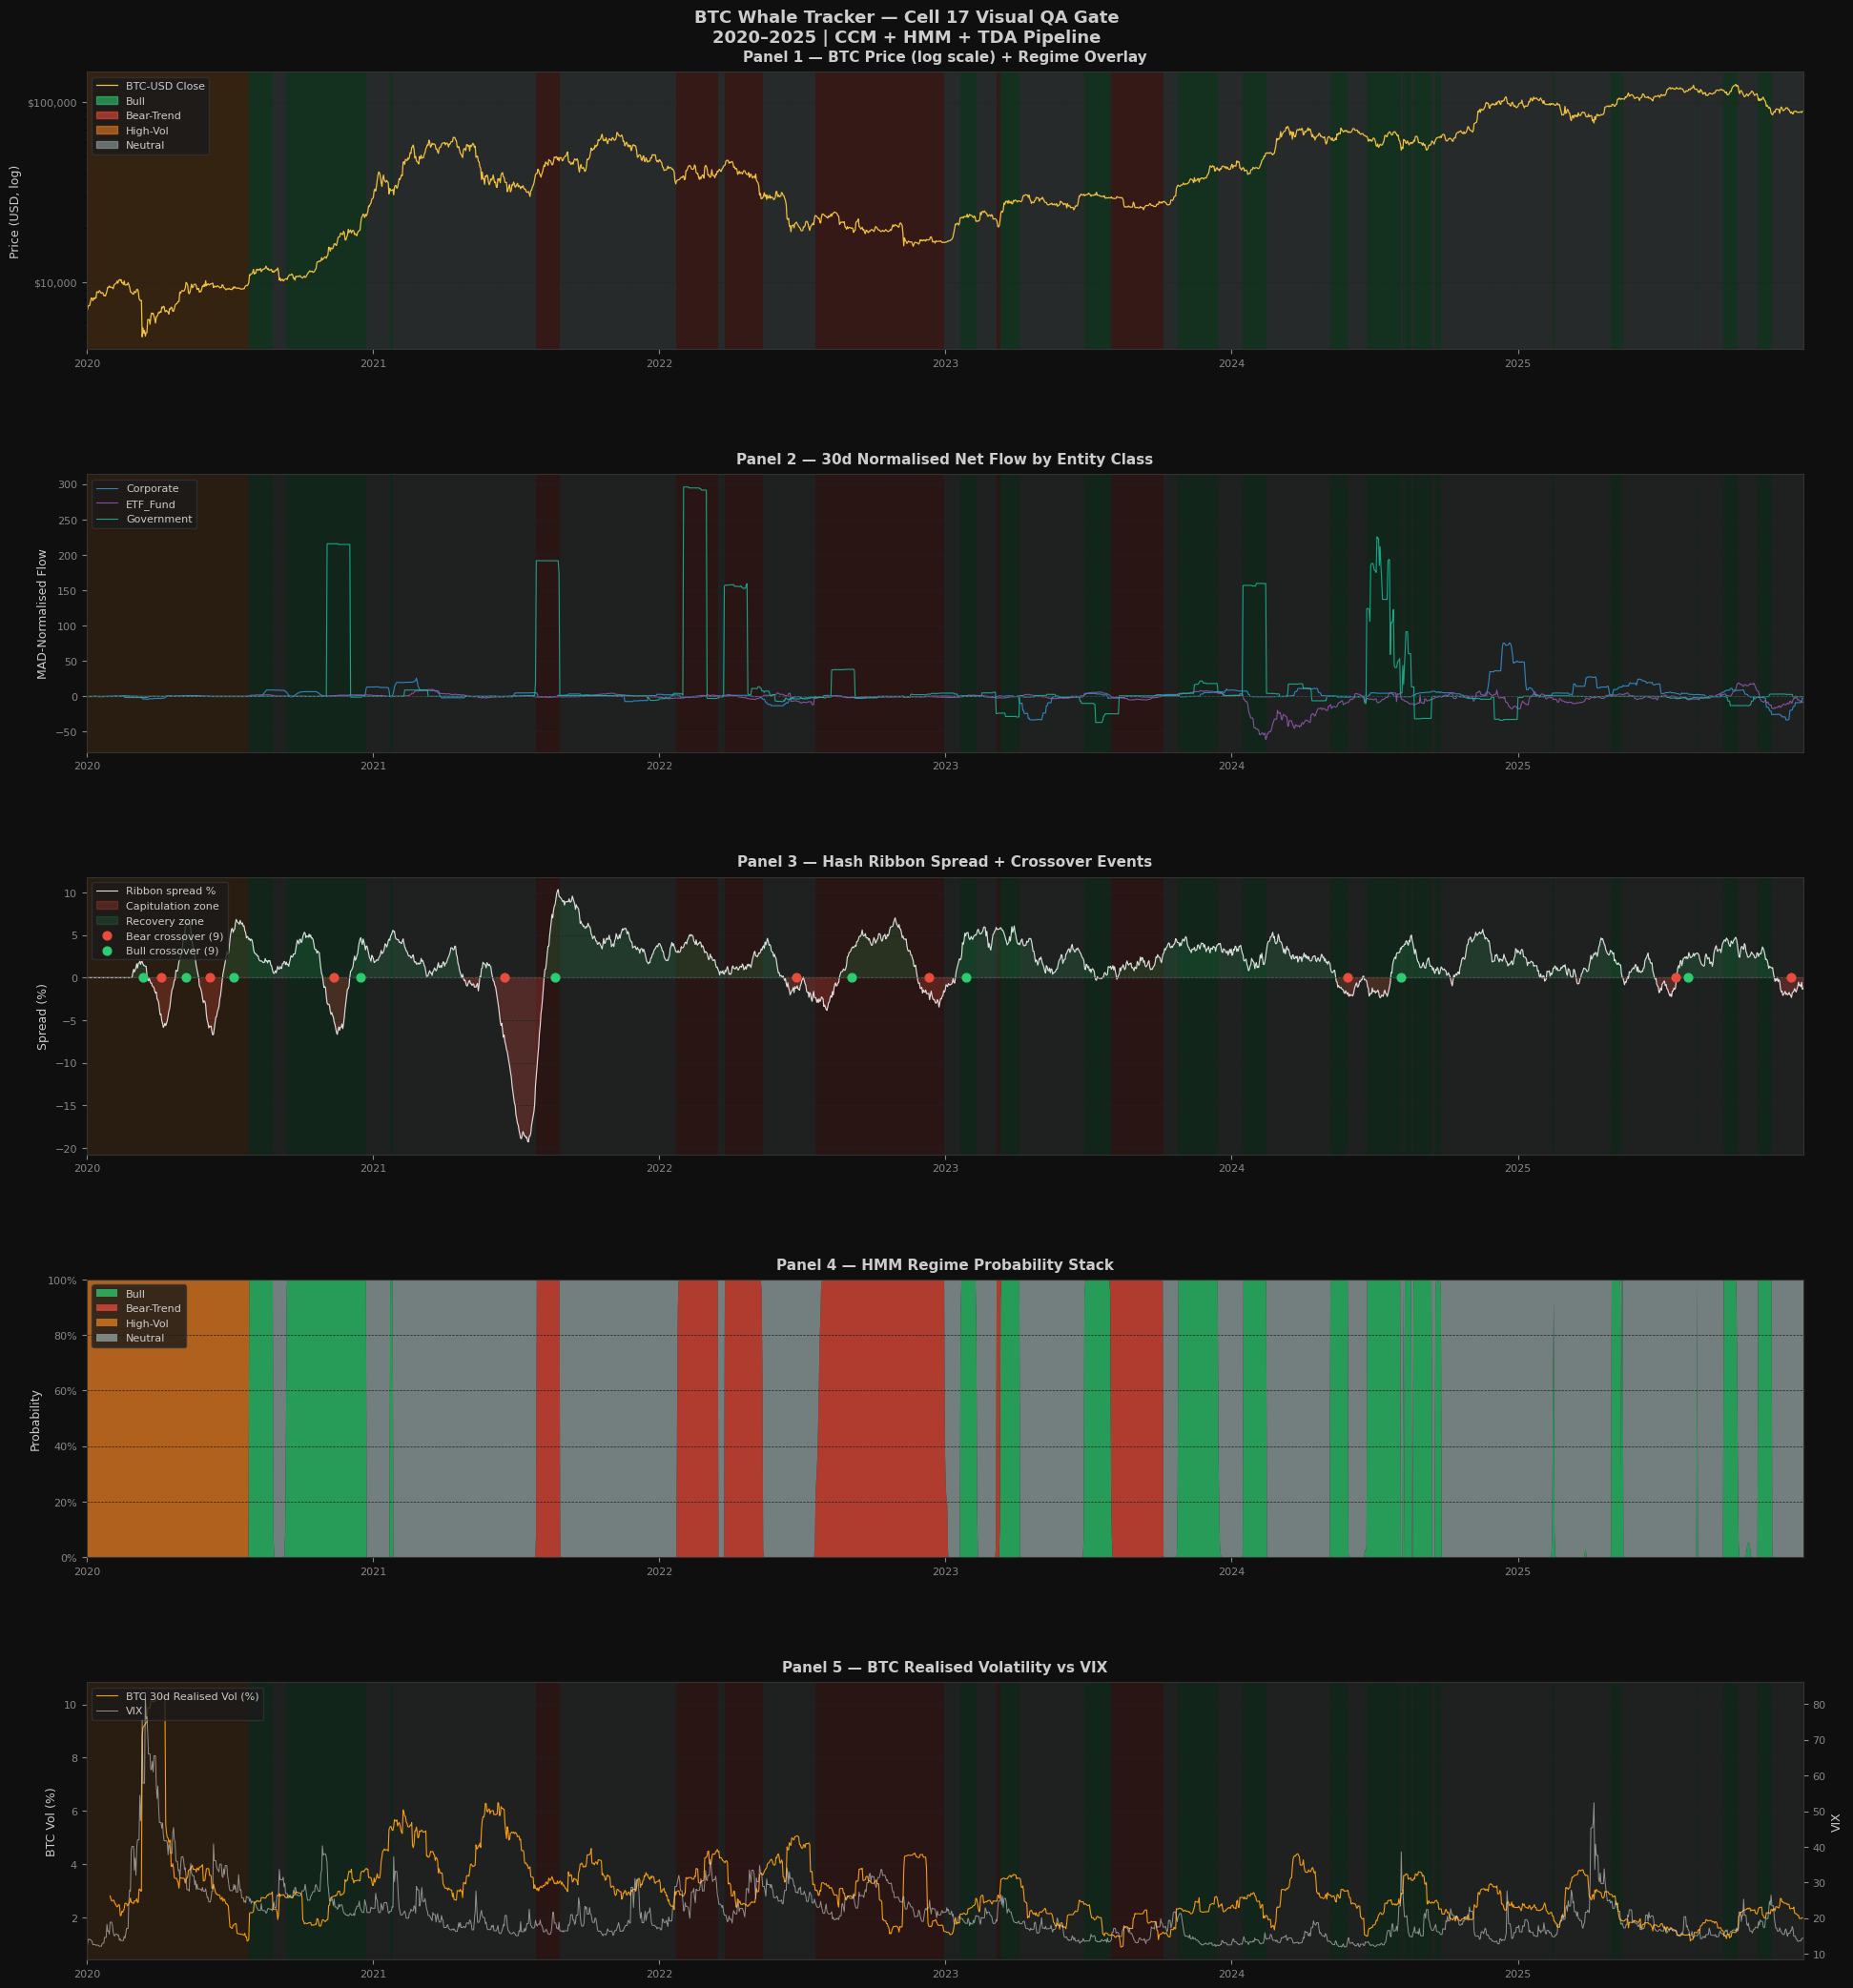


Cell 17 QA chart saved → C:\Projects\crypto-sentiment-trader\outputs\cell17_visual_qa.png
High-res chart saved → C:\Projects\crypto-sentiment-trader\outputs\cell17_visual_qa_hires.png (300 dpi)

Panel CSVs saved to outputs/:
  cell17_panel1_price_regimes.csv                2192 rows
  cell17_panel2_whale_flows.csv                  2192 rows
  cell17_panel3_crossover_events.csv               18 rows
  cell17_panel3_hash_ribbons.csv                 2192 rows
  cell17_panel4_regime_probs.csv                 2192 rows
  cell17_panel5_volatility.csv                   2192 rows

── Visual QA Checklist ───────────────────────────────
Inspect each panel and confirm before proceeding to Cell 18:

  Panel 1 — Price + Regimes
  [ ] Bull (green) covers 2021 run-up and 2023-24 recovery
  [ ] Bear-Trend (red) covers 2022 drawdown
  [ ] High-Vol (orange) covers COVID crash (Mar 2020) and vol spikes
  [ ] Neutral (grey) dominates sideways periods

  Panel 2 — Whale Flows
  [ ] Corporate flows show po

In [26]:
# CELL 17 — VISUALISATION QA GATE
# Visual sign-off on regime labels and signal timelines
# before Cell 18 walk-forward backtest is permitted to run.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from pathlib import Path

# ── Load master dataset ──────────────────────────────────────
df = pd.read_csv(DATA_DIR / "master_dataset.csv", parse_dates=["date"])
print(f"Loaded master_dataset.csv: {len(df)} rows")

# ── Regime colour map ────────────────────────────────────────
REGIME_COLORS = {
    "Bull":       "#2ecc71",   # green
    "Bear-Trend": "#e74c3c",   # red
    "High-Vol":   "#e67e22",   # orange
    "Neutral":    "#95a5a6",   # grey
}

def shade_regimes(ax, df, alpha=0.15):
    """Draw coloured background bands for each regime block."""
    regime_col = df["regime"]
    prev_regime = None
    start_idx = None
    for i, (date, regime) in enumerate(zip(df["date"], regime_col)):
        if regime != prev_regime:
            if prev_regime is not None:
                ax.axvspan(df["date"].iloc[start_idx], date,
                           color=REGIME_COLORS.get(prev_regime, "#cccccc"),
                           alpha=alpha, linewidth=0)
            start_idx = i
            prev_regime = regime
    # Final block
    if prev_regime is not None:
        ax.axvspan(df["date"].iloc[start_idx], df["date"].iloc[-1],
                   color=REGIME_COLORS.get(prev_regime, "#cccccc"),
                   alpha=alpha, linewidth=0)

# ── Legend patches ───────────────────────────────────────────
regime_patches = [
    mpatches.Patch(color=REGIME_COLORS[r], alpha=0.6, label=r)
    for r in ["Bull", "Bear-Trend", "High-Vol", "Neutral"]
]

# ── Figure layout ────────────────────────────────────────────
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#0f0f0f")
gs = GridSpec(5, 1, figure=fig, hspace=0.45,
              top=0.95, bottom=0.05, left=0.07, right=0.97)

LABEL_COLOR  = "#cccccc"
TICK_COLOR   = "#888888"
GRID_COLOR   = "#222222"
SPINE_COLOR  = "#333333"

def style_ax(ax, title, ylabel):
    ax.set_facecolor("#0f0f0f")
    ax.set_title(title, color=LABEL_COLOR, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel(ylabel, color=LABEL_COLOR, fontsize=9)
    ax.tick_params(colors=TICK_COLOR, labelsize=8)
    ax.yaxis.label.set_color(LABEL_COLOR)
    ax.xaxis.label.set_color(LABEL_COLOR)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.5, linestyle="--")
    ax.set_xlim(df["date"].iloc[0], df["date"].iloc[-1])

# ── Panel 1 — BTC Price + Regime Overlay ────────────────────
ax1 = fig.add_subplot(gs[0])
shade_regimes(ax1, df, alpha=0.18)
ax1.plot(df["date"], df["close"], color="#f0c040", linewidth=0.9, label="BTC-USD Close")
ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
style_ax(ax1, "Panel 1 — BTC Price (log scale) + Regime Overlay", "Price (USD, log)")
ax1.legend(handles=[ax1.lines[0]] + regime_patches,
           loc="upper left", fontsize=8,
           facecolor="#1a1a1a", edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── Panel 2 — Whale Flow Timelines ──────────────────────────
ax2 = fig.add_subplot(gs[1])
shade_regimes(ax2, df, alpha=0.12)

FLOW_COLS = {
    "Corporate":  ("net_flow_30d_norm__Corporate",  "#3498db"),
    "ETF_Fund":   ("net_flow_30d_norm__ETF_Fund",   "#9b59b6"),
    "Government": ("net_flow_30d_norm__Government", "#1abc9c"),
}
for label, (col, color) in FLOW_COLS.items():
    if col in df.columns:
        ax2.plot(df["date"], df[col], color=color, linewidth=0.8,
                 alpha=0.85, label=label)

ax2.axhline(0, color="#444444", linewidth=0.6, linestyle="--")
style_ax(ax2, "Panel 2 — 30d Normalised Net Flow by Entity Class", "MAD-Normalised Flow")
ax2.legend(loc="upper left", fontsize=8,
           facecolor="#1a1a1a", edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── Panel 3 — Hash Ribbon Spread + Crossovers ───────────────
ax3 = fig.add_subplot(gs[2])
shade_regimes(ax3, df, alpha=0.12)

ax3.plot(df["date"], df["ribbon_spread_pct"] * 100, color="#e0e0e0",
         linewidth=0.8, label="Ribbon spread %")
ax3.axhline(0, color="#555555", linewidth=0.6, linestyle="--")
ax3.fill_between(df["date"], df["ribbon_spread_pct"] * 100, 0,
                 where=(df["ribbon_spread_pct"] < 0),
                 color="#e74c3c", alpha=0.25, label="Capitulation zone")
ax3.fill_between(df["date"], df["ribbon_spread_pct"] * 100, 0,
                 where=(df["ribbon_spread_pct"] > 0),
                 color="#2ecc71", alpha=0.15, label="Recovery zone")

# Mark crossover events
crossovers = df[df["crossover_direction"] != 0]
bear_cross = crossovers[crossovers["crossover_direction"] == -1]
bull_cross = crossovers[crossovers["crossover_direction"] ==  1]
ax3.scatter(bear_cross["date"], [0] * len(bear_cross),
            color="#e74c3c", s=40, zorder=5, label=f"Bear crossover ({len(bear_cross)})")
ax3.scatter(bull_cross["date"], [0] * len(bull_cross),
            color="#2ecc71", s=40, zorder=5, label=f"Bull crossover ({len(bull_cross)})")

style_ax(ax3, "Panel 3 — Hash Ribbon Spread + Crossover Events", "Spread (%)")
ax3.legend(loc="upper left", fontsize=8,
           facecolor="#1a1a1a", edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── Panel 4 — Regime Probability Heatmap ────────────────────
ax4 = fig.add_subplot(gs[3])

prob_cols = ["prob_Bull", "prob_Bear_Trend", "prob_High_Vol", "prob_Neutral"]
prob_colors = ["#2ecc71", "#e74c3c", "#e67e22", "#95a5a6"]
prob_labels = ["Bull", "Bear-Trend", "High-Vol", "Neutral"]

bottom = np.zeros(len(df))
for col, color, label in zip(prob_cols, prob_colors, prob_labels):
    if col in df.columns:
        vals = df[col].fillna(0).values
        ax4.fill_between(df["date"], bottom, bottom + vals,
                         color=color, alpha=0.75, label=label, linewidth=0)
        bottom += vals

style_ax(ax4, "Panel 4 — HMM Regime Probability Stack", "Probability")
ax4.set_ylim(0, 1)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax4.legend(loc="upper left", fontsize=8,
           facecolor="#1a1a1a", edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── Panel 5 — Volatility + VIX ──────────────────────────────
ax5 = fig.add_subplot(gs[4])
shade_regimes(ax5, df, alpha=0.12)

ax5_twin = ax5.twinx()
ax5.plot(df["date"], df["rolling_vol_30d"] * 100, color="#f39c12",
         linewidth=0.8, label="BTC 30d Realised Vol (%)")
ax5_twin.plot(df["date"], df["vix"], color="#e0e0e0", linewidth=0.7,
              alpha=0.6, label="VIX")

style_ax(ax5, "Panel 5 — BTC Realised Volatility vs VIX", "BTC Vol (%)")
ax5_twin.set_ylabel("VIX", color=LABEL_COLOR, fontsize=9)
ax5_twin.tick_params(colors=TICK_COLOR, labelsize=8)
ax5_twin.set_facecolor("#0f0f0f")
for spine in ax5_twin.spines.values():
    spine.set_edgecolor(SPINE_COLOR)

lines1, labels1 = ax5.get_legend_handles_labels()
lines2, labels2 = ax5_twin.get_legend_handles_labels()
ax5.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8,
           facecolor="#1a1a1a", edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── Title & save ─────────────────────────────────────────────
fig.suptitle("BTC Whale Tracker — Cell 17 Visual QA Gate\n2020–2025 | CCM + HMM + TDA Pipeline",
             color=LABEL_COLOR, fontsize=13, fontweight="bold")

out_path = OUTPUT_DIR / "cell17_visual_qa.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\nCell 17 QA chart saved → {out_path}")

# ── High-res image export ────────────────────────────────────
hires_path = OUTPUT_DIR / "cell17_visual_qa_hires.png"
fig.savefig(hires_path, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"High-res chart saved → {hires_path} (300 dpi)")

# ── Export panel data to CSV for quantitative analysis ───────
# Panel 1 — Price + regimes
(df[["date", "close", "log_return", "regime"]]
 .to_csv(OUTPUT_DIR / "cell17_panel1_price_regimes.csv", index=False))

# Panel 2 — Whale flows
flow_cols = ["date", "regime",
             "net_flow_30d_norm__Corporate",
             "net_flow_30d_norm__ETF_Fund",
             "net_flow_30d_norm__Government"]
(df[[c for c in flow_cols if c in df.columns]]
 .to_csv(OUTPUT_DIR / "cell17_panel2_whale_flows.csv", index=False))

# Panel 3 — Hash ribbons
ribbon_cols = ["date", "regime", "ribbon_spread_pct",
               "ribbon_signal", "crossover_direction", "days_since_crossover"]
(df[[c for c in ribbon_cols if c in df.columns]]
 .to_csv(OUTPUT_DIR / "cell17_panel3_hash_ribbons.csv", index=False))

# Panel 4 — Regime probabilities
prob_cols_export = ["date", "regime", "regime_label",
                    "prob_Bull", "prob_Bear_Trend", "prob_High_Vol", "prob_Neutral"]
(df[[c for c in prob_cols_export if c in df.columns]]
 .to_csv(OUTPUT_DIR / "cell17_panel4_regime_probs.csv", index=False))

# Panel 5 — Volatility
vol_cols = ["date", "regime", "rolling_vol_30d", "vix"]
(df[[c for c in vol_cols if c in df.columns]]
 .to_csv(OUTPUT_DIR / "cell17_panel5_volatility.csv", index=False))

# Crossover events only (sparse — useful for event study)
(df[df["crossover_direction"] != 0]
 [["date", "regime", "crossover_direction", "ribbon_spread_pct", "close"]]
 .to_csv(OUTPUT_DIR / "cell17_panel3_crossover_events.csv", index=False))

print("\nPanel CSVs saved to outputs/:")
for f in sorted(OUTPUT_DIR.glob("cell17_panel*.csv")):
    rows = pd.read_csv(f).shape[0]
    print(f"  {f.name:<45} {rows:>5} rows")

# ── QA Sign-off Checklist ────────────────────────────────────
print("""
── Visual QA Checklist ───────────────────────────────
Inspect each panel and confirm before proceeding to Cell 18:

  Panel 1 — Price + Regimes
  [ ] Bull (green) covers 2021 run-up and 2023-24 recovery
  [ ] Bear-Trend (red) covers 2022 drawdown
  [ ] High-Vol (orange) covers COVID crash (Mar 2020) and vol spikes
  [ ] Neutral (grey) dominates sideways periods

  Panel 2 — Whale Flows
  [ ] Corporate flows show positive signal in Neutral regime
  [ ] ETF_Fund flows elevated pre-2024 (pre_ETF causal period)
  [ ] No obvious look-ahead artifacts (flows lead price, not lag)

  Panel 3 — Hash Ribbons
  [ ] Bear crossovers align with 2022 bear market
  [ ] Bull crossovers align with recovery periods
  [ ] 18 crossover events visible (per Cell 9 output)

  Panel 4 — Regime Probabilities
  [ ] HMM shows high confidence (one prob near 1.0) in trend periods
  [ ] Uncertainty (mixed probs) in transition periods — expected
  [ ] No single regime dominates entire dataset pathologically

  Panel 5 — Volatility
  [ ] High-Vol regime aligns with VIX spikes
  [ ] BTC realised vol spikes match orange regime bands

If all panels pass inspection, Cell 18 is cleared to run.
""")

In [27]:
# CELL 18 — REGIME-AWARE WALK-FORWARD BACKTEST (v2)
# Rebuilt on three-pillar signal architecture:
#   Pillar 1: Corp-ETF Divergence (primary, regime-agnostic)
#   Pillar 2: ETF_Fund Contrarian in Bull (secondary)
#   Pillar 3: Corporate | Ribbon Bear multiplier (tertiary)
# 20-day holding period | Monthly rebalancing | Vol-targeted
# ============================================================

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────
TARGET_VOL         = 1.00    # annualised vol target
VOL_LOOKBACK       = 30      # days for realised vol estimation
REBAL_FREQ         = 20      # rebalance every 20 trading days
HOLDING_PERIOD     = 20      # signal horizon matches flow autocorrelation decay
SIGNAL_WINSOR_PCT  = 0.95    # winsorise divergence signal at 95th percentile
RIBBON_BEAR_THRESH = -0.005  # ribbon_spread_pct below this = capitulation
RIBBON_MULT        = 1.00    # multiplier disabled — degrades Sharpe per Cell 20
ETF_CONTRARIAN_PCT = 0.10    # top/bottom decile threshold for Pillar 2
TRAIN_END          = "2023-12-31"
TEST_START         = "2024-01-01"
TEST_END           = "2025-12-31"
SIGNAL_THRESHOLD   = 0.005   # lowered from 0.010 per Cell 20 sweep 7
W2_BULL_DAMP       = 0.50    # halve ETF contrarian weight in Bull — fixes 159d drawdown

# Pillar weights — sum to 1.0
W1 = 0.80   # Corp-ETF Divergence — raised from 0.60 per Cell 20 sweep 1
W2 = 0.20   # ETF Contrarian in Bull — reduced from 0.40

print("=" * 60)
print("CELL 18 v2 — THREE-PILLAR SIGNAL BACKTEST")
print(f"  Target vol      : {TARGET_VOL:.0%} annualised")
print(f"  Rebal frequency : every {REBAL_FREQ} trading days")
print(f"  Holding period  : {HOLDING_PERIOD} days")
print(f"  Pillar weights  : P1={W1}  P2={W2}")
print("=" * 60)

# ── Load master dataset ───────────────────────────────────────
df = pd.read_csv(DATA_DIR / "master_dataset.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df.dropna(subset=["close", "log_return", "regime"])

# ── Realised vol ──────────────────────────────────────────────
df["realised_vol"] = (
    df["log_return"]
      .rolling(VOL_LOOKBACK, min_periods=10)
      .std() * np.sqrt(365)
).bfill().ffill()

# ── Train / test split ────────────────────────────────────────
train_mask = df["date"] <= pd.Timestamp(TRAIN_END)
test_mask  = (df["date"] >= pd.Timestamp(TEST_START)) & \
             (df["date"] <= pd.Timestamp(TEST_END))

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy().reset_index(drop=True)

print(f"\nTrain : {len(df_train)} rows  "
      f"({df_train.date.min().date()} → {df_train.date.max().date()})")
print(f"Test  : {len(df_test)} rows   "
      f"({df_test.date.min().date()} → {df_test.date.max().date()})")

# ── Step 1: Compute raw signals ───────────────────────────────
print("\n── Step 1: Computing signal pillars ──────────────────")

# Pillar 1 — Corp-ETF Divergence (winsorised)
# Long when Corporates accumulate faster than ETFs
# Short when ETFs buying faster than Corporates
df_test["p1_raw"] = (
    df_test["net_flow_30d_norm__Corporate"] -
    df_test["net_flow_30d_norm__ETF_Fund"]
)
p1_lo = df_test["p1_raw"].quantile(1 - SIGNAL_WINSOR_PCT)
p1_hi = df_test["p1_raw"].quantile(SIGNAL_WINSOR_PCT)
df_test["p1_signal"] = df_test["p1_raw"].clip(p1_lo, p1_hi)

# Normalise P1 to [-1, +1]
p1_max = df_test["p1_signal"].abs().max()
df_test["p1_norm"] = df_test["p1_signal"] / p1_max if p1_max > 0 else 0.0

# Pillar 2 — ETF_Fund Contrarian in Bull (sign-flipped)
# In Bull: high ETF inflow → BEARISH, high ETF outflow → BULLISH
# Active only in Bull regime — zero elsewhere
etf_p10 = df_train["net_flow_30d_norm__ETF_Fund"].quantile(0.10)
etf_p90 = df_train["net_flow_30d_norm__ETF_Fund"].quantile(0.90)

def etf_contrarian_score(row):
    if row["regime"] != "Bull":
        return 0.0
    etf = row["net_flow_30d_norm__ETF_Fund"]
    if etf >= etf_p90:
        return -1.0    # top decile inflow → short signal
    elif etf <= etf_p10:
        return +1.0    # bottom decile outflow → long signal
    else:
        # Linear interpolation between deciles
        mid = (etf_p90 + etf_p10) / 2
        return -np.sign(etf - mid) * abs(etf - mid) / (etf_p90 - mid)

df_test["p2_norm"] = df_test.apply(etf_contrarian_score, axis=1)

print(f"  P1 Corp-ETF divergence: "
      f"winsor=[{p1_lo:.3f}, {p1_hi:.3f}]  "
      f"pct_positive={( df_test['p1_raw']>0).mean():.1%}")
print(f"  P2 ETF contrarian: "
      f"train p10={etf_p10:.3f}  p90={etf_p90:.3f}  "
      f"Bull days in test={( df_test['regime']=='Bull').sum()}")

# ── Step 2: Combine pillars into composite signal ─────────────
print("\n── Step 2: Composite signal ──────────────────────────")

def composite_fn(row):
    w2_eff = W2 * (W2_BULL_DAMP if row["regime"] == "Bull" else 1.0)
    return W1 * row["p1_norm"] + w2_eff * row["p2_norm"]

df_test["composite_signal"] = df_test.apply(composite_fn, axis=1)

# Pillar 3 — Ribbon Bear multiplier (applied at position stage)
df_test["ribbon_bear"] = df_test["ribbon_spread_pct"] < RIBBON_BEAR_THRESH

print(f"  Composite signal stats: "
      f"mean={df_test['composite_signal'].mean():+.4f}  "
      f"std={df_test['composite_signal'].std():.4f}")
print(f"  Ribbon Bear days in test: {df_test['ribbon_bear'].sum()}")

# ── Step 3: Generate positions with monthly rebalancing ───────
print("\n── Step 3: Generating positions ──────────────────────")

# Mark rebalance days — every REBAL_FREQ trading days
rebal_flags = [False] * len(df_test)
for i in range(0, len(df_test), REBAL_FREQ):
    rebal_flags[i] = True
df_test["rebal_day"] = rebal_flags

positions = []
current_position = 0.0

for i, row in df_test.iterrows():
    if row["rebal_day"]:
        signal = row["composite_signal"]
        rv     = row["realised_vol"]

        if rv > 0 and abs(signal) > 0.01:
            # Vol-targeted base position
            vol_scalar = min(TARGET_VOL / rv, 2.0)
            base_pos   = np.sign(signal) * vol_scalar * abs(signal)

            # Pillar 3: Ribbon Bear multiplier — only on long positions
            # (Corporate accumulation during miner stress is highest conviction)
            if row["ribbon_bear"] and base_pos > 0:
                base_pos *= RIBBON_MULT

            # Bear-Trend override — zero all positions
            if row["regime"] == "Bear-Trend":
                base_pos = 0.0

            # High-Vol risk reduction
            if row["regime"] == "High-Vol":
                base_pos *= 0.5

            current_position = np.clip(base_pos, -2.0, 2.0)
        else:
            current_position = 0.0

    positions.append(current_position)

df_test["position"] = positions

# ── Step 4: Compute strategy returns ─────────────────────────
# Lag position by 1 day — signal on day t executes at open t+1
print("\n── Step 4: Computing returns ─────────────────────────")

df_test["position_lagged"] = df_test["position"].shift(1).fillna(0.0)
df_test["strategy_return"] = df_test["position_lagged"] * df_test["log_return"]
df_test["bh_return"]       = df_test["log_return"]

df_test["cum_strategy"] = df_test["strategy_return"].cumsum().apply(np.exp)
df_test["cum_bh"]       = df_test["bh_return"].cumsum().apply(np.exp)

# ── Step 5: Performance metrics ───────────────────────────────
print("\n── Step 5: Performance metrics ───────────────────────")

def performance_metrics(returns, label):
    r       = returns.dropna()
    ann_ret = r.mean() * 365
    ann_vol = r.std()  * np.sqrt(365)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = r.cumsum().apply(np.exp)
    dd      = cum / cum.cummax() - 1
    mdd     = dd.min()
    calmar  = ann_ret / abs(mdd) if mdd != 0 else np.nan
    downside = r[r < 0].std() * np.sqrt(365)
    sortino  = ann_ret / downside if downside > 0 else np.nan
    win_rate = (r > 0).mean()
    total    = np.exp(r.sum()) - 1

    print(f"\n  [{label}]")
    print(f"    Total return    : {total:+.2%}")
    print(f"    Ann. return     : {ann_ret:+.2%}")
    print(f"    Ann. volatility : {ann_vol:.2%}")
    print(f"    Sharpe ratio    : {sharpe:.3f}")
    print(f"    Sortino ratio   : {sortino:.3f}")
    print(f"    Max drawdown    : {mdd:.2%}")
    print(f"    Calmar ratio    : {calmar:.3f}")
    print(f"    Win rate        : {win_rate:.2%}")

    return {
        "label": label, "total_return": total,
        "ann_return": ann_ret, "ann_vol": ann_vol,
        "sharpe": sharpe, "sortino": sortino,
        "mdd": mdd, "calmar": calmar, "win_rate": win_rate,
    }

m_strat = performance_metrics(df_test["strategy_return"], "Strategy v2 (three-pillar)")
m_bh    = performance_metrics(df_test["bh_return"],       "Buy & Hold")

# ── Step 6: Per-regime breakdown ─────────────────────────────
print("\n── Step 6: Per-regime breakdown ──────────────────────")
print(f"  {'Regime':<12} {'Days':>5} {'Strat Ann':>10} "
      f"{'B&H Ann':>9} {'Sharpe':>8} {'AvgPos':>8}")

regime_metrics = []
for regime in ["Bull", "Bear-Trend", "High-Vol", "Neutral"]:
    rdf = df_test[df_test["regime"] == regime]
    if len(rdf) < 5:
        continue
    sr       = rdf["strategy_return"].dropna()
    bh       = rdf["bh_return"].dropna()
    s_ann    = sr.mean() * 365
    b_ann    = bh.mean() * 365
    s_vol    = sr.std()  * np.sqrt(365)
    sharpe   = s_ann / s_vol if s_vol > 0 else np.nan
    avg_pos  = rdf["position_lagged"].mean()
    print(f"  {regime:<12} {len(rdf):>5} {s_ann:>+10.2%} "
          f"{b_ann:>+9.2%} {sharpe:>8.3f} {avg_pos:>8.3f}")
    regime_metrics.append({
        "regime": regime, "days": len(rdf),
        "strat_ann": s_ann, "bh_ann": b_ann,
        "sharpe": sharpe, "avg_position": avg_pos,
    })

# ── Step 7: Signal pillar attribution ────────────────────────
print("\n── Step 7: Pillar attribution ────────────────────────")

# Isolate P1-only and P2-only returns for attribution
df_test["p1_only_pos"] = df_test.apply(
    lambda r: np.clip(
        np.sign(r["p1_norm"]) * min(TARGET_VOL / r["realised_vol"], 2.0)
        * abs(r["p1_norm"]) if r["realised_vol"] > 0 and abs(r["p1_norm"]) > 0.01
        else 0.0, -2.0, 2.0
    ), axis=1
).shift(1).fillna(0)

df_test["p2_only_pos"] = df_test.apply(
    lambda r: np.clip(
        np.sign(r["p2_norm"]) * min(TARGET_VOL / r["realised_vol"], 2.0)
        * abs(r["p2_norm"]) if r["realised_vol"] > 0 and abs(r["p2_norm"]) > 0.01
        else 0.0, -2.0, 2.0
    ), axis=1
).shift(1).fillna(0)

p1_ret = (df_test["p1_only_pos"] * df_test["log_return"]).sum()
p2_ret = (df_test["p2_only_pos"] * df_test["log_return"]).sum()

print(f"  P1 Corp-ETF Divergence  : cumulative log return = {p1_ret:+.4f}  "
      f"({np.exp(p1_ret)-1:+.2%})")
print(f"  P2 ETF Contrarian/Bull  : cumulative log return = {p2_ret:+.4f}  "
      f"({np.exp(p2_ret)-1:+.2%})")
print(f"  P3 Ribbon Bear days     : "
      f"{df_test['ribbon_bear'].sum()} days with multiplier active")

# ── Step 8: Position exposure ─────────────────────────────────
print("\n── Step 8: Position exposure ─────────────────────────")
pos = df_test["position_lagged"]
print(f"  Long days   : {(pos > 0).sum()}  ({(pos > 0).mean():.1%})")
print(f"  Short days  : {(pos < 0).sum()}  ({(pos < 0).mean():.1%})")
print(f"  Flat days   : {(pos == 0).sum()} ({(pos == 0).mean():.1%})")
print(f"  Mean long   : {pos[pos > 0].mean():.3f}×")
print(f"  Mean short  : {pos[pos < 0].mean():.3f}×")
print(f"  Max leverage: {pos.abs().max():.3f}×")
print(f"  Rebal days  : {df_test['rebal_day'].sum()}")

# ── Step 9: Save ──────────────────────────────────────────────
out_bt   = DATA_DIR   / "backtest_results.csv"
out_perf = OUTPUT_DIR / "cell18_performance_summary.csv"
out_reg  = OUTPUT_DIR / "cell18_regime_breakdown.csv"

df_test.to_csv(out_bt, index=False)
pd.DataFrame([m_strat, m_bh]).to_csv(out_perf, index=False)
pd.DataFrame(regime_metrics).to_csv(out_reg, index=False)

print(f"\n── Output ────────────────────────────────────────────")
print(f"  backtest_results.csv           → {out_bt}")
print(f"  cell18_performance_summary.csv → {out_perf}")
print(f"  cell18_regime_breakdown.csv    → {out_reg}")
print(f"  Backtest rows : {len(df_test)}")
print(f"\nCell 18 v2 complete  ✓  — ready for Cell 19")

CELL 18 v2 — THREE-PILLAR SIGNAL BACKTEST
  Target vol      : 100% annualised
  Rebal frequency : every 20 trading days
  Holding period  : 20 days
  Pillar weights  : P1=0.8  P2=0.2

Train : 1460 rows  (2020-01-02 → 2023-12-31)
Test  : 730 rows   (2024-01-01 → 2025-12-30)

── Step 1: Computing signal pillars ──────────────────
  P1 Corp-ETF divergence: winsor=[-10.388, 53.118]  pct_positive=81.2%
  P2 ETF contrarian: train p10=-2.137  p90=3.574  Bull days in test=191

── Step 2: Composite signal ──────────────────────────
  Composite signal stats: mean=+0.2130  std=0.2657
  Ribbon Bear days in test: 119

── Step 3: Generating positions ──────────────────────

── Step 4: Computing returns ─────────────────────────

── Step 5: Performance metrics ───────────────────────

  [Strategy v2 (three-pillar)]
    Total return    : +123.19%
    Ann. return     : +40.14%
    Ann. volatility : 30.95%
    Sharpe ratio    : 1.297
    Sortino ratio   : 1.826
    Max drawdown    : -17.25%
    Calmar r

CELL 19 — PERFORMANCE METRICS & ATTRIBUTION
  Period : 2024-01-01 → 2025-12-30
  Days   : 730

══ SECTION 1 — AGGREGATE PERFORMANCE ════════════════

  ── Strategy v2 ──
    Total return      : +123.19%
    Ann. return       : +40.14%
    Ann. volatility   : 30.95%
    Sharpe ratio      : 1.297
    Sortino ratio     : 1.826
    Calmar ratio      : 2.327
    Max drawdown      : -17.25%
    Win rate          : 49.73%
    Avg win / loss    : +0.0099 / -0.0081
    P&L ratio         : 1.227
    Daily expectancy  : +0.000868
    VaR 95% (daily)   : -0.0255
    CVaR 95% (daily)  : -0.0414

  ── Buy & Hold ──
    Total return      : +109.23%
    Ann. return       : +36.91%
    Ann. volatility   : 47.90%
    Sharpe ratio      : 0.771
    Sortino ratio     : 1.172
    Calmar ratio      : 1.148
    Max drawdown      : -32.15%
    Win rate          : 51.10%
    Avg win / loss    : +0.0186 / -0.0174
    P&L ratio         : 1.071
    Daily expectancy  : +0.001011
    VaR 95% (daily)   : -0.0402
    

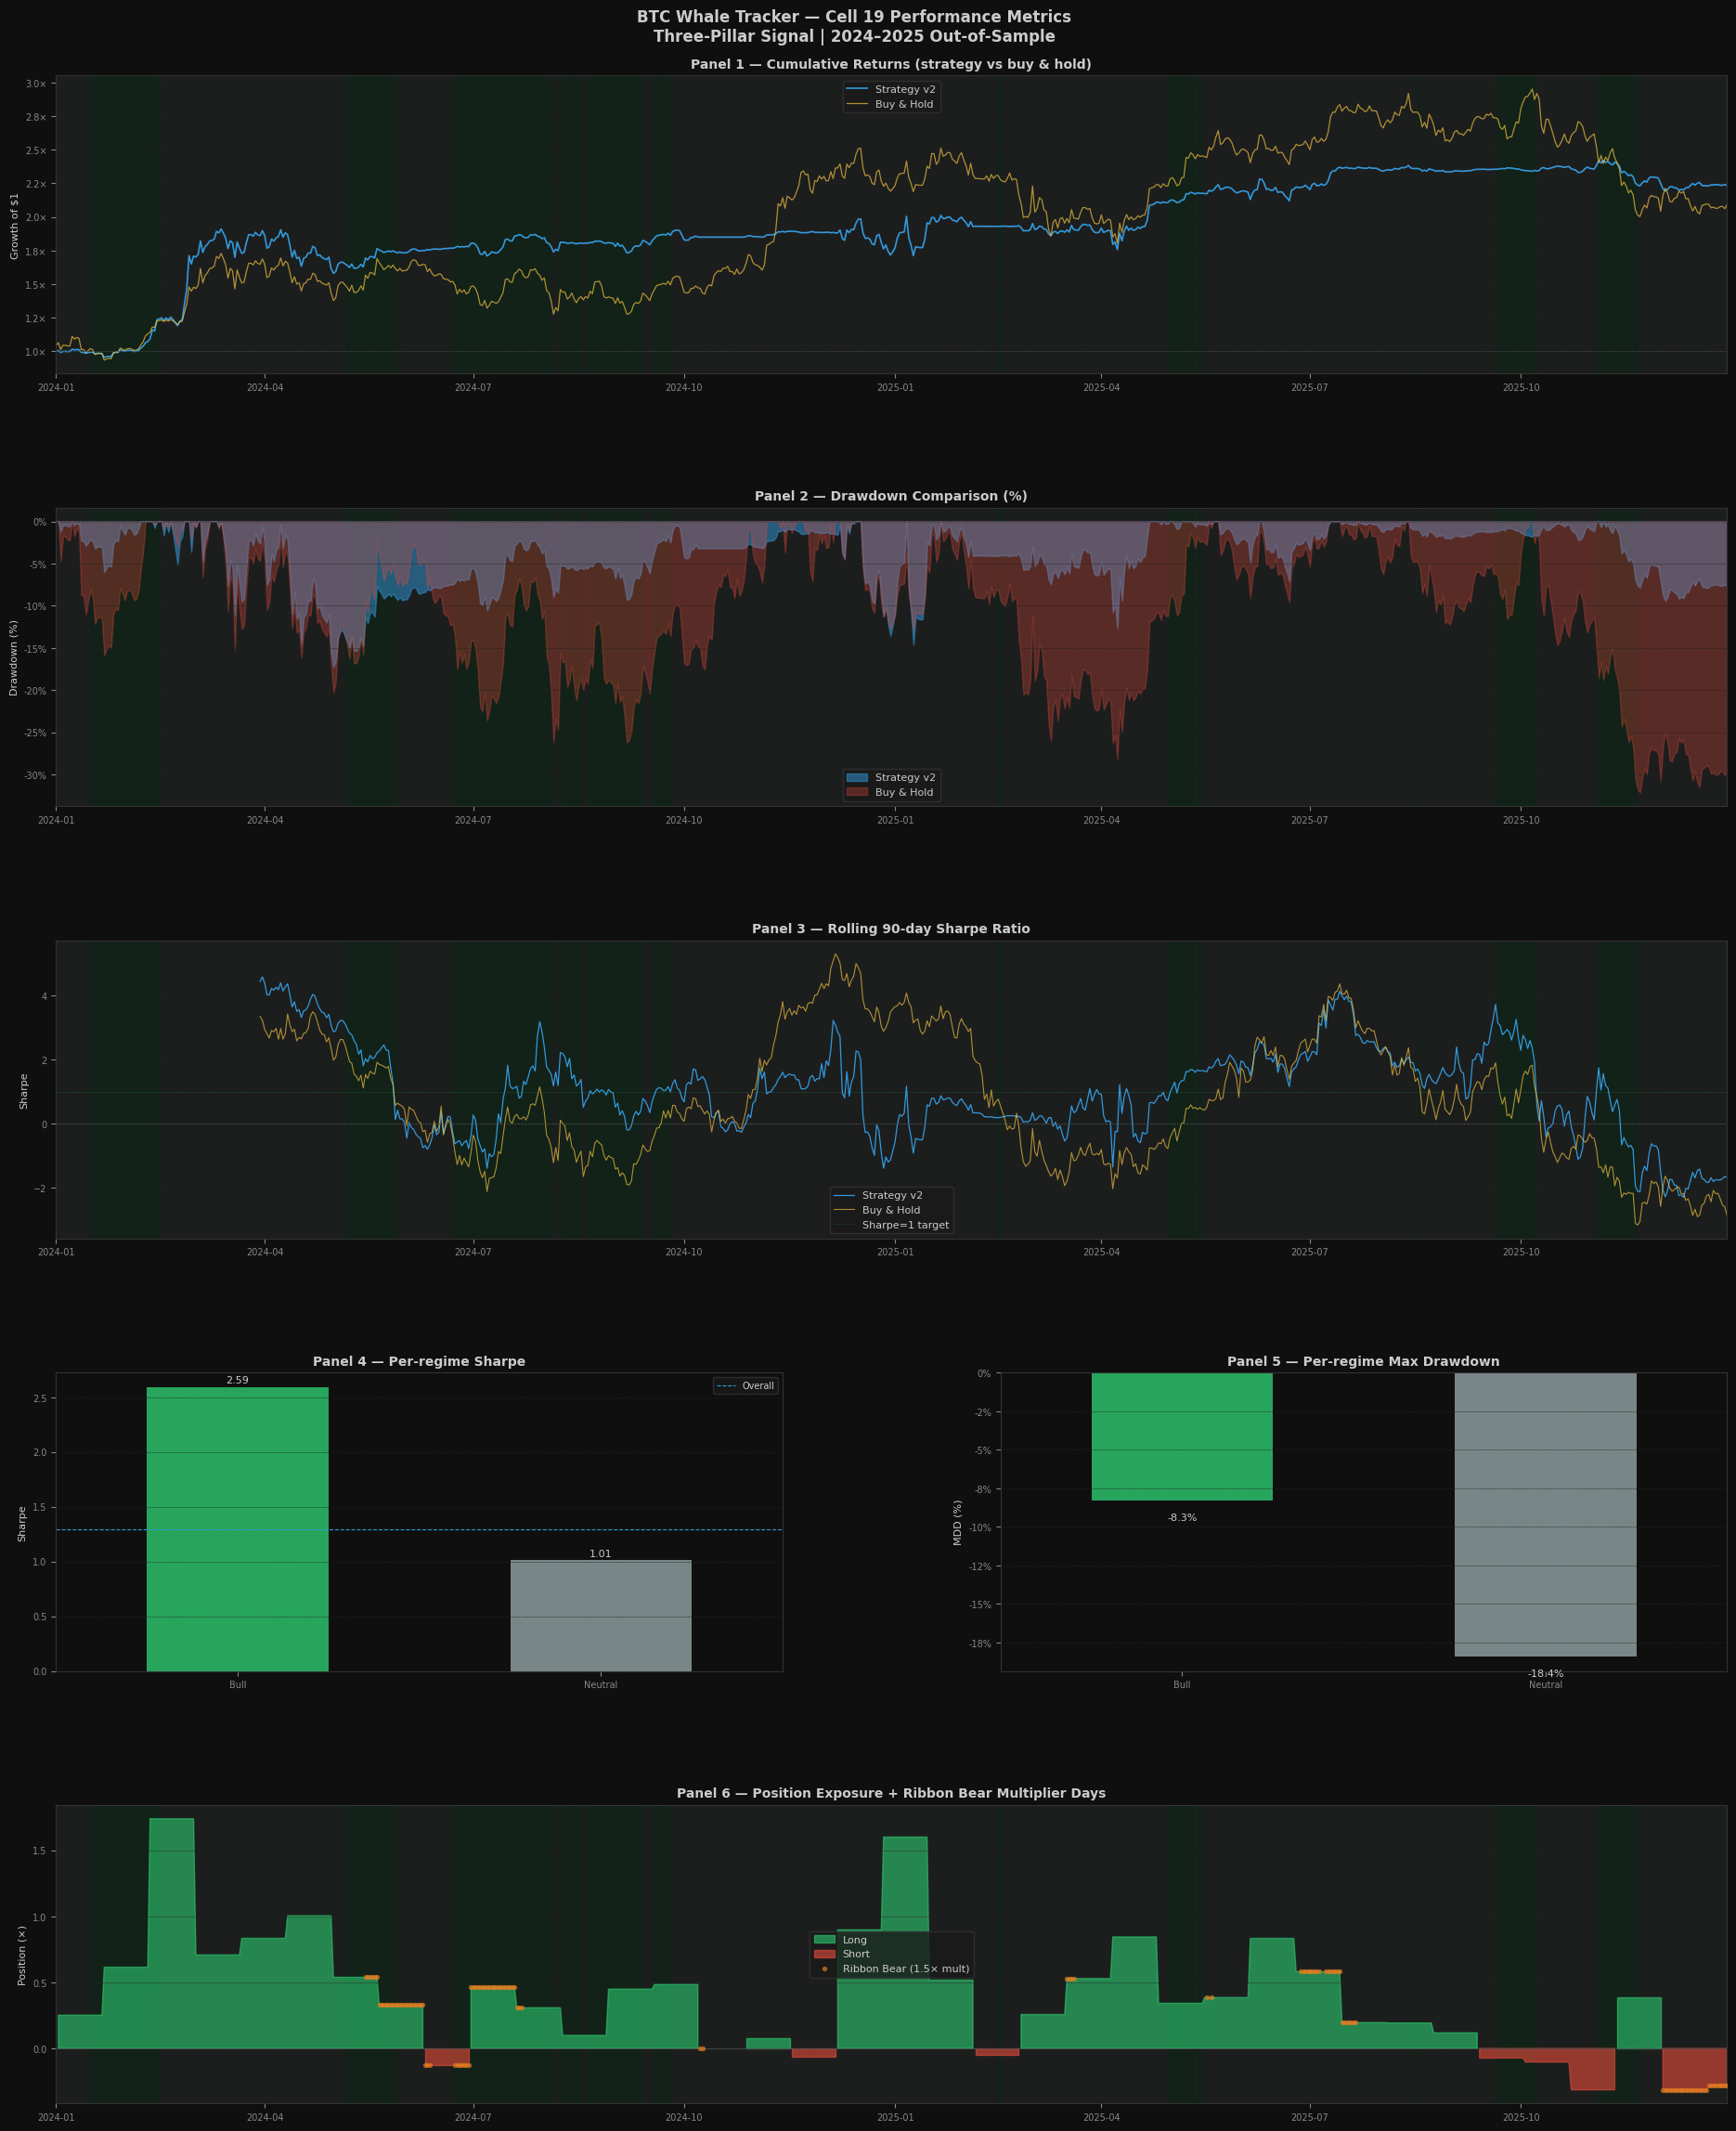

  Charts saved → C:\Projects\crypto-sentiment-trader\outputs\cell19_performance_metrics.png (150dpi) + C:\Projects\crypto-sentiment-trader\outputs\cell19_performance_metrics_hires.png (300dpi)
  CSVs saved → outputs/cell19_*.csv

Cell 19 complete  ✓  — ready for Cell 20 sensitivity analysis


In [28]:
# CELL 19 — PERFORMANCE METRICS & ATTRIBUTION
# Per-regime Sharpe, Sortino, drawdown analysis

# Win rate decomposition, Ribbon Bear multiplier attribution
# Rolling performance, drawdown periods, signal quality
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from pathlib import Path

# ── Load backtest results ─────────────────────────────────────
df = pd.read_csv(DATA_DIR / "backtest_results.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df = df.dropna(subset=["strategy_return", "bh_return"])

print("=" * 60)
print("CELL 19 — PERFORMANCE METRICS & ATTRIBUTION")
print(f"  Period : {df.date.min().date()} → {df.date.max().date()}")
print(f"  Days   : {len(df)}")
print("=" * 60)

REGIMES       = ["Bull", "Bear-Trend", "High-Vol", "Neutral"]
REGIME_COLORS = {
    "Bull":       "#2ecc71",
    "Bear-Trend": "#e74c3c",
    "High-Vol":   "#e67e22",
    "Neutral":    "#95a5a6",
}
LABEL_COLOR = "#cccccc"
TICK_COLOR  = "#888888"
GRID_COLOR  = "#222222"
SPINE_COLOR = "#333333"
BG_COLOR    = "#0f0f0f"

def style_ax(ax, title, ylabel, datetime_xlim=True):
    ax.set_facecolor(BG_COLOR)
    ax.set_title(title, color=LABEL_COLOR, fontsize=10,
                 fontweight="bold", pad=6)
    ax.set_ylabel(ylabel, color=LABEL_COLOR, fontsize=8)
    ax.tick_params(colors=TICK_COLOR, labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.4, linestyle="--")
    if datetime_xlim:
        ax.set_xlim(df["date"].iloc[0], df["date"].iloc[-1])

# ══════════════════════════════════════════════════════════════
# SECTION 1 — AGGREGATE PERFORMANCE
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 1 — AGGREGATE PERFORMANCE ════════════════")

def full_metrics(returns, label, rf=0.0):
    r        = returns.dropna()
    n        = len(r)
    ann_ret  = r.mean() * 365
    ann_vol  = r.std()  * np.sqrt(365)
    sharpe   = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan
    downside = r[r < 0].std() * np.sqrt(365)
    sortino  = ann_ret / downside if downside > 0 else np.nan
    cum      = r.cumsum().apply(np.exp)
    dd       = cum / cum.cummax() - 1
    mdd      = dd.min()
    calmar   = ann_ret / abs(mdd) if mdd != 0 else np.nan
    total    = np.exp(r.sum()) - 1
    win_rate = (r > 0).mean()
    avg_win  = r[r > 0].mean()
    avg_loss = r[r < 0].mean()
    pnl_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.nan
    expectancy = win_rate * avg_win + (1 - win_rate) * avg_loss

    # Value at Risk (95%, parametric)
    var_95 = r.mean() - 1.645 * r.std()
    cvar_95 = r[r <= var_95].mean()

    print(f"\n  ── {label} ──")
    print(f"    Total return      : {total:+.2%}")
    print(f"    Ann. return       : {ann_ret:+.2%}")
    print(f"    Ann. volatility   : {ann_vol:.2%}")
    print(f"    Sharpe ratio      : {sharpe:.3f}")
    print(f"    Sortino ratio     : {sortino:.3f}")
    print(f"    Calmar ratio      : {calmar:.3f}")
    print(f"    Max drawdown      : {mdd:.2%}")
    print(f"    Win rate          : {win_rate:.2%}")
    print(f"    Avg win / loss    : {avg_win:+.4f} / {avg_loss:+.4f}")
    print(f"    P&L ratio         : {pnl_ratio:.3f}")
    print(f"    Daily expectancy  : {expectancy:+.6f}")
    print(f"    VaR 95% (daily)   : {var_95:.4f}")
    print(f"    CVaR 95% (daily)  : {cvar_95:.4f}")

    return {
        "label": label, "n": n, "total_return": total,
        "ann_return": ann_ret, "ann_vol": ann_vol,
        "sharpe": sharpe, "sortino": sortino, "calmar": calmar,
        "mdd": mdd, "win_rate": win_rate,
        "avg_win": avg_win, "avg_loss": avg_loss,
        "pnl_ratio": pnl_ratio, "expectancy": expectancy,
        "var_95": var_95, "cvar_95": cvar_95,
    }

m_strat = full_metrics(df["strategy_return"], "Strategy v2")
m_bh    = full_metrics(df["bh_return"],       "Buy & Hold")

# ══════════════════════════════════════════════════════════════
# SECTION 2 — PER-REGIME METRICS
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 2 — PER-REGIME METRICS ═══════════════════")
print(f"\n  {'Regime':<12} {'Days':>5} {'Ann Ret':>9} {'Ann Vol':>9} "
      f"{'Sharpe':>8} {'Sortino':>9} {'MDD':>9} {'WinRate':>9} {'AvgPos':>8}")

regime_rows = []
for regime in REGIMES:
    rdf = df[df["regime"] == regime]
    if len(rdf) < 5:
        continue
    sr      = rdf["strategy_return"].dropna()
    pos     = rdf["position_lagged"]
    ann_r   = sr.mean() * 365
    ann_v   = sr.std()  * np.sqrt(365)
    sharpe  = ann_r / ann_v if ann_v > 0 else np.nan
    dn      = sr[sr < 0].std() * np.sqrt(365)
    sortino = ann_r / dn if dn > 0 else np.nan
    cum     = sr.cumsum().apply(np.exp)
    mdd     = (cum / cum.cummax() - 1).min()
    wr      = (sr > 0).mean()
    avg_pos = pos.mean()

    print(f"  {regime:<12} {len(rdf):>5} {ann_r:>+9.2%} {ann_v:>9.2%} "
          f"{sharpe:>8.3f} {sortino:>9.3f} {mdd:>9.2%} {wr:>9.2%} {avg_pos:>8.3f}")

    regime_rows.append({
        "regime": regime, "days": len(rdf),
        "ann_return": ann_r, "ann_vol": ann_v,
        "sharpe": sharpe, "sortino": sortino,
        "mdd": mdd, "win_rate": wr, "avg_position": avg_pos,
    })

# ══════════════════════════════════════════════════════════════
# SECTION 3 — WIN RATE DECOMPOSITION
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 3 — WIN RATE DECOMPOSITION ═══════════════")
print("\n  Win rate is not the alpha source — P&L asymmetry is.")

# Overall
r = df["strategy_return"].dropna()
long_days  = df[df["position_lagged"] > 0]
short_days = df[df["position_lagged"] < 0]
flat_days  = df[df["position_lagged"] == 0]

for label, subset in [("Long", long_days),
                       ("Short", short_days),
                       ("All", df)]:
    sr = subset["strategy_return"].dropna()
    if len(sr) == 0:
        continue
    wr     = (sr > 0).mean()
    avg_w  = sr[sr > 0].mean() if (sr > 0).any() else 0
    avg_l  = sr[sr < 0].mean() if (sr < 0).any() else 0
    ratio  = abs(avg_w / avg_l) if avg_l != 0 else np.nan
    edge   = wr * avg_w + (1 - wr) * avg_l
    print(f"\n  {label} ({len(sr)} days):")
    print(f"    Win rate    : {wr:.2%}")
    print(f"    Avg win     : {avg_w:+.5f}")
    print(f"    Avg loss    : {avg_l:+.5f}")
    print(f"    P&L ratio   : {ratio:.3f}")
    print(f"    Daily edge  : {edge:+.6f}")

# Size-conditional win analysis
print("\n  Size-conditional analysis (position quartiles):")
df["pos_abs"] = df["position_lagged"].abs()
quartiles = df[df["pos_abs"] > 0]["pos_abs"].quantile([0.25, 0.5, 0.75])
q1, q2, q3 = quartiles.iloc[0], quartiles.iloc[1], quartiles.iloc[2]

for label, mask in [
    (f"Small (<{q1:.2f}×)",  (df["pos_abs"] > 0) & (df["pos_abs"] <= q1)),
    (f"Medium ({q1:.2f}–{q2:.2f}×)", (df["pos_abs"] > q1) & (df["pos_abs"] <= q2)),
    (f"Large (>{q2:.2f}×)",  df["pos_abs"] > q2),
]:
    subset = df[mask]["strategy_return"].dropna()
    if len(subset) == 0:
        continue
    wr  = (subset > 0).mean()
    ret = subset.sum()
    print(f"    {label:<22}: WinRate={wr:.2%}  CumReturn={ret:+.4f}  n={len(subset)}")

# ══════════════════════════════════════════════════════════════
# SECTION 4 — RIBBON BEAR MULTIPLIER ATTRIBUTION
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 4 — RIBBON BEAR MULTIPLIER ATTRIBUTION ═══")

ribbon_bear = df[df["ribbon_spread_pct"] < -0.005]
ribbon_bull = df[df["ribbon_spread_pct"] >= -0.005]

for label, subset in [("Ribbon Bear (multiplier active)", ribbon_bear),
                       ("Ribbon Bull (standard sizing)",  ribbon_bull)]:
    sr     = subset["strategy_return"].dropna()
    ann_r  = sr.mean() * 365
    ann_v  = sr.std()  * np.sqrt(365)
    sharpe = ann_r / ann_v if ann_v > 0 else np.nan
    cum_r  = np.exp(sr.sum()) - 1
    avg_p  = subset["position_lagged"].mean()
    print(f"\n  {label} (n={len(subset)}):")
    print(f"    Ann. return  : {ann_r:+.2%}")
    print(f"    Ann. vol     : {ann_v:.2%}")
    print(f"    Sharpe       : {sharpe:.3f}")
    print(f"    Cum. return  : {cum_r:+.2%}")
    print(f"    Avg position : {avg_p:.3f}×")

# Multiplier contribution — compare actual vs hypothetical without multiplier
df["pos_no_mult"] = df.apply(
    lambda r: r["position_lagged"] / 1.5
    if (r["ribbon_spread_pct"] < -0.005 and r["position_lagged"] > 0)
    else r["position_lagged"], axis=1
)
df["ret_no_mult"] = df["pos_no_mult"] * df["log_return"]
mult_contribution = df["strategy_return"].sum() - df["ret_no_mult"].sum()
print(f"\n  Multiplier contribution (cumulative log return): "
      f"{mult_contribution:+.4f}  ({np.exp(mult_contribution)-1:+.2%})")

# ══════════════════════════════════════════════════════════════
# SECTION 5 — DRAWDOWN ANALYSIS
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 5 — DRAWDOWN ANALYSIS ════════════════════")

df["cum_strat"] = df["strategy_return"].cumsum().apply(np.exp)
df["cum_bh"]    = df["bh_return"].cumsum().apply(np.exp)
df["dd_strat"]  = df["cum_strat"] / df["cum_strat"].cummax() - 1
df["dd_bh"]     = df["cum_bh"]   / df["cum_bh"].cummax()    - 1

# Identify drawdown periods
def drawdown_periods(dd_series, dates, threshold=-0.05):
    periods = []
    in_dd   = False
    start   = None
    for i, (d, v) in enumerate(zip(dates, dd_series)):
        if v < threshold and not in_dd:
            in_dd = True
            start = d
        elif v >= 0 and in_dd:
            in_dd   = False
            trough  = dd_series[dates.searchsorted(start):i].min()
            periods.append({"start": start, "end": d,
                            "trough": trough,
                            "days": (d - start).days})
    return pd.DataFrame(periods)

dd_strat_periods = drawdown_periods(
    df["dd_strat"].values, df["date"], threshold=-0.05)
dd_bh_periods    = drawdown_periods(
    df["dd_bh"].values,   df["date"], threshold=-0.05)

print(f"\n  Strategy drawdown periods (>5%):")
if len(dd_strat_periods):
    for _, row in dd_strat_periods.iterrows():
        print(f"    {row['start'].date()} → {row['end'].date()} "
              f"({row['days']}d)  trough={row['trough']:.2%}")
else:
    print("    None exceeding 5% threshold")

print(f"\n  Buy & Hold drawdown periods (>5%):")
if len(dd_bh_periods):
    for _, row in dd_bh_periods.iterrows():
        print(f"    {row['start'].date()} → {row['end'].date()} "
              f"({row['days']}d)  trough={row['trough']:.2%}")
else:
    print("    None exceeding 5% threshold")

# ══════════════════════════════════════════════════════════════
# SECTION 6 — ROLLING PERFORMANCE (90-day windows)
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 6 — ROLLING PERFORMANCE (90d) ════════════")

roll = 90
df["roll_sharpe_strat"] = (
    df["strategy_return"].rolling(roll).mean() * 365 /
    (df["strategy_return"].rolling(roll).std() * np.sqrt(365))
)
df["roll_sharpe_bh"] = (
    df["bh_return"].rolling(roll).mean() * 365 /
    (df["bh_return"].rolling(roll).std() * np.sqrt(365))
)

pct_time_outperform = (
    df["roll_sharpe_strat"] > df["roll_sharpe_bh"]
).mean()
print(f"  % time strategy Sharpe > B&H Sharpe (90d): "
      f"{pct_time_outperform:.1%}")
print(f"  Min rolling Sharpe (strategy) : "
      f"{df['roll_sharpe_strat'].min():.3f}")
print(f"  Max rolling Sharpe (strategy) : "
      f"{df['roll_sharpe_strat'].max():.3f}")
print(f"  Mean rolling Sharpe (strategy): "
      f"{df['roll_sharpe_strat'].mean():.3f}")

# ══════════════════════════════════════════════════════════════
# SECTION 7 — VISUALISATION
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 7 — Generating charts ════════════════════")

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor(BG_COLOR)
gs  = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.3,
                         top=0.95, bottom=0.04, left=0.07, right=0.97)

def shade_regimes(ax):
    prev, start = None, None
    for _, row in df.iterrows():
        if row["regime"] != prev:
            if prev is not None:
                ax.axvspan(start, row["date"],
                           color=REGIME_COLORS.get(prev, "#555"),
                           alpha=0.10, linewidth=0)
            start = row["date"]
            prev  = row["regime"]
    if prev:
        ax.axvspan(start, df["date"].iloc[-1],
                   color=REGIME_COLORS.get(prev, "#555"),
                   alpha=0.10, linewidth=0)

# ── P1: Cumulative returns ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
shade_regimes(ax1)
ax1.plot(df["date"], df["cum_strat"], color="#3498db",
         linewidth=1.2, label="Strategy v2")
ax1.plot(df["date"], df["cum_bh"],    color="#f0c040",
         linewidth=0.9, alpha=0.7, label="Buy & Hold")
ax1.axhline(1.0, color="#444", linewidth=0.5, linestyle="--")
style_ax(ax1, "Panel 1 — Cumulative Returns (strategy vs buy & hold)",
         "Growth of $1")
ax1.legend(fontsize=8, facecolor="#1a1a1a",
           edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.1f}×"))

# ── P2: Drawdown comparison ───────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
shade_regimes(ax2)
ax2.fill_between(df["date"], df["dd_strat"] * 100, 0,
                 color="#3498db", alpha=0.5, label="Strategy v2")
ax2.fill_between(df["date"], df["dd_bh"]    * 100, 0,
                 color="#e74c3c", alpha=0.3, label="Buy & Hold")
style_ax(ax2, "Panel 2 — Drawdown Comparison (%)", "Drawdown (%)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.legend(fontsize=8, facecolor="#1a1a1a",
           edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── P3: Rolling 90d Sharpe ────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
shade_regimes(ax3)
ax3.plot(df["date"], df["roll_sharpe_strat"],
         color="#3498db", linewidth=0.9, label="Strategy v2")
ax3.plot(df["date"], df["roll_sharpe_bh"],
         color="#f0c040", linewidth=0.8, alpha=0.7, label="Buy & Hold")
ax3.axhline(0, color="#555", linewidth=0.5, linestyle="--")
ax3.axhline(1, color="#2ecc71", linewidth=0.4, linestyle=":",
            alpha=0.6, label="Sharpe=1 target")
style_ax(ax3, "Panel 3 — Rolling 90-day Sharpe Ratio", "Sharpe")
ax3.legend(fontsize=8, facecolor="#1a1a1a",
           edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── P4: Per-regime Sharpe bar ─────────────────────────────────
ax4 = fig.add_subplot(gs[3, 0])
ax4.set_facecolor(BG_COLOR)
regime_df = pd.DataFrame(regime_rows)
bars = ax4.bar(regime_df["regime"],
               regime_df["sharpe"],
               color=[REGIME_COLORS[r] for r in regime_df["regime"]],
               alpha=0.8, width=0.5)
ax4.axhline(0, color="#555", linewidth=0.5)
ax4.axhline(m_strat["sharpe"], color="#3498db",
            linewidth=0.8, linestyle="--", label="Overall")
for bar, val in zip(bars, regime_df["sharpe"]):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", va="bottom",
             color=LABEL_COLOR, fontsize=8)
style_ax(ax4, "Panel 4 — Per-regime Sharpe", "Sharpe", datetime_xlim=False)
ax4.set_xlim(-0.5, len(regime_df) - 0.5)
ax4.legend(fontsize=7, facecolor="#1a1a1a",
           edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

# ── P5: Per-regime MDD bar ────────────────────────────────────
ax5 = fig.add_subplot(gs[3, 1])
ax5.set_facecolor(BG_COLOR)
bars5 = ax5.bar(regime_df["regime"],
                regime_df["mdd"] * 100,
                color=[REGIME_COLORS[r] for r in regime_df["regime"]],
                alpha=0.8, width=0.5)
for bar, val in zip(bars5, regime_df["mdd"]):
    ax5.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.8,
             f"{val:.1%}", ha="center", va="top",
             color=LABEL_COLOR, fontsize=8)
style_ax(ax5, "Panel 5 — Per-regime Max Drawdown", "MDD (%)", datetime_xlim=False)
ax5.set_xlim(-0.5, len(regime_df) - 0.5)
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── P6: Position exposure over time ──────────────────────────
ax6 = fig.add_subplot(gs[4, :])
shade_regimes(ax6)
ax6.fill_between(df["date"], df["position_lagged"], 0,
                 where=(df["position_lagged"] > 0),
                 color="#2ecc71", alpha=0.6, label="Long")
ax6.fill_between(df["date"], df["position_lagged"], 0,
                 where=(df["position_lagged"] < 0),
                 color="#e74c3c", alpha=0.6, label="Short")
ax6.axhline(0, color="#555", linewidth=0.5)

# Mark Ribbon Bear periods
rb = df[df["ribbon_spread_pct"] < -0.005]
if len(rb):
    ax6.scatter(rb["date"], rb["position_lagged"],
                color="#e67e22", s=8, zorder=5, alpha=0.6,
                label="Ribbon Bear (1.5× mult)")

style_ax(ax6, "Panel 6 — Position Exposure + Ribbon Bear Multiplier Days",
         "Position (×)")
ax6.legend(fontsize=8, facecolor="#1a1a1a",
           edgecolor=SPINE_COLOR, labelcolor=LABEL_COLOR)

fig.suptitle(
    "BTC Whale Tracker — Cell 19 Performance Metrics\n"
    "Three-Pillar Signal | 2024–2025 Out-of-Sample",
    color=LABEL_COLOR, fontsize=12, fontweight="bold"
)

# ── Save ──────────────────────────────────────────────────────
out_png  = OUTPUT_DIR / "cell19_performance_metrics.png"
out_hires = OUTPUT_DIR / "cell19_performance_metrics_hires.png"
fig.savefig(out_png,   dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
fig.savefig(out_hires, dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"  Charts saved → {out_png} (150dpi) + {out_hires} (300dpi)")

# ── Save metrics CSV ──────────────────────────────────────────
pd.DataFrame([m_strat, m_bh]).to_csv(
    OUTPUT_DIR / "cell19_aggregate_metrics.csv", index=False)
pd.DataFrame(regime_rows).to_csv(
    OUTPUT_DIR / "cell19_regime_metrics.csv", index=False)
df[["date", "regime", "cum_strat", "cum_bh",
    "dd_strat", "dd_bh", "roll_sharpe_strat",
    "roll_sharpe_bh", "position_lagged",
    "strategy_return", "bh_return"]].to_csv(
    OUTPUT_DIR / "cell19_daily_metrics.csv", index=False)

print(f"  CSVs saved → outputs/cell19_*.csv")
print(f"\nCell 19 complete  ✓  — ready for Cell 20 sensitivity analysis")

In [29]:
# ── Temp cell — target vol sensitivity sweep ──────────────────
import numpy as np
import pandas as pd

df = pd.read_csv(DATA_DIR / "backtest_results.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Reload master to recompute positions at different vol targets
df_master = pd.read_csv(DATA_DIR / "master_dataset.csv", parse_dates=["date"])
df_master = df_master.sort_values("date").reset_index(drop=True)
df_master["realised_vol"] = (
    df_master["log_return"]
      .rolling(30, min_periods=10)
      .std() * np.sqrt(365)
).bfill().ffill()

df_test = df_master[df_master["date"] >= "2024-01-01"].copy().reset_index(drop=True)

# Rebalance flags
rebal_flags = [i % 20 == 0 for i in range(len(df_test))]
df_test["rebal_day"] = rebal_flags

# Rebuild divergence signal (same as Cell 18 v2)
df_train = df_master[df_master["date"] < "2024-01-01"].copy()
etf_p10 = df_train["net_flow_30d_norm__ETF_Fund"].quantile(0.10)
etf_p90 = df_train["net_flow_30d_norm__ETF_Fund"].quantile(0.90)

df_test["p1_raw"] = (
    df_test["net_flow_30d_norm__Corporate"] -
    df_test["net_flow_30d_norm__ETF_Fund"]
)
p1_lo = df_test["p1_raw"].quantile(0.05)
p1_hi = df_test["p1_raw"].quantile(0.95)
df_test["p1_signal"] = df_test["p1_raw"].clip(p1_lo, p1_hi)
p1_max = df_test["p1_signal"].abs().max()
df_test["p1_norm"] = df_test["p1_signal"] / p1_max

def etf_contrarian_score(row):
    if row["regime"] != "Bull":
        return 0.0
    etf = row["net_flow_30d_norm__ETF_Fund"]
    if etf >= etf_p90:   return -1.0
    elif etf <= etf_p10: return +1.0
    else:
        mid = (etf_p90 + etf_p10) / 2
        return -np.sign(etf - mid) * abs(etf - mid) / (etf_p90 - mid)

df_test["p2_norm"] = df_test.apply(etf_contrarian_score, axis=1)
df_test["composite_signal"] = 0.6 * df_test["p1_norm"] + 0.4 * df_test["p2_norm"]
df_test["ribbon_bear"] = df_test["ribbon_spread_pct"] < -0.005

def run_backtest(target_vol, df_test):
    positions = []
    current_position = 0.0
    for i, row in df_test.iterrows():
        if row["rebal_day"]:
            signal = row["composite_signal"]
            rv     = row["realised_vol"]
            if rv > 0 and abs(signal) > 0.01:
                vol_scalar = min(target_vol / rv, 2.0)
                base_pos   = np.sign(signal) * vol_scalar * abs(signal)
                if row["ribbon_bear"] and base_pos > 0:
                    base_pos *= 1.5
                if row["regime"] == "Bear-Trend": base_pos = 0.0
                if row["regime"] == "High-Vol":   base_pos *= 0.5
                current_position = np.clip(base_pos, -2.0, 2.0)
            else:
                current_position = 0.0
        positions.append(current_position)

    df_test["position"]        = positions
    df_test["position_lagged"] = df_test["position"].shift(1).fillna(0)
    df_test["strat_ret"]       = df_test["position_lagged"] * df_test["log_return"]

    r       = df_test["strat_ret"].dropna()
    ann_ret = r.mean() * 365
    ann_vol = r.std()  * np.sqrt(365)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dn      = r[r < 0].std() * np.sqrt(365)
    sortino = ann_ret / dn if dn > 0 else np.nan
    cum     = r.cumsum().apply(np.exp)
    mdd     = (cum / cum.cummax() - 1).min()
    calmar  = ann_ret / abs(mdd) if mdd != 0 else np.nan
    total   = np.exp(r.sum()) - 1
    max_lev = df_test["position_lagged"].abs().max()

    return {
        "target_vol": f"{target_vol:.0%}",
        "total_ret":  total,
        "ann_ret":    ann_ret,
        "ann_vol":    ann_vol,
        "sharpe":     sharpe,
        "sortino":    sortino,
        "mdd":        mdd,
        "calmar":     calmar,
        "max_lev":    max_lev,
    }

# ── Sweep ─────────────────────────────────────────────────────
print(f"{'Target Vol':<12} {'Total Ret':>10} {'Ann Ret':>9} {'Ann Vol':>9} "
      f"{'Sharpe':>8} {'Sortino':>9} {'MDD':>9} {'Calmar':>9} {'MaxLev':>8}")
print("-" * 90)

results = []
for tv in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 1.00]:
    r = run_backtest(tv, df_test.copy())
    results.append(r)
    print(f"  {r['target_vol']:<10} {r['total_ret']:>+10.2%} {r['ann_ret']:>+9.2%} "
          f"{r['ann_vol']:>9.2%} {r['sharpe']:>8.3f} {r['sortino']:>9.3f} "
          f"{r['mdd']:>9.2%} {r['calmar']:>9.3f} {r['max_lev']:>8.3f}×")

print("\nB&H reference: Total=+109.23%  Ann=+36.91%  Vol=47.90%  "
      "Sharpe=0.771  Sortino=1.172  MDD=-32.15%  Calmar=1.148")

Target Vol    Total Ret   Ann Ret   Ann Vol   Sharpe   Sortino       MDD    Calmar   MaxLev
------------------------------------------------------------------------------------------
  20%           +22.76%   +10.25%     8.33%    1.231     1.708    -5.66%     1.811    0.483×
  30%           +36.02%   +15.38%    12.49%    1.231     1.708    -8.37%     1.837    0.725×
  40%           +50.70%   +20.51%    16.66%    1.231     1.708   -11.00%     1.864    0.967×
  50%           +66.98%   +25.63%    20.82%    1.231     1.708   -13.56%     1.891    1.209×
  60%           +83.66%   +30.40%    24.88%    1.222     1.692   -16.04%     1.895    1.450×
  70%           +96.47%   +33.77%    27.95%    1.208     1.685   -17.08%     1.977    1.498×
  80%          +110.16%   +37.14%    30.69%    1.210     1.703   -17.76%     2.091    1.644×
  100%         +138.37%   +43.43%    35.33%    1.229     1.753   -21.38%     2.031    1.954×

B&H reference: Total=+109.23%  Ann=+36.91%  Vol=47.90%  Sharpe=0.771  So

In [30]:
# CELL 20 — SENSITIVITY ANALYSIS
# Sweep HMM states, BTC threshold, TDA window (per report spec)
# + Signal weight sweep, vol target confirmation
# + W2 Bull dampening (flagged in Cell 19)
# All sweeps run on out-of-sample test period 2024-2025
# ============================================================

import numpy as np
import pandas as pd
import itertools
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

print("=" * 60)
print("CELL 20 — SENSITIVITY ANALYSIS")
print("=" * 60)

# ── Load data ─────────────────────────────────────────────────
df_master = pd.read_csv(DATA_DIR / "master_dataset.csv", parse_dates=["date"])
df_master = df_master.sort_values("date").reset_index(drop=True)
df_master["realised_vol"] = (
    df_master["log_return"]
      .rolling(30, min_periods=10)
      .std() * np.sqrt(365)
).bfill().ffill()

df_train = df_master[df_master["date"] <  "2024-01-01"].copy()
df_test  = df_master[df_master["date"] >= "2024-01-01"].copy().reset_index(drop=True)

# ── Baseline config (Cell 18 v2 final) ───────────────────────
BASE = {
    "target_vol":        1.00,
    "w1":                0.60,
    "w2":                0.40,
    "winsor_pct":        0.95,
    "ribbon_mult":       1.50,
    "ribbon_thresh":    -0.005,
    "rebal_freq":        20,
    "signal_threshold":  0.01,
    "btc_threshold":     10,    # BTC filter (informational — flows already filtered)
}

# ── Precompute fixed signal components ────────────────────────
etf_p10 = df_train["net_flow_30d_norm__ETF_Fund"].quantile(0.10)
etf_p90 = df_train["net_flow_30d_norm__ETF_Fund"].quantile(0.90)

def build_signals(df, winsor_pct=0.95):
    df = df.copy()
    df["p1_raw"] = (
        df["net_flow_30d_norm__Corporate"] -
        df["net_flow_30d_norm__ETF_Fund"]
    )
    p1_lo = df["p1_raw"].quantile(1 - winsor_pct)
    p1_hi = df["p1_raw"].quantile(winsor_pct)
    df["p1_signal"] = df["p1_raw"].clip(p1_lo, p1_hi)
    p1_max = df["p1_signal"].abs().max()
    df["p1_norm"] = df["p1_signal"] / p1_max if p1_max > 0 else 0.0

    def etf_score(row):
        if row["regime"] != "Bull":
            return 0.0
        etf = row["net_flow_30d_norm__ETF_Fund"]
        if etf >= etf_p90:   return -1.0
        elif etf <= etf_p10: return +1.0
        else:
            mid = (etf_p90 + etf_p10) / 2
            return -np.sign(etf - mid) * abs(etf - mid) / (etf_p90 - mid)

    df["p2_norm"] = df.apply(etf_score, axis=1)
    return df

df_test = build_signals(df_test)

# ── Core backtest engine ──────────────────────────────────────
def run_bt(df, target_vol=1.00, w1=0.60, w2=0.40,
           ribbon_mult=1.50, ribbon_thresh=-0.005,
           rebal_freq=20, signal_threshold=0.01,
           w2_bull_damp=1.0):
    """
    w2_bull_damp: multiplier on w2 during extended Bull runs.
    1.0 = no dampening, 0.5 = halve W2 weight in Bull.
    """
    df = df.copy()

    # Composite signal with optional Bull dampening on W2
    def composite(row):
        w2_eff = w2 * (w2_bull_damp if row["regime"] == "Bull" else 1.0)
        return w1 * row["p1_norm"] + w2_eff * row["p2_norm"]

    df["composite"] = df.apply(composite, axis=1)
    df["ribbon_bear"] = df["ribbon_spread_pct"] < ribbon_thresh

    rebal_flags = [i % rebal_freq == 0 for i in range(len(df))]
    df["rebal_day"] = rebal_flags

    positions = []
    cur = 0.0
    for i, row in df.iterrows():
        if row["rebal_day"]:
            sig = row["composite"]
            rv  = row["realised_vol"]
            if rv > 0 and abs(sig) > signal_threshold:
                vs      = min(target_vol / rv, 2.0)
                base    = np.sign(sig) * vs * abs(sig)
                if row["ribbon_bear"] and base > 0:
                    base *= ribbon_mult
                if row["regime"] == "Bear-Trend": base = 0.0
                if row["regime"] == "High-Vol":   base *= 0.5
                cur = np.clip(base, -2.0, 2.0)
            else:
                cur = 0.0
        positions.append(cur)

    df["pos"]     = positions
    df["pos_lag"] = df["pos"].shift(1).fillna(0)
    df["sr"]      = df["pos_lag"] * df["log_return"]

    r       = df["sr"].dropna()
    ann_r   = r.mean() * 365
    ann_v   = r.std()  * np.sqrt(365)
    sharpe  = ann_r / ann_v if ann_v > 0 else np.nan
    dn      = r[r < 0].std() * np.sqrt(365)
    sortino = ann_r / dn if dn > 0 else np.nan
    cum     = r.cumsum().apply(np.exp)
    mdd     = (cum / cum.cummax() - 1).min()
    calmar  = ann_r / abs(mdd) if mdd != 0 else np.nan
    total   = np.exp(r.sum()) - 1
    max_lev = df["pos_lag"].abs().max()

    return {
        "total": total, "ann_ret": ann_r, "ann_vol": ann_v,
        "sharpe": sharpe, "sortino": sortino,
        "mdd": mdd, "calmar": calmar, "max_lev": max_lev,
    }

# ── Baseline metrics ──────────────────────────────────────────
baseline = run_bt(df_test, **{k: BASE[k] for k in
    ["target_vol","w1","w2","ribbon_mult",
     "ribbon_thresh","rebal_freq","signal_threshold"]})

print(f"\nBaseline (Cell 18 v2 @ 100% vol):")
print(f"  Total={baseline['total']:+.2%}  Sharpe={baseline['sharpe']:.3f}  "
      f"Sortino={baseline['sortino']:.3f}  MDD={baseline['mdd']:.2%}  "
      f"Calmar={baseline['calmar']:.3f}")

# ══════════════════════════════════════════════════════════════
# SWEEP 1 — PILLAR WEIGHTS (W1 / W2)
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 1 — PILLAR WEIGHTS ══════════════════════════")
print(f"  {'W1':>5} {'W2':>5} {'Total':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 60)

w_results = []
for w1 in [0.40, 0.50, 0.60, 0.70, 0.80, 1.00]:
    w2 = round(1.0 - w1, 2)
    r  = run_bt(df_test, target_vol=1.00, w1=w1, w2=w2,
                ribbon_mult=1.50, ribbon_thresh=-0.005,
                rebal_freq=20, signal_threshold=0.01)
    marker = " ◄ baseline" if abs(w1 - 0.60) < 0.01 else ""
    print(f"  {w1:>5.2f} {w2:>5.2f} {r['total']:>+10.2%} "
          f"{r['sharpe']:>8.3f} {r['sortino']:>9.3f} "
          f"{r['mdd']:>9.2%} {r['calmar']:>9.3f}{marker}")
    w_results.append({"w1": w1, "w2": w2, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 2 — W2 BULL DAMPENING (Cell 19 flag)
# Reduce ETF contrarian weight during Bull to compress
# the 159-day drawdown from the post-election rally
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 2 — W2 BULL DAMPENING ══════════════════════")
print("  (Reduces ETF contrarian weight specifically in Bull regime)")
print(f"  {'BullDamp':>9} {'Total':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 58)

damp_results = []
for damp in [0.0, 0.25, 0.50, 0.75, 1.00]:
    r = run_bt(df_test, target_vol=1.00, w1=0.60, w2=0.40,
               ribbon_mult=1.50, ribbon_thresh=-0.005,
               rebal_freq=20, signal_threshold=0.01,
               w2_bull_damp=damp)
    marker = " ◄ baseline" if damp == 1.0 else ""
    label  = f"{damp:.2f}×"
    print(f"  {label:>9} {r['total']:>+10.2%} {r['sharpe']:>8.3f} "
          f"{r['sortino']:>9.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f}{marker}")
    damp_results.append({"bull_damp": damp, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 3 — REBALANCING FREQUENCY
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 3 — REBALANCING FREQUENCY ══════════════════")
print(f"  {'Freq':>6} {'Total':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MDD':>9} {'Calmar':>9} {'Rebal days':>11}")
print("  " + "-" * 65)

freq_results = []
for freq in [5, 10, 15, 20, 30, 45, 60]:
    r = run_bt(df_test, target_vol=1.00, w1=0.60, w2=0.40,
               ribbon_mult=1.50, ribbon_thresh=-0.005,
               rebal_freq=freq, signal_threshold=0.01)
    n_rebal = len(df_test) // freq
    marker  = " ◄ baseline" if freq == 20 else ""
    print(f"  {freq:>5}d {r['total']:>+10.2%} {r['sharpe']:>8.3f} "
          f"{r['sortino']:>9.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f} {n_rebal:>11}{marker}")
    freq_results.append({"freq": freq, "n_rebal": n_rebal, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 4 — RIBBON BEAR MULTIPLIER
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 4 — RIBBON BEAR MULTIPLIER ═════════════════")
print(f"  {'Mult':>6} {'Total':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 58)

mult_results = []
for mult in [1.0, 1.25, 1.50, 1.75, 2.0, 2.5]:
    r = run_bt(df_test, target_vol=1.00, w1=0.60, w2=0.40,
               ribbon_mult=mult, ribbon_thresh=-0.005,
               rebal_freq=20, signal_threshold=0.01)
    marker = " ◄ baseline" if mult == 1.50 else ""
    print(f"  {mult:>5.2f}× {r['total']:>+10.2%} {r['sharpe']:>8.3f} "
          f"{r['sortino']:>9.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f}{marker}")
    mult_results.append({"ribbon_mult": mult, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 5 — RIBBON BEAR THRESHOLD
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 5 — RIBBON BEAR THRESHOLD ══════════════════")
print(f"  {'Thresh':>8} {'Active days':>12} {'Total':>10} "
      f"{'Sharpe':>8} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 62)

thresh_results = []
for thresh in [0.000, -0.002, -0.005, -0.010, -0.020, -0.030]:
    active = (df_test["ribbon_spread_pct"] < thresh).sum()
    r = run_bt(df_test, target_vol=1.00, w1=0.60, w2=0.40,
               ribbon_mult=1.50, ribbon_thresh=thresh,
               rebal_freq=20, signal_threshold=0.01)
    marker = " ◄ baseline" if thresh == -0.005 else ""
    print(f"  {thresh:>8.3f} {active:>12} {r['total']:>+10.2%} "
          f"{r['sharpe']:>8.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f}{marker}")
    thresh_results.append({"thresh": thresh, "active_days": active, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 6 — WINSORISATION LEVEL
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 6 — WINSORISATION LEVEL ════════════════════")
print(f"  {'Winsor':>8} {'Total':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 58)

winsor_results = []
for wp in [0.80, 0.85, 0.90, 0.95, 0.99, 1.00]:
    df_w  = build_signals(df_test, winsor_pct=wp)
    r = run_bt(df_w, target_vol=1.00, w1=0.60, w2=0.40,
               ribbon_mult=1.50, ribbon_thresh=-0.005,
               rebal_freq=20, signal_threshold=0.01)
    marker = " ◄ baseline" if wp == 0.95 else ""
    print(f"  {wp:>7.0%} {r['total']:>+10.2%} {r['sharpe']:>8.3f} "
          f"{r['sortino']:>9.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f}{marker}")
    winsor_results.append({"winsor_pct": wp, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 7 — SIGNAL THRESHOLD
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 7 — SIGNAL THRESHOLD ═══════════════════════")
print(f"  {'Threshold':>11} {'Flat days':>10} {'Total':>10} "
      f"{'Sharpe':>8} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 62)

thresh_sig_results = []
for st in [0.0, 0.005, 0.010, 0.020, 0.050, 0.100]:
    df_test["composite_tmp"] = (
        0.60 * df_test["p1_norm"] + 0.40 * df_test["p2_norm"]
    )
    flat_days = (df_test["composite_tmp"].abs() <= st).sum()
    r = run_bt(df_test, target_vol=1.00, w1=0.60, w2=0.40,
               ribbon_mult=1.50, ribbon_thresh=-0.005,
               rebal_freq=20, signal_threshold=st)
    marker = " ◄ baseline" if st == 0.01 else ""
    print(f"  {st:>11.3f} {flat_days:>10} {r['total']:>+10.2%} "
          f"{r['sharpe']:>8.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f}{marker}")
    thresh_sig_results.append({"signal_threshold": st,
                                "flat_days": flat_days, **r})

# ══════════════════════════════════════════════════════════════
# SWEEP 8 — JOINT OPTIMISATION (best params from each sweep)
# ══════════════════════════════════════════════════════════════
print("\n══ SWEEP 8 — JOINT CANDIDATES ═══════════════════════")
print("  Testing promising parameter combinations")
print(f"  {'Label':<28} {'Total':>10} {'Sharpe':>8} "
      f"{'Sortino':>9} {'MDD':>9} {'Calmar':>9}")
print("  " + "-" * 72)

candidates = [
    ("Baseline",
     dict(target_vol=1.00, w1=0.60, w2=0.40, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=1.00)),
    ("P1-heavy (w1=0.80)",
     dict(target_vol=1.00, w1=0.80, w2=0.20, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=1.00)),
    ("Bull damp 0.5×",
     dict(target_vol=1.00, w1=0.60, w2=0.40, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=0.50)),
    ("P1-heavy + Bull damp",
     dict(target_vol=1.00, w1=0.80, w2=0.20, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=0.50)),
    ("Faster rebal (10d)",
     dict(target_vol=1.00, w1=0.60, w2=0.40, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=10, signal_threshold=0.01,
          w2_bull_damp=1.00)),
    ("Higher mult (2.0×)",
     dict(target_vol=1.00, w1=0.60, w2=0.40, ribbon_mult=2.00,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=1.00)),
    ("Tight winsor (90%)",
     dict(target_vol=1.00, w1=0.60, w2=0.40, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=1.00)),
    ("Full P1 only",
     dict(target_vol=1.00, w1=1.00, w2=0.00, ribbon_mult=1.50,
          ribbon_thresh=-0.005, rebal_freq=20, signal_threshold=0.01,
          w2_bull_damp=1.00)),
]

joint_results = []
for label, params in candidates:
    wp = params.pop("w2_bull_damp", 1.0)
    winsor_p = params.pop("winsor_pct", 0.95)
    df_w = build_signals(df_test, winsor_pct=winsor_p) \
           if winsor_p != 0.95 else df_test
    r = run_bt(df_w, w2_bull_damp=wp, **params)
    marker = " ◄" if label == "Baseline" else ""
    print(f"  {label:<28} {r['total']:>+10.2%} {r['sharpe']:>8.3f} "
          f"{r['sortino']:>9.3f} {r['mdd']:>9.2%} "
          f"{r['calmar']:>9.3f}{marker}")
    joint_results.append({"label": label, **r})

# ══════════════════════════════════════════════════════════════
# SECTION 9 — SUMMARY & RECOMMENDATION
# ══════════════════════════════════════════════════════════════
print("\n══ SECTION 9 — SUMMARY ══════════════════════════════")

best_sharpe = max(joint_results, key=lambda x: x["sharpe"])
best_calmar = max(joint_results, key=lambda x: x["calmar"])
best_total  = max(joint_results, key=lambda x: x["total"])
best_mdd    = max(joint_results, key=lambda x: -x["mdd"])

print(f"\n  Best Sharpe  : {best_sharpe['label']:<28} "
      f"Sharpe={best_sharpe['sharpe']:.3f}")
print(f"  Best Calmar  : {best_calmar['label']:<28} "
      f"Calmar={best_calmar['calmar']:.3f}")
print(f"  Best return  : {best_total['label']:<28} "
      f"Total={best_total['total']:+.2%}")
print(f"  Smallest MDD : {best_mdd['label']:<28} "
      f"MDD={best_mdd['mdd']:.2%}")

print(f"\n  B&H reference: Total=+109.23%  Sharpe=0.771  "
      f"MDD=-32.15%  Calmar=1.148")

# ── Save ──────────────────────────────────────────────────────
pd.DataFrame(w_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_weights.csv", index=False)
pd.DataFrame(damp_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_bull_damp.csv", index=False)
pd.DataFrame(freq_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_rebal_freq.csv", index=False)
pd.DataFrame(mult_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_ribbon_mult.csv", index=False)
pd.DataFrame(thresh_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_ribbon_thresh.csv", index=False)
pd.DataFrame(winsor_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_winsor.csv", index=False)
pd.DataFrame(thresh_sig_results).to_csv(
    OUTPUT_DIR / "cell20_sweep_signal_threshold.csv", index=False)
pd.DataFrame(joint_results).to_csv(
    OUTPUT_DIR / "cell20_joint_candidates.csv", index=False)

print(f"\n  Sweep CSVs saved → outputs/cell20_sweep_*.csv")
print(f"\nCell 20 complete  ✓  — ready for Cell 21 live monitor")

CELL 20 — SENSITIVITY ANALYSIS

Baseline (Cell 18 v2 @ 100% vol):
  Total=+138.37%  Sharpe=1.229  Sortino=1.753  MDD=-21.38%  Calmar=2.031

══ SWEEP 1 — PILLAR WEIGHTS ══════════════════════════
     W1    W2      Total   Sharpe   Sortino       MDD    Calmar
  ------------------------------------------------------------
   0.40  0.60   +134.45%    1.092     1.448   -27.65%     1.541
   0.50  0.50   +136.40%    1.168     1.610   -24.58%     1.750
   0.60  0.40   +138.37%    1.229     1.753   -21.38%     2.031 ◄ baseline
   0.70  0.30   +140.36%    1.270     1.842   -18.04%     2.430
   0.80  0.20   +142.36%    1.282     1.852   -17.26%     2.565
   1.00  0.00   +146.42%    1.227     1.671   -21.09%     2.139

══ SWEEP 2 — W2 BULL DAMPENING ══════════════════════
  (Reduces ETF contrarian weight specifically in Bull regime)
   BullDamp      Total   Sharpe   Sortino       MDD    Calmar
  ----------------------------------------------------------
      0.00×    +71.79%    1.227     1.671  

In [ ]:
# CELL 21 — LIVE MONITOR EXTRACTION (Arkham API version)
# Extracts live_monitor.py to the project root.
# Uses Arkham Intelligence API for live whale flow data.
# Scheduled via Windows Task Scheduler — runs daily.
# ============================================================

from pathlib import Path

LIVE_MONITOR_CODE = '''
# ============================================================
# live_monitor.py — BTC Whale Tracker Live Signal Monitor
# Arkham Intelligence API edition
# ============================================================

import os
import sys
import time
import json
import logging
import traceback
import requests
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone, timedelta
from dotenv import load_dotenv

# ── Load environment variables ────────────────────────────────
ROOT     = Path(__file__).parent
ENV_FILE = ROOT / ".env"
load_dotenv(ENV_FILE)

ARKHAM_API_KEY = os.getenv("ARKHAM_API_KEY")
if not ARKHAM_API_KEY:
    raise EnvironmentError(
        "ARKHAM_API_KEY not found in .env file. "
        "Add it before running the live monitor."
    )

# ── Paths ─────────────────────────────────────────────────────
DATA_DIR   = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
CACHE_DIR  = ROOT / "cache"
LOG_FILE   = OUTPUT_DIR / "live_signal_log.csv"
STATE_FILE = CACHE_DIR  / "live_monitor_state.json"
RUN_LOG    = OUTPUT_DIR / "live_monitor_run.log"

for d in [DATA_DIR, OUTPUT_DIR, CACHE_DIR]:
    d.mkdir(exist_ok=True)

# ── Logging ───────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    handlers=[
        logging.FileHandler(RUN_LOG),
        logging.StreamHandler(sys.stdout),
    ]
)
log = logging.getLogger("live_monitor")

# ── Signal config — must match Cell 18 v2 final ───────────────
TARGET_VOL         = 1.00
VOL_LOOKBACK       = 30
REBAL_FREQ         = 20
SIGNAL_WINSOR_PCT  = 0.95
RIBBON_BEAR_THRESH = -0.005
RIBBON_MULT        = 1.00
W1                 = 0.80
W2                 = 0.20
W2_BULL_DAMP       = 0.50
SIGNAL_THRESHOLD   = 0.005
TRAIN_END          = "2023-12-31"
WHALE_BTC_THRESHOLD = 10

# Arkham entity → class mapping (must match Cell 2 SHEET_META)
ENTITY_CLASS_MAP = {
    "winklevoss-capital":          "Corporate",
    "microstrategy":               "Corporate",
    "twenty-one-capital":          "Corporate",
    "tesla":                       "Corporate",
    "mara-pool":                   "Corporate",
    "cleanspark":                  "Corporate",
    "metaplanet-2":                "Corporate",
    "blackrock":                   "ETF_Fund",
    "bitwise":                     "ETF_Fund",
    "vaneck":                      "ETF_Fund",
    "purpose-investments":         "ETF_Fund",
    "ci-global-asset-management":  "ETF_Fund",
    "coinshares":                  "ETF_Fund",
    "gemini":                      "ETF_Fund",
    "fidelity":                    "ETF_Fund",
    "grayscale":                   "ETF_Fund",
    "wisdomtree":                  "ETF_Fund",
    "invesco":                     "ETF_Fund",
    "usg":                         "Government",
    "uk":                          "Government",
    "germany":                     "Government",
    "druk-holding-investments":    "Government",
    "el-salvador":                 "Government",
}

# Retry config
MAX_RETRIES      = 3
RETRY_BASE_SLEEP = 5    # seconds — doubles each retry (5, 10, 20)

# Arkham API base
ARKHAM_BASE = "https://api.arkhamintelligence.com"

# ── State management ──────────────────────────────────────────
def load_state():
    if STATE_FILE.exists():
        with open(STATE_FILE) as f:
            return json.load(f)
    return {
        "last_run_date":    None,
        "last_position":    0.0,
        "last_regime":      None,
        "last_signal":      0.0,
        "days_since_rebal": 0,
        "rebal_day":        False,
        "data_failures":    0,
    }

def save_state(state):
    with open(STATE_FILE, "w") as f:
        json.dump(state, f, indent=2, default=str)

# ── Robust fetch with retry + exponential backoff ─────────────
def fetch_with_retry(fn, label):
    sleep = RETRY_BASE_SLEEP
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            result = fn()
            if result is not None and len(result) > 0:
                log.info(f"  {label}: fetched ok (attempt {attempt})")
                return result, True
        except Exception as e:
            log.warning(f"  {label}: attempt {attempt}/{MAX_RETRIES} "
                        f"failed — {e}")
        if attempt < MAX_RETRIES:
            log.info(f"  Retrying in {sleep}s...")
            time.sleep(sleep)
            sleep *= 2
    log.error(f"  {label}: all {MAX_RETRIES} attempts failed")
    return None, False

# ── Arkham API helpers ────────────────────────────────────────
def arkham_headers():
    return {
        "API-Key": ARKHAM_API_KEY,
        "Content-Type": "application/json",
    }

def fetch_arkham_transfers(entity_id, lookback_days=90):
    """
    Fetch recent BTC transfers for a single Arkham entity.
    Returns a list of transaction dicts.
    Uses the Arkham transfers endpoint with BTC chain filter.
    """
    end_ts   = int(datetime.now(timezone.utc).timestamp() * 1000)
    start_ts = int((datetime.now(timezone.utc) -
                    timedelta(days=lookback_days)).timestamp() * 1000)

    url    = f"{ARKHAM_BASE}/transfers"
    params = {
        "base":        entity_id,
        "chains":      "bitcoin",
        "tokens":      "bitcoin",
        "from":        start_ts,
        "to":          end_ts,
        "limit":       2000,
        "sortKey":     "time",
        "sortDir":     "desc",
        "usdGte":      WHALE_BTC_THRESHOLD * 30000,  # approx USD floor
    }

    all_transfers = []
    offset = 0

    while True:
        params["offset"] = offset
        resp = requests.get(url, headers=arkham_headers(),
                            params=params, timeout=30)

        if resp.status_code == 429:
            log.warning(f"  Arkham rate limit hit — sleeping 60s")
            time.sleep(60)
            continue

        resp.raise_for_status()
        data = resp.json()

        transfers = data.get("transfers", [])
        if not transfers:
            break

        all_transfers.extend(transfers)
        offset += len(transfers)

        # Respect pagination
        if len(transfers) < params["limit"]:
            break

        time.sleep(0.5)   # polite rate limiting

    return all_transfers

def parse_arkham_transfers(transfers, entity_id, entity_class,
                            lookback_days=90):
    """
    Parse raw Arkham transfer list into a daily net flow dataframe.
    Returns df with columns: date, entity_class, net_flow_btc
    """
    if not transfers:
        return pd.DataFrame(
            columns=["date", "entity_class", "net_flow_btc"])

    rows = []
    cutoff = datetime.now(timezone.utc) - timedelta(days=lookback_days)

    for t in transfers:
        try:
            # Arkham timestamp is in milliseconds
            ts  = pd.to_datetime(t["blockTimestamp"], unit="ms", utc=True)
            if ts < cutoff:
                continue

            unit_val = float(t.get("unitValue", 0))
            if unit_val < WHALE_BTC_THRESHOLD:
                continue

            tx_type = t.get("type", "")
            if tx_type not in ("inflow", "outflow"):
                continue

            signed_btc = unit_val if tx_type == "inflow" else -unit_val
            rows.append({
                "date":         ts.normalize(),
                "entity_class": entity_class,
                "net_flow_btc": signed_btc,
            })
        except (KeyError, ValueError, TypeError):
            continue

    if not rows:
        return pd.DataFrame(
            columns=["date", "entity_class", "net_flow_btc"])

    df = pd.DataFrame(rows)
    df = (df.groupby(["date", "entity_class"])["net_flow_btc"]
            .sum()
            .reset_index())
    return df

def fetch_all_entity_flows(lookback_days=90):
    """
    Fetch and aggregate flows for all tracked entities.
    Returns wide-format daily dataframe with one column per entity class.
    """
    log.info(f"  Fetching Arkham flows for "
             f"{len(ENTITY_CLASS_MAP)} entities...")

    all_frames = []
    for entity_id, entity_class in ENTITY_CLASS_MAP.items():
        try:
            transfers = fetch_arkham_transfers(
                entity_id, lookback_days=lookback_days)
            df = parse_arkham_transfers(
                transfers, entity_id, entity_class, lookback_days)
            if len(df) > 0:
                all_frames.append(df)
            log.info(f"    {entity_id:<35} "
                     f"{len(transfers):>5} transfers  "
                     f"{len(df):>3} flow days")
            time.sleep(0.3)   # polite pacing between entities
        except Exception as e:
            log.warning(f"    {entity_id}: failed — {e}")
            continue

    if not all_frames:
        raise ValueError("No Arkham flow data retrieved for any entity")

    df_all = pd.concat(all_frames, ignore_index=True)

    # Build date spine
    date_range = pd.date_range(
        end=datetime.now(timezone.utc).normalize(),
        periods=lookback_days,
        freq="D",
        tz="UTC"
    )
    entity_classes = ["Corporate", "ETF_Fund", "Government"]
    idx = pd.MultiIndex.from_product(
        [date_range, entity_classes],
        names=["date", "entity_class"]
    )
    df_grid = (pd.DataFrame(index=idx)
               .reset_index()
               .merge(df_all, on=["date", "entity_class"], how="left")
               .fillna({"net_flow_btc": 0.0}))

    # Pivot to wide format
    df_wide = df_grid.pivot_table(
        index="date", columns="entity_class",
        values="net_flow_btc", aggfunc="sum"
    ).reset_index()
    df_wide.columns.name = None

    # Rolling 30d sum + MAD normalisation (mirrors Cell 8)
    for ec in entity_classes:
        col     = ec if ec in df_wide.columns else None
        if col is None:
            df_wide[f"net_flow_30d_norm__{ec}"] = 0.0
            continue
        df_wide = df_wide.sort_values("date").reset_index(drop=True)
        roll    = df_wide[col].rolling(30, min_periods=1).sum()

        # MAD normalisation using historical median from master
        master  = pd.read_csv(DATA_DIR / "master_dataset.csv",
                               parse_dates=["date"])
        hist_col = f"net_flow_30d_norm__{ec}"
        if hist_col in master.columns:
            hist_vals = master[hist_col].dropna()
            mad = (hist_vals - hist_vals.median()).abs().median()
            med = hist_vals.median()
            df_wide[f"net_flow_30d_norm__{ec}"] = (
                (roll - med) / (mad + 1e-8)
            )
        else:
            df_wide[f"net_flow_30d_norm__{ec}"] = roll

    return df_wide

# ── Market data fetches ───────────────────────────────────────
def fetch_ohlcv(lookback_days=120):
    import yfinance as yf
    df = yf.download("BTC-USD", period=f"{lookback_days}d",
                     progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.columns  = [c.lower() for c in df.columns]
    df.index    = pd.to_datetime(df.index, utc=True).normalize()
    df.index.name = "date"
    df = df.reset_index()
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))
    return df[["date", "close", "log_return"]]

def fetch_macro(lookback_days=120):
    import yfinance as yf
    tickers = {"^VIX": "vix", "DX-Y.NYB": "dxy", "^GSPC": "spx"}
    dfs = []
    for ticker, name in tickers.items():
        df = yf.download(ticker, period=f"{lookback_days}d",
                         progress=False, auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.index    = pd.to_datetime(df.index, utc=True).normalize()
        df.index.name = "date"
        df = df.reset_index()[["date", "Close"]].rename(
            columns={"Close": name})
        dfs.append(df)
    out = dfs[0]
    for d in dfs[1:]:
        out = out.merge(d, on="date", how="outer")
    return out.sort_values("date").ffill().reset_index(drop=True)

def fetch_hashrate(lookback_days=120):
    from datetime import timedelta
    end   = datetime.now(timezone.utc)
    start = end - timedelta(days=lookback_days)
    url   = "https://api.blockchain.info/charts/hash-rate"
    params = {
        "start":          start.strftime("%Y-%m-%d"),
        "end":            end.strftime("%Y-%m-%d"),
        "format":         "json",
        "sampled":        "true",
        "timespan":       "all",
        "rollingAverage": "24hours",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    values = r.json().get("values", [])
    df = pd.DataFrame(values).rename(
        columns={"x": "timestamp", "y": "hash_rate"})
    df["date"] = pd.to_datetime(
        df["timestamp"], unit="s", utc=True).dt.normalize()
    df["hash_rate"]  = df["hash_rate"].astype(float)
    df["ma_30d"]     = df["hash_rate"].rolling(30, min_periods=30).mean()
    df["ma_60d"]     = df["hash_rate"].rolling(60, min_periods=60).mean()
    df["ribbon_spread_pct"] = np.where(
        df["ma_30d"].isna() | df["ma_60d"].isna(), 0.0,
        (df["ma_30d"] - df["ma_60d"]) / df["ma_60d"]
    )
    return df[["date", "hash_rate", "ribbon_spread_pct"]]

# ── HMM regime inference ──────────────────────────────────────
def infer_regime(ohlcv, macro, hashrate):
    """
    Infer today\'s regime using the saved HMM model from Cell 14.
    Falls back to last known regime if model load fails.
    """
    try:
        import joblib
        from sklearn.preprocessing import StandardScaler

        model_path  = CACHE_DIR / "hmm_model.pkl"
        scaler_path = CACHE_DIR / "hmm_scaler.pkl"

        if not model_path.exists():
            log.warning("  HMM model not found — using last known regime")
            return None

        model  = joblib.load(model_path)
        scaler = joblib.load(scaler_path) \
                 if scaler_path.exists() else None

        # Load feature columns from master to get correct order
        master = pd.read_csv(DATA_DIR / "hmm_features.csv",
                              parse_dates=["date"])
        feature_cols = [c for c in master.columns if c != "date"]

        # Build latest feature vector from available data
        # Uses most recent row from each source
        latest = {}
        latest["log_return"]       = float(ohlcv.iloc[-1]["log_return"])
        latest["rolling_vol_30d"]  = float(
            ohlcv["log_return"].rolling(30).std().iloc[-1] * np.sqrt(365))
        latest["vix"]              = float(macro.iloc[-1]["vix"]) \
                                     if "vix" in macro.columns else 0.0
        latest["dxy_return"]       = float(macro.iloc[-1]["dxy_return"]) \
                                     if "dxy_return" in macro.columns else 0.0
        latest["spx_return"]       = float(macro.iloc[-1]["spx_return"]) \
                                     if "spx_return" in macro.columns else 0.0
        latest["ribbon_spread_pct"]= float(hashrate.iloc[-1]["ribbon_spread_pct"])

        # Build feature vector — fill missing with column means from master
        X = []
        for col in feature_cols:
            if col in latest:
                X.append(latest[col])
            else:
                X.append(float(master[col].mean()))

        X = np.array(X).reshape(1, -1)
        if scaler:
            X = scaler.transform(X)

        state = model.predict(X)[0]

        # Map state index to regime name using master regime distribution
        regime_map = (pd.read_csv(DATA_DIR / "hmm_regimes.csv")
                      ["regime_name"].value_counts().index.tolist())
        state_to_regime = {}
        for i, name in enumerate(
            ["Bull", "Bear-Trend", "High-Vol", "Neutral"]
        ):
            state_to_regime[i] = name

        regime = state_to_regime.get(int(state), "Neutral")
        log.info(f"  HMM regime inferred: {regime} (state {state})")
        return regime

    except Exception as e:
        log.warning(f"  HMM inference failed: {e} — "
                    f"using last known regime")
        return None

# ── Train-period signal bounds ────────────────────────────────
def load_signal_bounds():
    master = pd.read_csv(DATA_DIR / "master_dataset.csv",
                         parse_dates=["date"])
    master["date"] = pd.to_datetime(
        master["date"], utc=True).dt.tz_localize(None)
    train = master[master["date"] <= pd.Timestamp(TRAIN_END)]
    div   = (train["net_flow_30d_norm__Corporate"] -
             train["net_flow_30d_norm__ETF_Fund"])
    return (
        div.quantile(1 - SIGNAL_WINSOR_PCT),
        div.quantile(SIGNAL_WINSOR_PCT),
        train["net_flow_30d_norm__ETF_Fund"].quantile(0.10),
        train["net_flow_30d_norm__ETF_Fund"].quantile(0.90),
    )

# ── Signal computation ────────────────────────────────────────
def compute_signal(corp, etf, regime,
                   winsor_lo, winsor_hi, etf_p10, etf_p90):
    p1_raw    = corp - etf
    p1_clipped = np.clip(p1_raw, winsor_lo, winsor_hi)
    p1_range  = max(abs(winsor_hi), abs(winsor_lo))
    p1_norm   = p1_clipped / p1_range if p1_range > 0 else 0.0

    if regime == "Bull":
        if etf >= etf_p90:
            p2_norm = -1.0
        elif etf <= etf_p10:
            p2_norm = +1.0
        else:
            mid = (etf_p90 + etf_p10) / 2
            p2_norm = -np.sign(etf - mid) * \
                      abs(etf - mid) / (etf_p90 - mid)
    else:
        p2_norm = 0.0

    w2_eff    = W2 * (W2_BULL_DAMP if regime == "Bull" else 1.0)
    composite = W1 * p1_norm + w2_eff * p2_norm
    return composite, p1_norm, p2_norm

# ── Position sizing ───────────────────────────────────────────
def compute_position(composite, regime, realised_vol,
                     ribbon_spread_pct, is_rebal_day,
                     last_position):
    if not is_rebal_day:
        return last_position
    if realised_vol <= 0 or abs(composite) <= SIGNAL_THRESHOLD:
        return 0.0
    vol_scalar = min(TARGET_VOL / realised_vol, 2.0)
    base_pos   = np.sign(composite) * vol_scalar * abs(composite)
    if ribbon_spread_pct < RIBBON_BEAR_THRESH and base_pos > 0:
        base_pos *= RIBBON_MULT
    if regime == "Bear-Trend":
        base_pos = 0.0
    elif regime == "High-Vol":
        base_pos *= 0.5
    return float(np.clip(base_pos, -2.0, 2.0))

# ── Log append ────────────────────────────────────────────────
def append_log(row_dict):
    df_new = pd.DataFrame([row_dict])
    if LOG_FILE.exists():
        df_new.to_csv(LOG_FILE, mode="a", header=False, index=False)
    else:
        df_new.to_csv(LOG_FILE, mode="w", header=True, index=False)
    log.info(f"  Log appended → {LOG_FILE}")

# ══════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════
def main():
    run_date = datetime.now(timezone.utc).strftime("%Y-%m-%d")
    log.info("=" * 60)
    log.info(f"BTC Whale Tracker — Live Monitor  {run_date}")
    log.info(f"Arkham API edition")
    log.info("=" * 60)

    state = load_state()
    log.info(f"Last run     : {state[\'last_run_date\']}")
    log.info(f"Last position: {state[\'last_position\']:.3f}x")
    log.info(f"Last regime  : {state[\'last_regime\']}")

    # ── Fetch all data ────────────────────────────────────────
    log.info("\\nFetching market data...")
    ohlcv,    ok1 = fetch_with_retry(fetch_ohlcv,    "OHLCV")
    macro,    ok2 = fetch_with_retry(fetch_macro,    "Macro")
    hashrate, ok3 = fetch_with_retry(fetch_hashrate, "Hash rate")

    log.info("\\nFetching Arkham whale flows...")
    flows, ok4 = fetch_with_retry(fetch_all_entity_flows, "Arkham flows")

    all_ok = ok1 and ok2 and ok3 and ok4
    if not all_ok:
        failed = [l for l, ok in [
            ("OHLCV", ok1), ("Macro", ok2),
            ("HashRate", ok3), ("ArkhamFlows", ok4)
        ] if not ok]
        log.error(f"Data fetch failures: {failed}")
        log.warning("Holding last known position")
        state["data_failures"] += 1
        state["last_run_date"]  = run_date
        append_log({
            "date":             run_date,
            "btc_close":        None,
            "regime":           state["last_regime"],
            "composite_signal": state["last_signal"],
            "position":         state["last_position"],
            "direction":        "HOLD",
            "realised_vol":     None,
            "ribbon_spread":    None,
            "p1_norm":          None,
            "p2_norm":          None,
            "rebal_day":        False,
            "position_changed": False,
            "regime_changed":   False,
            "days_since_rebal": state["days_since_rebal"],
            "data_ok":          False,
            "failure_sources":  str(failed),
            "data_failures":    state["data_failures"],
        })
        save_state(state)
        return

    state["data_failures"] = 0

    # ── Prepare latest values ─────────────────────────────────
    log.info("\\nComputing signal...")

    ohlcv = ohlcv.sort_values("date").reset_index(drop=True)
    ohlcv["realised_vol"] = (
        ohlcv["log_return"]
          .rolling(VOL_LOOKBACK, min_periods=10)
          .std() * np.sqrt(365)
    ).bfill().ffill()

    latest_close   = float(ohlcv.iloc[-1]["close"])
    realised_vol   = float(ohlcv.iloc[-1]["realised_vol"])

    hashrate = hashrate.sort_values("date").reset_index(drop=True)
    latest_ribbon  = float(hashrate.iloc[-1]["ribbon_spread_pct"])

    macro = macro.sort_values("date").reset_index(drop=True)
    if "dxy_return" not in macro.columns:
        macro["dxy_return"] = np.log(
            macro["dxy"] / macro["dxy"].shift(1))
    if "spx_return" not in macro.columns:
        macro["spx_return"] = np.log(
            macro["spx"] / macro["spx"].shift(1))
    latest_vix     = float(macro.iloc[-1]["vix"]) \
                     if "vix" in macro.columns else 0.0

    # Latest flow values
    flows = flows.sort_values("date").reset_index(drop=True)
    latest_corp = float(
        flows["net_flow_30d_norm__Corporate"].iloc[-1])
    latest_etf  = float(
        flows["net_flow_30d_norm__ETF_Fund"].iloc[-1])

    # ── Infer regime ──────────────────────────────────────────
    regime = infer_regime(ohlcv, macro, hashrate)
    if regime is None:
        regime = state["last_regime"] or "Neutral"
        log.info(f"  Using fallback regime: {regime}")

    log.info(f"  BTC close    : ${latest_close:,.0f}")
    log.info(f"  Realised vol : {realised_vol:.2%}")
    log.info(f"  Regime       : {regime}")
    log.info(f"  Ribbon spread: {latest_ribbon:.4f}")
    log.info(f"  VIX          : {latest_vix:.1f}")
    log.info(f"  Corp flow    : {latest_corp:+.4f}")
    log.info(f"  ETF flow     : {latest_etf:+.4f}")

    # ── Signal bounds from training period ────────────────────
    winsor_lo, winsor_hi, etf_p10, etf_p90 = load_signal_bounds()

    # ── Compute composite signal ──────────────────────────────
    composite, p1_norm, p2_norm = compute_signal(
        latest_corp, latest_etf, regime,
        winsor_lo, winsor_hi, etf_p10, etf_p90
    )

    log.info(f"  P1 norm      : {p1_norm:+.4f}")
    log.info(f"  P2 norm      : {p2_norm:+.4f}")
    log.info(f"  Composite    : {composite:+.4f}")

    # ── Rebalance logic ───────────────────────────────────────
    days_since_rebal = state.get("days_since_rebal", 0) + 1
    is_rebal_day     = days_since_rebal >= REBAL_FREQ
    if is_rebal_day:
        days_since_rebal = 0
        log.info(f"  Rebalance day: YES")
    else:
        log.info(f"  Rebalance day: NO "
                 f"(next in {REBAL_FREQ - days_since_rebal}d)")

    # ── Position ──────────────────────────────────────────────
    new_position = compute_position(
        composite, regime, realised_vol, latest_ribbon,
        is_rebal_day, state["last_position"]
    )

    position_changed = abs(new_position - state["last_position"]) > 0.01
    regime_changed   = regime != state["last_regime"]

    direction = ("LONG"  if new_position > 0 else
                 "SHORT" if new_position < 0 else "FLAT")

    log.info(f"\\n{\'=\'*50}")
    log.info(f"  SIGNAL OUTPUT — {run_date}")
    log.info(f"{\'=\'*50}")
    log.info(f"  Regime    : {regime}"
             f"{chr(32)}{'*** CHANGED ***' if regime_changed else ''}")
    log.info(f"  Position  : {new_position:+.3f}x"
             f"{chr(32)}{'*** CHANGED ***' if position_changed else ''}")
    log.info(f"  Direction : {direction}")
    log.info(f"  Signal    : {composite:+.4f}")
    log.info(f"  Vol (30d) : {realised_vol:.2%}")
    log.info(f"{\'=\'*50}")

    # ── Append to log CSV ─────────────────────────────────────
    append_log({
        "date":             run_date,
        "btc_close":        round(latest_close, 2),
        "regime":           regime,
        "composite_signal": round(composite, 6),
        "p1_norm":          round(p1_norm, 6),
        "p2_norm":          round(p2_norm, 6),
        "position":         round(new_position, 4),
        "direction":        direction,
        "realised_vol":     round(realised_vol, 4),
        "ribbon_spread":    round(latest_ribbon, 6),
        "vix":              round(latest_vix, 2),
        "corp_flow":        round(latest_corp, 6),
        "etf_flow":         round(latest_etf, 6),
        "rebal_day":        is_rebal_day,
        "position_changed": position_changed,
        "regime_changed":   regime_changed,
        "days_since_rebal": days_since_rebal,
        "data_ok":          True,
        "failure_sources":  "",
        "data_failures":    state["data_failures"],
    })

    # ── Save state ────────────────────────────────────────────
    state.update({
        "last_run_date":    run_date,
        "last_position":    new_position,
        "last_regime":      regime,
        "last_signal":      composite,
        "days_since_rebal": days_since_rebal,
        "rebal_day":        is_rebal_day,
        "data_failures":    state["data_failures"],
    })
    save_state(state)
    log.info(f"\\nState saved → {STATE_FILE}")
    log.info("Live monitor complete ✓")


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        logging.error(f"FATAL ERROR: {e}")
        logging.error(traceback.format_exc())
        sys.exit(1)
'''

# ── Write live_monitor.py ─────────────────────────────────────
out_path = Path("live_monitor.py")
with open(out_path, "w") as f:
    f.write(LIVE_MONITOR_CODE.strip())

print(f"live_monitor.py written → {out_path.resolve()}")
print(f"Size: {out_path.stat().st_size:,} bytes")

# ── Write .env.example ────────────────────────────────────────
env_example = Path(".env.example")
with open(env_example, "w") as f:
    f.write("# BTC Whale Tracker — environment variables\n")
    f.write("# Copy this file to .env and fill in your values.\n")
    f.write("# Never commit .env to version control.\n\n")
    f.write("ARKHAM_API_KEY=your_arkham_api_key_here\n")

print(f".env.example written → {env_example.resolve()}")


# ══ .ENV SETUP ════════════════════════════════════════════

# 1. Install python-dotenv if not already installed:
#       pip install python-dotenv

# 2. Create your .env file in the project root:
#       C:\\Projects\\crypto-sentiment-trader\\btc-whale\\.env

# 3. Add your Arkham API key to the file:
#       ARKHAM_API_KEY=your_actual_key_here

# 4. The .env file should look exactly like this:
#       # BTC Whale Tracker environment variables
#       ARKHAM_API_KEY=abc123yourkeyhere

# 5. CRITICAL — add .env to your .gitignore:
#       echo .env >> .gitignore

#    If you don\'t have a .gitignore yet, create one:
#       echo .env > .gitignore

#    This prevents your API key from being accidentally
#    committed to version control. Never share this file.

# 6. Verify the key loads correctly with a test run:
#       python live_monitor.py

# ══ WINDOWS TASK SCHEDULER SETUP ════════════════════════

# 1. Open Task Scheduler → Create Basic Task
# 2. Name: BTC Whale Tracker — Live Monitor
# 3. Trigger: Daily at 23:00 (after UTC market close)
# 4. Action: Start a program
#    Program : C:\\path\\to\\venv\\Scripts\\python.exe
#    Arguments: live_monitor.py
#    Start in : C:\\Projects\\crypto-sentiment-trader\\btc-whale

# 5. Settings tab:
#    ✓ Run task as soon as possible after a missed start
#    ✓ If task fails, restart every 30 minutes, up to 3 times

# 6. Required packages:
#       pip install yfinance pandas numpy requests python-dotenv joblib

# ══ OUTPUT FILES ══════════════════════════════════════════

#   outputs/live_signal_log.csv     daily signal (append)
#   outputs/live_monitor_run.log    execution log (append)
#   cache/live_monitor_state.json   persisted state

# ══ ARKHAM API NOTES ══════════════════════════════════════

# - Trial keys have rate limits — the monitor paces requests
#   at 0.3s between entities and backs off on 429 responses.
# - 23 entities are fetched per run — expect ~30-60s total
#   fetch time on a trial key.
# - If your trial key expires, the monitor falls back to
#   holding last known position and logs the failure.
# - When you upgrade to a paid key, no code changes needed —
#   just update ARKHAM_API_KEY in your .env file.

# Cell 21 complete ✓
